# Module 02.5: Senescence Probability Modeling

Statistical modeling of cellular senescence probability across aging and disease.

---

**Part 1 (Cell-level):** Does the probability of a cell being senescent increase with age?
- Logistic GLMM with random intercept for donor
- Output: Odds Ratio per decade

**Part 2 (Donor-level):** Does the proportion of senescent cells per donor increase with age?
- Zero-Inflated Beta regression (8 model configurations)
- Output: exp(β) per decade

**Part 3 (Groups):** Is senescence higher in Old vs Young?
- Mann-Whitney U test with Cliff's δ effect size
- Output: Effect size and direction

---

**Cells 1-3:** Config, Load, Harmonize
- Map source columns to standard names (Age, Sex, Cohort, Donor, Cell_Type, is_senescent)
- Create df_cells, df_donor, df_donor_ct with derived columns (prop_snc, Age_scaled)

**Cells 4-6:** Part 1 (Cell-level)
- 1A: Overall logistic GLMM
- 1B: Per cell type logistic GLMM
- Visualization

**Cells 7-9:** Part 2 (Donor-level)
- 2A: Overall Zero-Inflated Beta (8 configs)
- 2B: Per cell type Zero-Inflated Beta (8 configs)
- Visualization (9 figures)

**Cell 10:** Part 3 (Group comparisons)
- Young vs Old with effect sizes
- 5 visualization figures

**Cell 11:** Export all results

---

**Transformations:**
- v1: Epsilon clipping — `clip(prop, 1e-6, 1-1e-6)`
- v2: Smithson-Verkuilen — `(prop × (n-1) + 0.5) / n`

**Formulas:**
- age: `prop_adj ~ Age_scaled`
- full: `prop_adj ~ Age_scaled + Sex + Cohort`

**Link functions:**
- logit: exp(β) = odds ratio
- cloglog: exp(β) ≈ relative risk

**8 model keys:** `{v1,v2}_{age,full}_{logit,cloglog}`

**Recommended:** `v1_full_logit`

---

In [13]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 1: CONFIG + IMPORTS
# ════════════════════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────────────────
# R Environment (must be set BEFORE importing rpy2)
# ─────────────────────────────────────────────────────────────────────────────

import os
os.environ['R_HOME'] = '/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/R'
os.environ['R_LIBS'] = '/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/R/library'
os.environ['R_LIBS_USER'] = '/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/R/library'

# ─────────────────────────────────────────────────────────────────────────────
# Python Imports
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("MODULE 02.5: SENESCENCE PROBABILITY MODELING")
print("="*60)
print("\n✓ Python packages loaded")

# ─────────────────────────────────────────────────────────────────────────────
# rpy2 Setup (Python-R interface)
# ─────────────────────────────────────────────────────────────────────────────

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

print(f"✓ rpy2 loaded | {ro.r('R.version$version.string')[0]}")

# Load R packages
ro.r('suppressPackageStartupMessages(library(lme4))')     # Logistic GLMM
ro.r('suppressPackageStartupMessages(library(glmmTMB))')  # Zero-Inflated Beta

lme4_ver = ro.r('as.character(packageVersion("lme4"))')[0]
glmmtmb_ver = ro.r('as.character(packageVersion("glmmTMB"))')[0]
print(f"✓ R packages: lme4 {lme4_ver}, glmmTMB {glmmtmb_ver}")

# ════════════════════════════════════════════════════════════════════════════════
# DATASET SELECTION
# ════════════════════════════════════════════════════════════════════════════════

DATASET = 'psychad_aging'  # ← CHANGE THIS TO SWITCH DATASETS

# ════════════════════════════════════════════════════════════════════════════════
# DATASET-SPECIFIC COLUMN MAPPINGS
#
# Each dataset has different column names. This CONFIG maps them to standard names.
# To add a new dataset: add an entry with the source column names.
# ════════════════════════════════════════════════════════════════════════════════

CONFIG = {
    'psychad_aging': {
        'age': 'Age',
        'sex': 'Sex',
        'cohort': 'Cohort',
        'donor': 'Sample',
        'celltype': 'subclass',
        'senescent': 'is_senescent',
        'study_group': 'Study_Group',
        'diagnosis': None,  # No diagnosis column (aging cohort)
    },
    'psychad_ad': {
        'age': 'Age',
        'sex': 'Sex',
        'cohort': 'Cohort',
        'donor': 'Sample',
        'celltype': 'subclass',
        'senescent': 'is_senescent',
        'study_group': 'Study_Group',
        'diagnosis': 'Diagnosis',  # AD, MCI, Control
    },
    'mathys_2019': {
        'age': 'age_death',
        'sex': 'msex',
        'cohort': 'cohort',
        'donor': 'projid',
        'celltype': 'broad.cell.type',
        'senescent': 'is_senescent',
        'study_group': 'Study_Group',
        'diagnosis': 'braaksc',
    },
    # Add more datasets as needed
}

# ─────────────────────────────────────────────────────────────────────────────
# Extract source column names for this dataset
# ─────────────────────────────────────────────────────────────────────────────

cfg = CONFIG[DATASET]

SRC_AGE = cfg['age']
SRC_SEX = cfg['sex']
SRC_COHORT = cfg['cohort']
SRC_DONOR = cfg['donor']
SRC_CELLTYPE = cfg['celltype']
SRC_SENESCENT = cfg['senescent']
SRC_STUDYGROUP = cfg['study_group']
SRC_DIAGNOSIS = cfg['diagnosis']  # None for aging cohorts

# ════════════════════════════════════════════════════════════════════════════════
# STANDARD COLUMN NAMES
#
# After Cell 3 harmonization, ALL cells use these names.
# This ensures the analysis code works regardless of source dataset.
# ════════════════════════════════════════════════════════════════════════════════

COL_AGE = 'Age'
COL_SEX = 'Sex'
COL_COHORT = 'Cohort'
COL_DONOR = 'Donor'
COL_CELLTYPE = 'Cell_Type'
COL_SENESCENT = 'is_senescent'
COL_STUDYGROUP = 'Study_Group'
COL_DIAGNOSIS = 'Diagnosis'

# ════════════════════════════════════════════════════════════════════════════════
# PARAMETERS
# ════════════════════════════════════════════════════════════════════════════════

AGE_SCALE = 10      # Coefficients = effect per decade
EPSILON = 0.001     # Beta regression boundary adjustment
MIN_CELLS = 100     # Min cells per cell type
MIN_DONORS = 15     # Min donors for mixed models

# ════════════════════════════════════════════════════════════════════════════════
# PATHS
# ════════════════════════════════════════════════════════════════════════════════

BASE_DIR = Path('/fs/scratch/PAS2598/senescence_analysis')
INPUT_FILE = BASE_DIR / 'data/processed' / f'{DATASET}_senescence_scored.h5ad'
RESULTS_DIR = BASE_DIR / 'results/02.5_probability_modeling' / DATASET
FIGURES_DIR = BASE_DIR / 'figures/02.5_probability_modeling' / DATASET

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ════════════════════════════════════════════════════════════════════════════════
# STUDY GROUP COLORS (for visualization)
# ════════════════════════════════════════════════════════════════════════════════

STUDY_GROUP_COLORS = {
    # Aging (cool → warm)
    'Age_20_29': '#2E86AB',
    'Age_30_39': '#4A90E2',
    'Age_40_49': '#50C878',
    'Age_50_59': '#FFB347',
    'Age_60_69': '#FF8C00',
    'Age_70_79': '#E24A4A',
    'Age_80_89': '#8B0000',
    'Age_80_100': '#8B0000',
    'Age_90_99': '#4A0000',
    # Disease
    'Control': '#4E79A7',
    'NCI': '#4E79A7',
    'MCI': '#F28E2B',
    'AD': '#E15759',
}

# ════════════════════════════════════════════════════════════════════════════════
# SUMMARY
# ════════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*60}")
print("CONFIGURATION")
print(f"{'─'*60}")

print(f"\nDataset: {DATASET}")
print(f"Cohort type: {'Disease' if SRC_DIAGNOSIS else 'Aging'}")

print(f"\nSource → Standard column mapping:")
print(f"  {SRC_AGE} → {COL_AGE}")
print(f"  {SRC_SEX} → {COL_SEX}")
print(f"  {SRC_COHORT} → {COL_COHORT}")
print(f"  {SRC_DONOR} → {COL_DONOR}")
print(f"  {SRC_CELLTYPE} → {COL_CELLTYPE}")
print(f"  {SRC_SENESCENT} → {COL_SENESCENT}")
print(f"  {SRC_STUDYGROUP} → {COL_STUDYGROUP}")
if SRC_DIAGNOSIS:
    print(f"  {SRC_DIAGNOSIS} → {COL_DIAGNOSIS}")

print(f"\nParameters:")
print(f"  AGE_SCALE = {AGE_SCALE} (coefficients per decade)")
print(f"  MIN_CELLS = {MIN_CELLS}")
print(f"  MIN_DONORS = {MIN_DONORS}")

print(f"\nPaths:")
print(f"  Input:   {INPUT_FILE}")
print(f"  Results: {RESULTS_DIR}")
print(f"  Figures: {FIGURES_DIR}")

print(f"\n✓ Config complete → Cell 2: Load Data")

MODULE 02.5: SENESCENCE PROBABILITY MODELING

✓ Python packages loaded
✓ rpy2 loaded | R version 4.5.1 (2025-06-13)
✓ R packages: lme4 1.1.38, glmmTMB 1.1.13

────────────────────────────────────────────────────────────
CONFIGURATION
────────────────────────────────────────────────────────────

Dataset: psychad_aging
Cohort type: Aging

Source → Standard column mapping:
  Age → Age
  Sex → Sex
  Cohort → Cohort
  Sample → Donor
  subclass → Cell_Type
  is_senescent → is_senescent
  Study_Group → Study_Group

Parameters:
  AGE_SCALE = 10 (coefficients per decade)
  MIN_CELLS = 100
  MIN_DONORS = 15

Paths:
  Input:   /fs/scratch/PAS2598/senescence_analysis/data/processed/psychad_aging_senescence_scored.h5ad
  Results: /fs/scratch/PAS2598/senescence_analysis/results/02.5_probability_modeling/psychad_aging
  Figures: /fs/scratch/PAS2598/senescence_analysis/figures/02.5_probability_modeling/psychad_aging

✓ Config complete → Cell 2: Load Data


In [14]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 2: LOAD DATA
# ════════════════════════════════════════════════════════════════════════════════

print("="*60)
print("LOAD DATA")
print("="*60)

# ─────────────────────────────────────────────────────────────────────────────
# Load AnnData
# ─────────────────────────────────────────────────────────────────────────────

print(f"\nLoading: {INPUT_FILE.name}")
adata = sc.read_h5ad(INPUT_FILE)
print(f"✓ Loaded: {adata.n_obs:,} cells × {adata.n_vars:,} genes")

# ─────────────────────────────────────────────────────────────────────────────
# Verify required columns exist
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("COLUMN VERIFICATION")
print(f"{'─'*60}")

required = {
    'Age': SRC_AGE,
    'Sex': SRC_SEX,
    'Cohort': SRC_COHORT,
    'Donor': SRC_DONOR,
    'Cell Type': SRC_CELLTYPE,
    'Senescent': SRC_SENESCENT,
    'Study Group': SRC_STUDYGROUP,
}

missing = []
for name, col in required.items():
    if col in adata.obs.columns:
        print(f"  ✓ {name}: '{col}'")
    else:
        print(f"  ✗ {name}: '{col}' NOT FOUND")
        missing.append(col)

# Optional diagnosis column
if SRC_DIAGNOSIS:
    if SRC_DIAGNOSIS in adata.obs.columns:
        print(f"  ✓ Diagnosis: '{SRC_DIAGNOSIS}'")
    else:
        print(f"  ⚠ Diagnosis: '{SRC_DIAGNOSIS}' NOT FOUND (Part 3B will be skipped)")

if missing:
    raise ValueError(f"Missing required columns: {missing}")

# ─────────────────────────────────────────────────────────────────────────────
# Data Overview
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("DATA OVERVIEW")
print(f"{'─'*60}")

# Donors
n_donors = adata.obs[SRC_DONOR].nunique()
print(f"\nDonors: {n_donors}")

# Age
ages = adata.obs[SRC_AGE].dropna()
print(f"Age range: {ages.min():.0f} - {ages.max():.0f} (median: {ages.median():.0f})")

# Sex
sex_counts = adata.obs[SRC_SEX].value_counts()
print(f"Sex: {dict(sex_counts)}")

# Cohort
cohort_counts = adata.obs[SRC_COHORT].value_counts()
print(f"Cohorts: {len(cohort_counts)} ({', '.join(cohort_counts.index.tolist())})")

# Cell types
ct_counts = adata.obs[SRC_CELLTYPE].value_counts()
print(f"Cell types: {len(ct_counts)}")
for ct, n in ct_counts.items():
    print(f"  {ct}: {n:,}")

# Senescence
snc_counts = adata.obs[SRC_SENESCENT].value_counts()
n_snc = snc_counts.get(1, 0)
n_total = len(adata)
pct_snc = n_snc / n_total * 100
print(f"\nSenescent cells: {n_snc:,} / {n_total:,} ({pct_snc:.1f}%)")

# Study groups
sg_counts = adata.obs[SRC_STUDYGROUP].value_counts()
print(f"\nStudy groups: {len(sg_counts)}")
for sg, n in sg_counts.items():
    print(f"  {sg}: {n:,}")

# Diagnosis (if available)
if SRC_DIAGNOSIS and SRC_DIAGNOSIS in adata.obs.columns:
    dx_counts = adata.obs[SRC_DIAGNOSIS].value_counts()
    print(f"\nDiagnosis groups: {len(dx_counts)}")
    for dx, n in dx_counts.items():
        print(f"  {dx}: {n:,}")

# ─────────────────────────────────────────────────────────────────────────────
# QC Checks
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("QC CHECKS")
print(f"{'─'*60}")

# Check for missing values
print("\nMissing values:")
for name, col in required.items():
    n_missing = adata.obs[col].isna().sum()
    if n_missing > 0:
        print(f"  ⚠ {name}: {n_missing:,} missing")
    else:
        print(f"  ✓ {name}: no missing")

# Check donors have enough cells
cells_per_donor = adata.obs.groupby(SRC_DONOR).size()
donors_low = (cells_per_donor < MIN_CELLS).sum()
if donors_low > 0:
    print(f"\n⚠ {donors_low} donors have < {MIN_CELLS} cells")
else:
    print(f"\n✓ All donors have ≥ {MIN_CELLS} cells")

# Check cell types have enough cells
cells_per_ct = adata.obs.groupby(SRC_CELLTYPE).size()
ct_low = (cells_per_ct < MIN_CELLS).sum()
if ct_low > 0:
    print(f"⚠ {ct_low} cell types have < {MIN_CELLS} cells")
else:
    print(f"✓ All cell types have ≥ {MIN_CELLS} cells")

print(f"\n✓ Data loaded → Cell 3: Harmonization")

LOAD DATA

Loading: psychad_aging_senescence_scored.h5ad
✓ Loaded: 444,080 cells × 34,889 genes

────────────────────────────────────────────────────────────
COLUMN VERIFICATION
────────────────────────────────────────────────────────────
  ✓ Age: 'Age'
  ✓ Sex: 'Sex'
  ✓ Cohort: 'Cohort'
  ✓ Donor: 'Sample'
  ✓ Cell Type: 'subclass'
  ✓ Senescent: 'is_senescent'
  ✓ Study Group: 'Study_Group'

────────────────────────────────────────────────────────────
DATA OVERVIEW
────────────────────────────────────────────────────────────

Donors: 124
Age range: 20 - 90 (median: 55)
Sex: {'Male': np.int64(222945), 'Female': np.int64(221135)}
Cohorts: 2 (HBCC, Mt Sinai Brain Bank)
Cell types: 12
  Oligodendrocyte: 193,310
  Astrocyte: 62,275
  Inhibitory: 60,736
  Excitatory: 52,114
  OPC: 35,722
  Microglia: 22,475
  Endothelial: 7,501
  Pericyte: 4,136
  VLMC: 2,991
  PVM: 1,150
  Adaptive: 883
  VSMC: 787

Senescent cells: 21,196 / 444,080 (4.8%)

Study groups: 7
  Age_40_49: 73,550
  Age_70_79

In [15]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 3: DATA HARMONIZATION
# ════════════════════════════════════════════════════════════════════════════════
#
# Creates 3 dataframes with STANDARD column names:
#   df_cells    - Cell-level (one row per cell)
#   df_donor    - Donor-level (one row per donor)
#   df_donor_ct - Donor × Cell Type (one row per donor-celltype)
#
# ════════════════════════════════════════════════════════════════════════════════

print("="*60)
print("DATA HARMONIZATION")
print("="*60)

# ─────────────────────────────────────────────────────────────────────────────
# Create df_cells (Cell-level)
# ─────────────────────────────────────────────────────────────────────────────

print("\n▸ Creating df_cells...")

df_cells = pd.DataFrame({
    COL_AGE: adata.obs[SRC_AGE].values,
    COL_SEX: adata.obs[SRC_SEX].values,
    COL_COHORT: adata.obs[SRC_COHORT].values,
    COL_DONOR: adata.obs[SRC_DONOR].values,
    COL_CELLTYPE: adata.obs[SRC_CELLTYPE].values,
    COL_SENESCENT: adata.obs[SRC_SENESCENT].values,
    COL_STUDYGROUP: adata.obs[SRC_STUDYGROUP].values,
})

# Add diagnosis if available
if SRC_DIAGNOSIS and SRC_DIAGNOSIS in adata.obs.columns:
    df_cells[COL_DIAGNOSIS] = adata.obs[SRC_DIAGNOSIS].values

# Add scaled age
df_cells['Age_scaled'] = df_cells[COL_AGE] / AGE_SCALE

# Ensure senescent is integer
df_cells[COL_SENESCENT] = df_cells[COL_SENESCENT].astype(int)

# Drop rows with missing key values
n_before = len(df_cells)
df_cells = df_cells.dropna(subset=[COL_AGE, COL_SEX, COL_COHORT, COL_DONOR, COL_SENESCENT])
n_after = len(df_cells)

if n_before != n_after:
    print(f"  ⚠ Dropped {n_before - n_after:,} rows with missing values")

print(f"  ✓ df_cells: {len(df_cells):,} cells")
print(f"    Columns: {list(df_cells.columns)}")

# ─────────────────────────────────────────────────────────────────────────────
# Create df_donor (Donor-level)
# ─────────────────────────────────────────────────────────────────────────────

print("\n▸ Creating df_donor...")

df_donor = df_cells.groupby(COL_DONOR).agg(
    n_cells=(COL_SENESCENT, 'count'),
    n_snc=(COL_SENESCENT, 'sum'),
    Age=(COL_AGE, 'first'),
    Sex=(COL_SEX, 'first'),
    Cohort=(COL_COHORT, 'first'),
    Study_Group=(COL_STUDYGROUP, 'first'),
).reset_index()

# Rename to standard
df_donor = df_donor.rename(columns={
    'Age': COL_AGE,
    'Sex': COL_SEX,
    'Cohort': COL_COHORT,
    'Study_Group': COL_STUDYGROUP,
})

# Add derived columns
df_donor['prop_snc'] = df_donor['n_snc'] / df_donor['n_cells']
df_donor['Age_scaled'] = df_donor[COL_AGE] / AGE_SCALE

# Adjusted proportion for beta regression: handles 0 and 1
# Formula: (prop × (n-1) + 0.5) / n
df_donor['prop_adj'] = (df_donor['prop_snc'] * (df_donor['n_cells'] - 1) + 0.5) / df_donor['n_cells']

# Add diagnosis if available
if SRC_DIAGNOSIS and SRC_DIAGNOSIS in adata.obs.columns:
    donor_dx = df_cells.groupby(COL_DONOR)[COL_DIAGNOSIS].first().reset_index()
    df_donor = df_donor.merge(donor_dx, on=COL_DONOR, how='left')

print(f"  ✓ df_donor: {len(df_donor)} donors")
print(f"    Age range: {df_donor[COL_AGE].min():.0f} - {df_donor[COL_AGE].max():.0f}")
print(f"    Prop SnC range: {df_donor['prop_snc'].min()*100:.2f}% - {df_donor['prop_snc'].max()*100:.2f}%")

# Check for donors with 0% or 100% senescent
n_zero = (df_donor['prop_snc'] == 0).sum()
n_one = (df_donor['prop_snc'] == 1).sum()
print(f"    Donors with 0% SnC: {n_zero} ({n_zero/len(df_donor)*100:.1f}%)")
if n_one > 0:
    print(f"    Donors with 100% SnC: {n_one} ({n_one/len(df_donor)*100:.1f}%)")

# ─────────────────────────────────────────────────────────────────────────────
# Create df_donor_ct (Donor × Cell Type)
# ─────────────────────────────────────────────────────────────────────────────

print("\n▸ Creating df_donor_ct...")

df_donor_ct = df_cells.groupby([COL_DONOR, COL_CELLTYPE]).agg(
    n_cells=(COL_SENESCENT, 'count'),
    n_snc=(COL_SENESCENT, 'sum'),
    Age=(COL_AGE, 'first'),
    Sex=(COL_SEX, 'first'),
    Cohort=(COL_COHORT, 'first'),
    Study_Group=(COL_STUDYGROUP, 'first'),
).reset_index()

# Rename to standard
df_donor_ct = df_donor_ct.rename(columns={
    'Age': COL_AGE,
    'Sex': COL_SEX,
    'Cohort': COL_COHORT,
    'Study_Group': COL_STUDYGROUP,
})

# Add derived columns
df_donor_ct['prop_snc'] = df_donor_ct['n_snc'] / df_donor_ct['n_cells']
df_donor_ct['Age_scaled'] = df_donor_ct[COL_AGE] / AGE_SCALE
df_donor_ct['prop_adj'] = (df_donor_ct['prop_snc'] * (df_donor_ct['n_cells'] - 1) + 0.5) / df_donor_ct['n_cells']

# Add diagnosis if available
if SRC_DIAGNOSIS and SRC_DIAGNOSIS in adata.obs.columns:
    donor_ct_dx = df_cells.groupby([COL_DONOR, COL_CELLTYPE])[COL_DIAGNOSIS].first().reset_index()
    df_donor_ct = df_donor_ct.merge(donor_ct_dx, on=[COL_DONOR, COL_CELLTYPE], how='left')

print(f"  ✓ df_donor_ct: {len(df_donor_ct):,} observations")
print(f"    Cell types: {df_donor_ct[COL_CELLTYPE].nunique()}")

# Check for zero proportions
n_zero_ct = (df_donor_ct['prop_snc'] == 0).sum()
print(f"    Observations with 0% SnC: {n_zero_ct} ({n_zero_ct/len(df_donor_ct)*100:.1f}%)")

# ─────────────────────────────────────────────────────────────────────────────
# Get ordered study groups (for visualization)
# ─────────────────────────────────────────────────────────────────────────────

print("\n▸ Ordering study groups...")

unique_groups = df_cells[COL_STUDYGROUP].unique().tolist()

def sort_study_groups(groups):
    """Sort study groups: Age (young→old) or Disease (healthy→disease)."""
    
    # Check if aging cohort (Age_XX_YY pattern)
    is_aging = any(g.startswith('Age_') for g in groups)
    
    if is_aging:
        # Sort by starting age
        def get_age_start(sg):
            if sg.startswith('Age_'):
                try:
                    return int(sg.split('_')[1])
                except:
                    return 999
            return 999
        return sorted(groups, key=get_age_start)
    
    else:
        # Disease cohort: Control/Healthy → intermediate → Disease
        disease_order = {
            # Healthy (lowest)
            'Control': 0,
            'Ctrl': 0,
            'Healthy': 0,
            'NCI': 0,
            'No Cognitive Impairment': 0,
            'Normal': 0,
            # Intermediate
            'MCI': 1,
            'Mild Cognitive Impairment': 1,
            'Early': 1,
            # Disease (highest)
            'AD': 2,
            'Alzheimer': 2,
            'Dementia': 2,
            'Disease': 2,
            'Late': 2,
        }
        
        def get_disease_order(sg):
            # Check exact match
            if sg in disease_order:
                return disease_order[sg]
            # Check partial match (case-insensitive)
            sg_lower = sg.lower()
            for key, val in disease_order.items():
                if key.lower() in sg_lower:
                    return val
            return 999  # Unknown groups at end
        
        return sorted(groups, key=get_disease_order)

STUDY_GROUPS_ORDERED = sort_study_groups(unique_groups)

# Detect cohort type
is_aging_cohort = any(g.startswith('Age_') for g in STUDY_GROUPS_ORDERED)
cohort_type = "Aging" if is_aging_cohort else "Disease"

print(f"  Cohort type: {cohort_type}")
print(f"  Order: {STUDY_GROUPS_ORDERED}")

# ─────────────────────────────────────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("HARMONIZATION COMPLETE")
print(f"{'─'*60}")

print(f"\nDataframes created:")
print(f"  df_cells:    {len(df_cells):,} cells")
print(f"  df_donor:    {len(df_donor)} donors")
print(f"  df_donor_ct: {len(df_donor_ct):,} donor × cell type")

print(f"\nStandard columns:")
print(f"  {COL_AGE}, {COL_SEX}, {COL_COHORT}, {COL_DONOR}, {COL_CELLTYPE}")
print(f"  {COL_SENESCENT}, {COL_STUDYGROUP}, Age_scaled")
print(f"  prop_snc, prop_adj (donor-level)")

print(f"\n✓ Data harmonized → Cell 4: Part 1A Analysis")

DATA HARMONIZATION

▸ Creating df_cells...
  ✓ df_cells: 444,080 cells
    Columns: ['Age', 'Sex', 'Cohort', 'Donor', 'Cell_Type', 'is_senescent', 'Study_Group', 'Age_scaled']

▸ Creating df_donor...
  ✓ df_donor: 124 donors
    Age range: 20 - 90
    Prop SnC range: 0.02% - 48.15%
    Donors with 0% SnC: 0 (0.0%)

▸ Creating df_donor_ct...
  ✓ df_donor_ct: 1,488 observations
    Cell types: 12
    Observations with 0% SnC: 489 (32.9%)

▸ Ordering study groups...
  Cohort type: Aging
  Order: ['Age_20_29', 'Age_30_39', 'Age_40_49', 'Age_50_59', 'Age_60_69', 'Age_70_79', 'Age_80_100']

────────────────────────────────────────────────────────────
HARMONIZATION COMPLETE
────────────────────────────────────────────────────────────

Dataframes created:
  df_cells:    444,080 cells
  df_donor:    124 donors
  df_donor_ct: 1,488 donor × cell type

Standard columns:
  Age, Sex, Cohort, Donor, Cell_Type
  is_senescent, Study_Group, Age_scaled
  prop_snc, prop_adj (donor-level)

✓ Data harmonize

In [16]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 4: PART 1A - CELL-LEVEL OVERALL
# ════════════════════════════════════════════════════════════════════════════════
#
# Logistic GLMM with two link functions:
#   - Logit: exp(β) = Odds Ratio (OR)
#   - Cloglog: exp(β) ≈ Relative Risk (RR) for rare events
#
# Formula: is_senescent ~ Age_scaled + Sex + Cohort + (1|Donor)
#
# ════════════════════════════════════════════════════════════════════════════════

print("="*60)
print("PART 1A: CELL-LEVEL OVERALL")
print("="*60)

# ─────────────────────────────────────────────────────────────────────────────
# Prepare data for R
# ─────────────────────────────────────────────────────────────────────────────

print("\n▸ Preparing data...")

df_model = df_cells[[COL_SENESCENT, 'Age_scaled', COL_SEX, COL_COHORT, COL_DONOR]].copy()
df_model.columns = ['is_senescent', 'Age_scaled', 'Sex', 'Cohort', 'Donor']

print(f"  N cells: {len(df_model):,}")
print(f"  N donors: {df_model['Donor'].nunique()}")
print(f"  N senescent: {df_model['is_senescent'].sum():,} ({df_model['is_senescent'].mean()*100:.1f}%)")

# Transfer to R
with localconverter(ro.default_converter + pandas2ri.converter):
    ro.globalenv['df_model'] = ro.conversion.py2rpy(df_model)

# ─────────────────────────────────────────────────────────────────────────────
# Fit Logistic GLMM with LOGIT link
# ─────────────────────────────────────────────────────────────────────────────

print("\n▸ Fitting Logistic GLMM (LOGIT link)...")
print("  Formula: is_senescent ~ Age_scaled + Sex + Cohort + (1|Donor)")

r_code_logit = """
library(lme4)

tryCatch({
    model <- glmer(
        is_senescent ~ Age_scaled + Sex + Cohort + (1|Donor),
        data = df_model,
        family = binomial(link = "logit"),
        control = glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 100000))
    )
    
    summ <- summary(model)
    coef_df <- as.data.frame(summ$coefficients)
    
    # Add exp(beta) and CI
    coef_df$exp_beta <- exp(coef_df$Estimate)
    coef_df$exp_beta_lower <- exp(coef_df$Estimate - 1.96 * coef_df$`Std. Error`)
    coef_df$exp_beta_upper <- exp(coef_df$Estimate + 1.96 * coef_df$`Std. Error`)
    
    re_var <- as.data.frame(VarCorr(model))$vcov[1]
    
    list(
        success = TRUE,
        coefficients = coef_df,
        re_variance = re_var,
        n_obs = nrow(df_model),
        n_donors = length(unique(df_model$Donor)),
        converged = model@optinfo$conv$opt == 0
    )
}, error = function(e) {
    list(success = FALSE, error = as.character(e))
})
"""

try:
    result_logit = ro.r(r_code_logit)
    
    if result_logit.rx2('success')[0]:
        with localconverter(ro.default_converter + pandas2ri.converter):
            coef_logit = ro.conversion.rpy2py(result_logit.rx2('coefficients'))
        
        re_var_logit = result_logit.rx2('re_variance')[0]
        converged_logit = bool(result_logit.rx2('converged')[0])
        
        print(f"  ✓ Model {'converged' if converged_logit else 'WARNING: did not converge'}")
        print(f"  Random effect variance: {re_var_logit:.4f}")
        
        # Extract age effect
        age_row_logit = coef_logit.loc['Age_scaled']
        or_val = age_row_logit['exp_beta']
        or_lo = age_row_logit['exp_beta_lower']
        or_hi = age_row_logit['exp_beta_upper']
        p_logit = age_row_logit['Pr(>|z|)']
        
        sig = '***' if p_logit < 0.001 else '**' if p_logit < 0.01 else '*' if p_logit < 0.05 else ''
        direction = '↑' if or_val > 1 else '↓'
        
        print(f"\n  Age effect (OR): {or_val:.3f} (95% CI: {or_lo:.3f} - {or_hi:.3f}) {direction}")
        print(f"  p = {p_logit:.2e} {sig}")
        
        results_1a_logit = {
            'coefficients': coef_logit,
            're_variance': re_var_logit,
            'converged': converged_logit,
        }
    else:
        print(f"  ✗ Model failed: {result_logit.rx2('error')[0]}")
        results_1a_logit = None
        
except Exception as e:
    print(f"  ✗ Error: {e}")
    results_1a_logit = None

# ─────────────────────────────────────────────────────────────────────────────
# Fit Logistic GLMM with CLOGLOG link
# ─────────────────────────────────────────────────────────────────────────────

print("\n▸ Fitting Logistic GLMM (CLOGLOG link)...")
print("  Formula: is_senescent ~ Age_scaled + Sex + Cohort + (1|Donor)")

r_code_cloglog = """
library(lme4)

tryCatch({
    model <- glmer(
        is_senescent ~ Age_scaled + Sex + Cohort + (1|Donor),
        data = df_model,
        family = binomial(link = "cloglog"),
        control = glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 100000))
    )
    
    summ <- summary(model)
    coef_df <- as.data.frame(summ$coefficients)
    
    # Add exp(beta) and CI
    coef_df$exp_beta <- exp(coef_df$Estimate)
    coef_df$exp_beta_lower <- exp(coef_df$Estimate - 1.96 * coef_df$`Std. Error`)
    coef_df$exp_beta_upper <- exp(coef_df$Estimate + 1.96 * coef_df$`Std. Error`)
    
    re_var <- as.data.frame(VarCorr(model))$vcov[1]
    
    list(
        success = TRUE,
        coefficients = coef_df,
        re_variance = re_var,
        n_obs = nrow(df_model),
        n_donors = length(unique(df_model$Donor)),
        converged = model@optinfo$conv$opt == 0
    )
}, error = function(e) {
    list(success = FALSE, error = as.character(e))
})
"""

try:
    result_cloglog = ro.r(r_code_cloglog)
    
    if result_cloglog.rx2('success')[0]:
        with localconverter(ro.default_converter + pandas2ri.converter):
            coef_cloglog = ro.conversion.rpy2py(result_cloglog.rx2('coefficients'))
        
        re_var_cloglog = result_cloglog.rx2('re_variance')[0]
        converged_cloglog = bool(result_cloglog.rx2('converged')[0])
        
        print(f"  ✓ Model {'converged' if converged_cloglog else 'WARNING: did not converge'}")
        print(f"  Random effect variance: {re_var_cloglog:.4f}")
        
        # Extract age effect
        age_row_cloglog = coef_cloglog.loc['Age_scaled']
        rr_val = age_row_cloglog['exp_beta']
        rr_lo = age_row_cloglog['exp_beta_lower']
        rr_hi = age_row_cloglog['exp_beta_upper']
        p_cloglog = age_row_cloglog['Pr(>|z|)']
        
        sig = '***' if p_cloglog < 0.001 else '**' if p_cloglog < 0.01 else '*' if p_cloglog < 0.05 else ''
        direction = '↑' if rr_val > 1 else '↓'
        
        print(f"\n  Age effect (RR): {rr_val:.3f} (95% CI: {rr_lo:.3f} - {rr_hi:.3f}) {direction}")
        print(f"  p = {p_cloglog:.2e} {sig}")
        
        results_1a_cloglog = {
            'coefficients': coef_cloglog,
            're_variance': re_var_cloglog,
            'converged': converged_cloglog,
        }
    else:
        print(f"  ✗ Model failed: {result_cloglog.rx2('error')[0]}")
        results_1a_cloglog = None
        
except Exception as e:
    print(f"  ✗ Error: {e}")
    results_1a_cloglog = None

# ─────────────────────────────────────────────────────────────────────────────
# Store combined results
# ─────────────────────────────────────────────────────────────────────────────

results_1a = {
    'logit': results_1a_logit,
    'cloglog': results_1a_cloglog,
    'n_obs': len(df_model),
    'n_donors': df_model['Donor'].nunique(),
}

# ─────────────────────────────────────────────────────────────────────────────
# Summary comparison
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("COMPARISON: LOGIT vs CLOGLOG")
print(f"{'─'*60}")

print(f"\n  {'Link':<10} {'exp(β)':<10} {'95% CI':<20} {'p-value':<12} {'Interpretation'}")
print(f"  {'-'*10} {'-'*10} {'-'*20} {'-'*12} {'-'*20}")

if results_1a_logit is not None:
    row = results_1a_logit['coefficients'].loc['Age_scaled']
    ci_str = f"({row['exp_beta_lower']:.3f} - {row['exp_beta_upper']:.3f})"
    print(f"  {'Logit':<10} {row['exp_beta']:.3f}     {ci_str:<20} {row['Pr(>|z|)']:.2e}   OR per decade")

if results_1a_cloglog is not None:
    row = results_1a_cloglog['coefficients'].loc['Age_scaled']
    ci_str = f"({row['exp_beta_lower']:.3f} - {row['exp_beta_upper']:.3f})"
    print(f"  {'Cloglog':<10} {row['exp_beta']:.3f}     {ci_str:<20} {row['Pr(>|z|)']:.2e}   RR per decade")

print(f"\n  Note: Cloglog exp(β) ≈ Relative Risk when outcome is rare (<10%)")

print(f"\n✓ Part 1A complete → Cell 5: Part 1B Analysis")

PART 1A: CELL-LEVEL OVERALL

▸ Preparing data...
  N cells: 444,080
  N donors: 124
  N senescent: 21,196 (4.8%)

▸ Fitting Logistic GLMM (LOGIT link)...
  Formula: is_senescent ~ Age_scaled + Sex + Cohort + (1|Donor)
  ✓ Model converged
  Random effect variance: 2.3795

  Age effect (OR): 1.160 (95% CI: 0.981 - 1.372) ↑
  p = 8.20e-02 

▸ Fitting Logistic GLMM (CLOGLOG link)...
  Formula: is_senescent ~ Age_scaled + Sex + Cohort + (1|Donor)
  ✓ Model converged
  Random effect variance: 2.2714

  Age effect (RR): 1.159 (95% CI: 0.984 - 1.365) ↑
  p = 7.72e-02 

────────────────────────────────────────────────────────────
COMPARISON: LOGIT vs CLOGLOG
────────────────────────────────────────────────────────────

  Link       exp(β)     95% CI               p-value      Interpretation
  ---------- ---------- -------------------- ------------ --------------------
  Logit      1.160     (0.981 - 1.372)      8.20e-02   OR per decade
  Cloglog    1.159     (0.984 - 1.365)      7.72e-02   RR p

In [17]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 5: PART 1B - CELL-LEVEL PER CELL TYPE
# ════════════════════════════════════════════════════════════════════════════════
#
# Logistic GLMM per cell type with both link functions:
#   - Logit: exp(β) = Odds Ratio (OR)
#   - Cloglog: exp(β) ≈ Relative Risk (RR)
#
# Formula: is_senescent ~ Age_scaled + Sex + Cohort + (1|Donor)
#
# ════════════════════════════════════════════════════════════════════════════════

print("="*60)
print("PART 1B: CELL-LEVEL PER CELL TYPE")
print("="*60)

# ─────────────────────────────────────────────────────────────────────────────
# Identify eligible cell types
# ─────────────────────────────────────────────────────────────────────────────

print("\n▸ Checking cell types...")

ct_stats = df_cells.groupby(COL_CELLTYPE).agg(
    n_cells=(COL_SENESCENT, 'count'),
    n_snc=(COL_SENESCENT, 'sum'),
    n_donors=(COL_DONOR, 'nunique'),
).reset_index()

ct_stats['pct_snc'] = ct_stats['n_snc'] / ct_stats['n_cells'] * 100

print(f"\n  {'Cell Type':<20} {'Cells':>10} {'SnC':>8} {'%SnC':>8} {'Donors':>8} {'Status':<10}")
print(f"  {'-'*20} {'-'*10} {'-'*8} {'-'*8} {'-'*8} {'-'*10}")

eligible_cts = []
for _, row in ct_stats.iterrows():
    ct = row[COL_CELLTYPE]
    n_cells = row['n_cells']
    n_snc = row['n_snc']
    pct = row['pct_snc']
    n_donors = row['n_donors']
    
    if n_cells < MIN_CELLS:
        status = "few cells"
    elif n_donors < MIN_DONORS:
        status = "few donors"
    elif n_snc == 0:
        status = "no SnC"
    else:
        status = "✓"
        eligible_cts.append(ct)
    
    print(f"  {ct:<20} {n_cells:>10,} {n_snc:>8,} {pct:>7.1f}% {n_donors:>8} {status:<10}")

print(f"\n  Eligible: {len(eligible_cts)}/{len(ct_stats)} cell types")

# ─────────────────────────────────────────────────────────────────────────────
# Helper function to fit GLMM
# ─────────────────────────────────────────────────────────────────────────────

def fit_glmm_celltype(ct, link='logit'):
    """Fit GLMM for a single cell type with specified link function."""
    
    df_ct = df_cells[df_cells[COL_CELLTYPE] == ct].copy()
    
    df_model = df_ct[[COL_SENESCENT, 'Age_scaled', COL_SEX, COL_COHORT, COL_DONOR]].copy()
    df_model.columns = ['is_senescent', 'Age_scaled', 'Sex', 'Cohort', 'Donor']
    
    with localconverter(ro.default_converter + pandas2ri.converter):
        ro.globalenv['df_model'] = ro.conversion.py2rpy(df_model)
    
    r_code = f"""
    tryCatch({{
        model <- glmer(
            is_senescent ~ Age_scaled + Sex + Cohort + (1|Donor),
            data = df_model,
            family = binomial(link = "{link}"),
            control = glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 50000))
        )
        
        summ <- summary(model)
        coef_df <- as.data.frame(summ$coefficients)
        age_row <- coef_df["Age_scaled", ]
        
        list(
            success = TRUE,
            estimate = age_row$Estimate,
            se = age_row$`Std. Error`,
            z = age_row$`z value`,
            p = age_row$`Pr(>|z|)`,
            exp_beta = exp(age_row$Estimate),
            exp_beta_lower = exp(age_row$Estimate - 1.96 * age_row$`Std. Error`),
            exp_beta_upper = exp(age_row$Estimate + 1.96 * age_row$`Std. Error`)
        )
    }}, error = function(e) {{
        list(success = FALSE, error = as.character(e))
    }})
    """
    
    try:
        result = ro.r(r_code)
        
        if result.rx2('success')[0]:
            return {
                'estimate': result.rx2('estimate')[0],
                'se': result.rx2('se')[0],
                'z': result.rx2('z')[0],
                'p': result.rx2('p')[0],
                'exp_beta': result.rx2('exp_beta')[0],
                'exp_beta_lower': result.rx2('exp_beta_lower')[0],
                'exp_beta_upper': result.rx2('exp_beta_upper')[0],
            }
        else:
            return None
    except:
        return None

# ─────────────────────────────────────────────────────────────────────────────
# Fit models for each cell type
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n▸ Fitting models for each cell type...")

results_1b_list = []

for ct in eligible_cts:
    df_ct = df_cells[df_cells[COL_CELLTYPE] == ct]
    
    row_data = {
        COL_CELLTYPE: ct,
        'n_cells': len(df_ct),
        'n_snc': df_ct[COL_SENESCENT].sum(),
        'pct_snc': df_ct[COL_SENESCENT].mean() * 100,
        'n_donors': df_ct[COL_DONOR].nunique(),
    }
    
    # Fit LOGIT
    res_logit = fit_glmm_celltype(ct, link='logit')
    if res_logit is not None:
        row_data['logit_Estimate'] = res_logit['estimate']
        row_data['logit_SE'] = res_logit['se']
        row_data['logit_z'] = res_logit['z']
        row_data['logit_P'] = res_logit['p']
        row_data['logit_exp_beta'] = res_logit['exp_beta']
        row_data['logit_exp_beta_lower'] = res_logit['exp_beta_lower']
        row_data['logit_exp_beta_upper'] = res_logit['exp_beta_upper']
    else:
        row_data['logit_Estimate'] = np.nan
        row_data['logit_SE'] = np.nan
        row_data['logit_z'] = np.nan
        row_data['logit_P'] = np.nan
        row_data['logit_exp_beta'] = np.nan
        row_data['logit_exp_beta_lower'] = np.nan
        row_data['logit_exp_beta_upper'] = np.nan
    
    # Fit CLOGLOG
    res_cloglog = fit_glmm_celltype(ct, link='cloglog')
    if res_cloglog is not None:
        row_data['cloglog_Estimate'] = res_cloglog['estimate']
        row_data['cloglog_SE'] = res_cloglog['se']
        row_data['cloglog_z'] = res_cloglog['z']
        row_data['cloglog_P'] = res_cloglog['p']
        row_data['cloglog_exp_beta'] = res_cloglog['exp_beta']
        row_data['cloglog_exp_beta_lower'] = res_cloglog['exp_beta_lower']
        row_data['cloglog_exp_beta_upper'] = res_cloglog['exp_beta_upper']
    else:
        row_data['cloglog_Estimate'] = np.nan
        row_data['cloglog_SE'] = np.nan
        row_data['cloglog_z'] = np.nan
        row_data['cloglog_P'] = np.nan
        row_data['cloglog_exp_beta'] = np.nan
        row_data['cloglog_exp_beta_lower'] = np.nan
        row_data['cloglog_exp_beta_upper'] = np.nan
    
    results_1b_list.append(row_data)
    
    # Print progress
    logit_str = f"OR={res_logit['exp_beta']:.2f}" if res_logit else "failed"
    cloglog_str = f"RR={res_cloglog['exp_beta']:.2f}" if res_cloglog else "failed"
    print(f"  {ct}: Logit {logit_str}, Cloglog {cloglog_str}")

# ─────────────────────────────────────────────────────────────────────────────
# Create results dataframe
# ─────────────────────────────────────────────────────────────────────────────

df_results_1b = pd.DataFrame(results_1b_list)

# FDR correction for LOGIT
valid_logit = ~df_results_1b['logit_P'].isna()
if valid_logit.sum() > 0:
    df_results_1b.loc[valid_logit, 'logit_P_adj'] = stats.false_discovery_control(
        df_results_1b.loc[valid_logit, 'logit_P'], method='bh'
    )
else:
    df_results_1b['logit_P_adj'] = np.nan

# FDR correction for CLOGLOG
valid_cloglog = ~df_results_1b['cloglog_P'].isna()
if valid_cloglog.sum() > 0:
    df_results_1b.loc[valid_cloglog, 'cloglog_P_adj'] = stats.false_discovery_control(
        df_results_1b.loc[valid_cloglog, 'cloglog_P'], method='bh'
    )
else:
    df_results_1b['cloglog_P_adj'] = np.nan

# Sort by logit exp_beta
df_results_1b = df_results_1b.sort_values('logit_exp_beta', ascending=False)

# ─────────────────────────────────────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("SUMMARY: LOGIT (Odds Ratio)")
print(f"{'─'*60}")

n_pos_logit = (df_results_1b['logit_exp_beta'] > 1).sum()
n_sig_nom_logit = (df_results_1b['logit_P'] < 0.05).sum()
n_sig_fdr_logit = (df_results_1b['logit_P_adj'] < 0.05).sum()

print(f"\n  Cell types analyzed: {len(df_results_1b)}")
print(f"  Positive age effect (OR > 1): {n_pos_logit}")
print(f"  Significant (p < 0.05): {n_sig_nom_logit}")
print(f"  Significant (FDR < 0.05): {n_sig_fdr_logit}")

print(f"\n{'─'*60}")
print("SUMMARY: CLOGLOG (Relative Risk)")
print(f"{'─'*60}")

n_pos_cloglog = (df_results_1b['cloglog_exp_beta'] > 1).sum()
n_sig_nom_cloglog = (df_results_1b['cloglog_P'] < 0.05).sum()
n_sig_fdr_cloglog = (df_results_1b['cloglog_P_adj'] < 0.05).sum()

print(f"\n  Cell types analyzed: {len(df_results_1b)}")
print(f"  Positive age effect (RR > 1): {n_pos_cloglog}")
print(f"  Significant (p < 0.05): {n_sig_nom_cloglog}")
print(f"  Significant (FDR < 0.05): {n_sig_fdr_cloglog}")

# ─────────────────────────────────────────────────────────────────────────────
# Display results table
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("RESULTS BY CELL TYPE")
print(f"{'─'*60}\n")

display_cols = [COL_CELLTYPE, 'pct_snc', 
                'logit_exp_beta', 'logit_P', 'logit_P_adj',
                'cloglog_exp_beta', 'cloglog_P', 'cloglog_P_adj']

df_display = df_results_1b[display_cols].copy()
df_display['pct_snc'] = df_display['pct_snc'].round(1)
df_display['logit_exp_beta'] = df_display['logit_exp_beta'].round(3)
df_display['cloglog_exp_beta'] = df_display['cloglog_exp_beta'].round(3)
df_display['logit_P'] = df_display['logit_P'].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "NA")
df_display['logit_P_adj'] = df_display['logit_P_adj'].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "NA")
df_display['cloglog_P'] = df_display['cloglog_P'].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "NA")
df_display['cloglog_P_adj'] = df_display['cloglog_P_adj'].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "NA")

df_display.columns = [COL_CELLTYPE, '%SnC', 'OR', 'P', 'FDR', 'RR', 'P', 'FDR']

print(df_display.to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────────
# Highlight FDR-significant cell types
# ─────────────────────────────────────────────────────────────────────────────

if n_sig_fdr_logit > 0:
    print(f"\n  FDR-significant (Logit):")
    sig_cts = df_results_1b[df_results_1b['logit_P_adj'] < 0.05]
    for _, row in sig_cts.iterrows():
        direction = '↑' if row['logit_exp_beta'] > 1 else '↓'
        print(f"    {row[COL_CELLTYPE]}: OR={row['logit_exp_beta']:.2f} {direction} (FDR={row['logit_P_adj']:.3f})")

if n_sig_fdr_cloglog > 0:
    print(f"\n  FDR-significant (Cloglog):")
    sig_cts = df_results_1b[df_results_1b['cloglog_P_adj'] < 0.05]
    for _, row in sig_cts.iterrows():
        direction = '↑' if row['cloglog_exp_beta'] > 1 else '↓'
        print(f"    {row[COL_CELLTYPE]}: RR={row['cloglog_exp_beta']:.2f} {direction} (FDR={row['cloglog_P_adj']:.3f})")

print(f"\n✓ Part 1B complete → Cell 6: Part 1 Visualization")

PART 1B: CELL-LEVEL PER CELL TYPE

▸ Checking cell types...

  Cell Type                 Cells      SnC     %SnC   Donors Status    
  -------------------- ---------- -------- -------- -------- ----------
  Adaptive                    883       92    10.4%      102 ✓         
  Astrocyte                62,275    6,041     9.7%      124 ✓         
  Endothelial               7,501      502     6.7%      123 ✓         
  Excitatory               52,114      515     1.0%      123 ✓         
  Inhibitory               60,736      214     0.4%      124 ✓         
  Microglia                22,475    2,256    10.0%      124 ✓         
  OPC                      35,722    3,119     8.7%      124 ✓         
  Oligodendrocyte         193,310    7,799     4.0%      124 ✓         
  PVM                       1,150      111     9.7%      110 ✓         
  Pericyte                  4,136      289     7.0%      123 ✓         
  VLMC                      2,991      202     6.8%      120 ✓         
  V

PART 1 VISUALIZATION

▸ Figure 1: Part 1A Overall Forest Plot


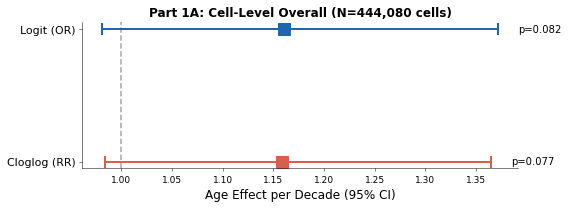

  ✓ Saved: part1a_forest_overall.svg

▸ Figure 2: Part 1B Forest Plot (Logit)


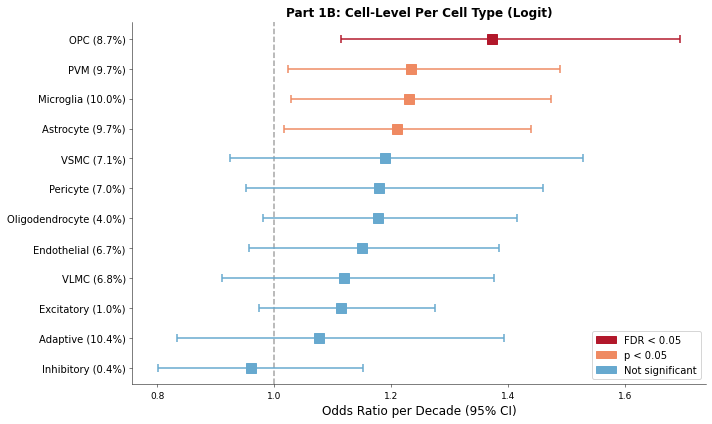

  ✓ Saved: part1b_forest_logit.svg

▸ Figure 3: Part 1B Forest Plot (Cloglog)


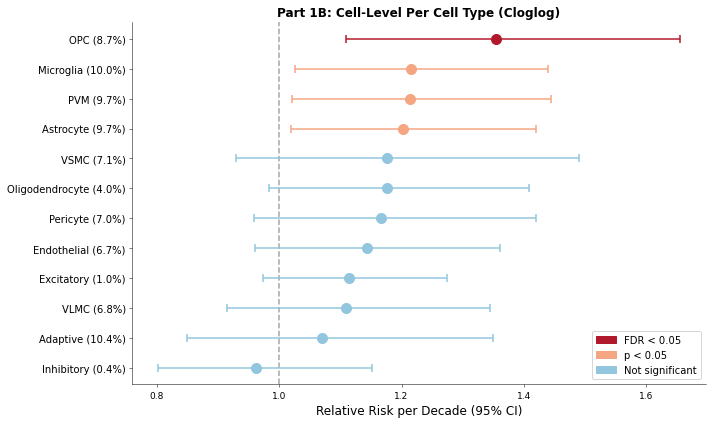

  ✓ Saved: part1b_forest_cloglog.svg

▸ Figure 4: Part 1A Predicted Probability Curve


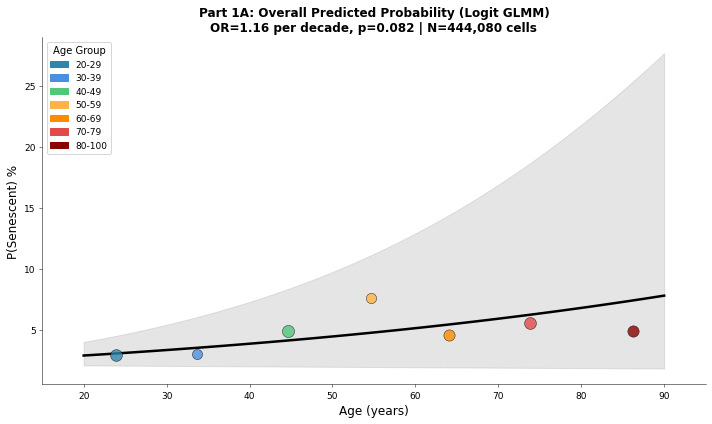

  ✓ Saved: part1a_predicted_prob.svg

▸ Figure 5: Part 1B Predicted Probability Curves (All Cell Types)


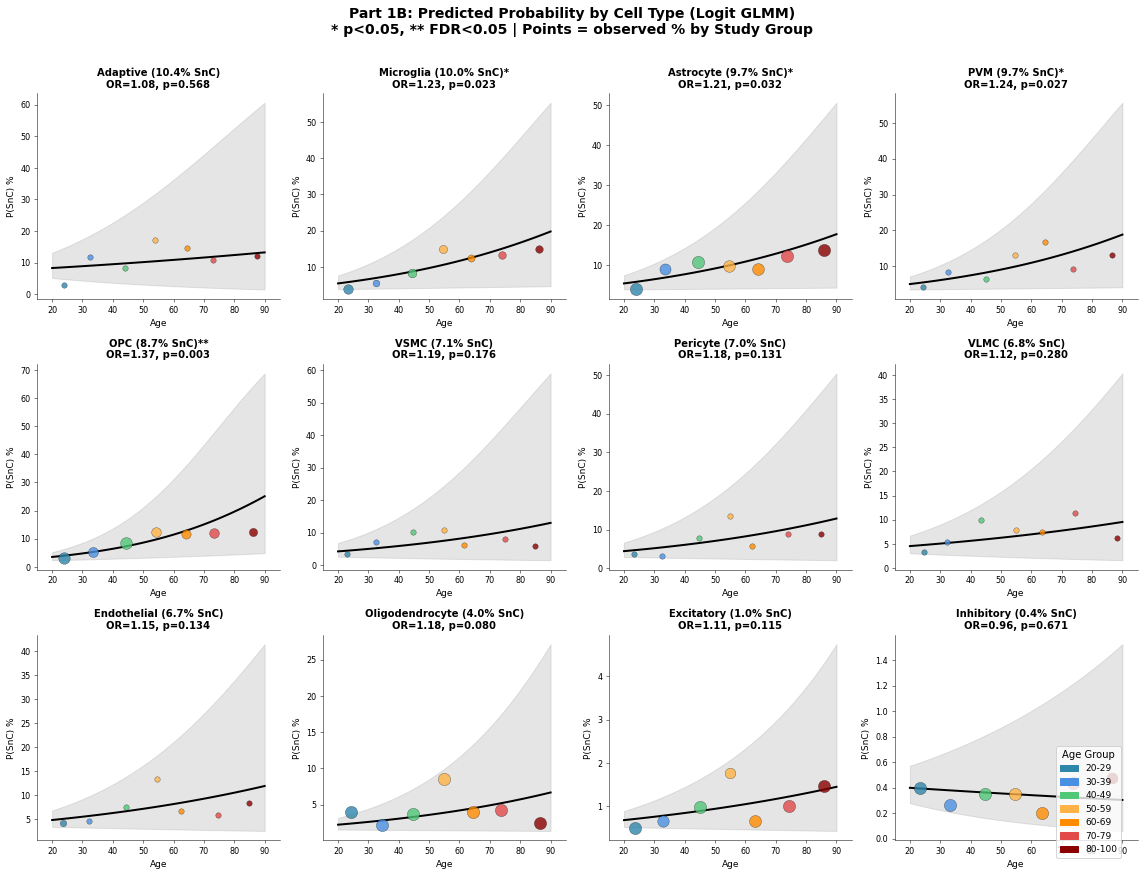

  ✓ Saved: part1b_predicted_prob_all.svg

PART 1 VISUALIZATION COMPLETE

Figures saved to: /fs/scratch/PAS2598/senescence_analysis/figures/02.5_probability_modeling/psychad_aging
  1. part1a_forest_overall.svg - Logit vs Cloglog comparison
  2. part1b_forest_logit.svg - Per cell type (OR)
  3. part1b_forest_cloglog.svg - Per cell type (RR)
  4. part1a_predicted_prob.svg - Overall probability curve
  5. part1b_predicted_prob_all.svg - Per cell type probability curves

✓ Part 1 complete → Cell 7: Part 2A Analysis


In [18]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 6: PART 1 VISUALIZATION
# ════════════════════════════════════════════════════════════════════════════════
#
# Figures:
#   1. Forest plot - Part 1A overall (logit vs cloglog)
#   2. Forest plot - Part 1B per cell type (logit)
#   3. Forest plot - Part 1B per cell type (cloglog)
#   4. Predicted probability curve - Part 1A overall
#   5. Predicted probability curves - All cell types
#
# ════════════════════════════════════════════════════════════════════════════════

print("="*60)
print("PART 1 VISUALIZATION")
print("="*60)

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ─────────────────────────────────────────────────────────────────────────────
# Plot settings
# ─────────────────────────────────────────────────────────────────────────────

plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

# Age range for predictions
age_min = df_cells[COL_AGE].min()
age_max = df_cells[COL_AGE].max()
age_range = np.linspace(age_min, age_max, 100)
age_scaled_range = age_range / AGE_SCALE

# ─────────────────────────────────────────────────────────────────────────────
# Figure 1: Forest Plot - Part 1A Overall (Logit vs Cloglog)
# ─────────────────────────────────────────────────────────────────────────────

print("\n▸ Figure 1: Part 1A Overall Forest Plot")

fig, ax = plt.subplots(figsize=(8, 3))

y_pos = [1, 0]
labels = ['Logit (OR)', 'Cloglog (RR)']
colors_link = ['#2166AC', '#D6604D']

ax.axvline(x=1, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

for i, link in enumerate(['logit', 'cloglog']):
    if results_1a[link] is not None:
        row = results_1a[link]['coefficients'].loc['Age_scaled']
        est = row['exp_beta']
        lo = row['exp_beta_lower']
        hi = row['exp_beta_upper']
        p = row['Pr(>|z|)']
        
        ax.errorbar(est, y_pos[i], xerr=[[est-lo], [hi-est]], 
                    fmt='s', color=colors_link[i], capsize=6, markersize=12, 
                    capthick=2, elinewidth=2)
        
        sig = "*" if p < 0.05 else ""
        ax.annotate(f'p={p:.3f}{sig}', (hi + 0.02, y_pos[i]), fontsize=10, va='center')

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('Age Effect per Decade (95% CI)', fontsize=12)
ax.set_title(f'Part 1A: Cell-Level Overall (N={len(df_cells):,} cells)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'part1a_forest_overall.svg', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved: part1a_forest_overall.svg")

# ─────────────────────────────────────────────────────────────────────────────
# Figure 2: Forest Plot - Part 1B Per Cell Type (Logit)
# ─────────────────────────────────────────────────────────────────────────────

print("\n▸ Figure 2: Part 1B Forest Plot (Logit)")

fig, ax = plt.subplots(figsize=(10, max(6, len(df_results_1b) * 0.5)))

df_plot = df_results_1b.sort_values('logit_Estimate', ascending=True).reset_index(drop=True)
y_pos = np.arange(len(df_plot))

ax.axvline(x=1, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

for i, (_, row) in enumerate(df_plot.iterrows()):
    if np.isnan(row.get('logit_P', np.nan)):
        continue
        
    fdr = row.get('logit_P_adj', 1)
    if fdr < 0.05:
        color = '#B2182B'  # FDR significant
    elif row['logit_P'] < 0.05:
        color = '#EF8A62'  # Nominally significant
    else:
        color = '#67A9CF'  # Not significant
    
    est = row['logit_exp_beta']
    lo = row['logit_exp_beta_lower']
    hi = row['logit_exp_beta_upper']
    
    ax.errorbar(est, i, xerr=[[est-lo], [hi-est]], 
                fmt='s', color=color, capsize=4, markersize=10, 
                capthick=1.5, elinewidth=1.5)

ax.set_yticks(y_pos)
ax.set_yticklabels([f"{row[COL_CELLTYPE]} ({row['pct_snc']:.1f}%)" for _, row in df_plot.iterrows()], fontsize=10)
ax.set_xlabel('Odds Ratio per Decade (95% CI)', fontsize=12)
ax.set_title('Part 1B: Cell-Level Per Cell Type (Logit)', fontsize=12, fontweight='bold')

# Legend
fdr_patch = mpatches.Patch(color='#B2182B', label='FDR < 0.05')
nom_patch = mpatches.Patch(color='#EF8A62', label='p < 0.05')
ns_patch = mpatches.Patch(color='#67A9CF', label='Not significant')
ax.legend(handles=[fdr_patch, nom_patch, ns_patch], loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'part1b_forest_logit.svg', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved: part1b_forest_logit.svg")

# ─────────────────────────────────────────────────────────────────────────────
# Figure 3: Forest Plot - Part 1B Per Cell Type (Cloglog)
# ─────────────────────────────────────────────────────────────────────────────

print("\n▸ Figure 3: Part 1B Forest Plot (Cloglog)")

fig, ax = plt.subplots(figsize=(10, max(6, len(df_results_1b) * 0.5)))

df_plot = df_results_1b.sort_values('cloglog_Estimate', ascending=True).reset_index(drop=True)
y_pos = np.arange(len(df_plot))

ax.axvline(x=1, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

for i, (_, row) in enumerate(df_plot.iterrows()):
    if np.isnan(row.get('cloglog_P', np.nan)):
        continue
        
    fdr = row.get('cloglog_P_adj', 1)
    if fdr < 0.05:
        color = '#B2182B'
    elif row['cloglog_P'] < 0.05:
        color = '#F4A582'
    else:
        color = '#92C5DE'
    
    est = row['cloglog_exp_beta']
    lo = row['cloglog_exp_beta_lower']
    hi = row['cloglog_exp_beta_upper']
    
    ax.errorbar(est, i, xerr=[[est-lo], [hi-est]], 
                fmt='o', color=color, capsize=4, markersize=10, 
                capthick=1.5, elinewidth=1.5)

ax.set_yticks(y_pos)
ax.set_yticklabels([f"{row[COL_CELLTYPE]} ({row['pct_snc']:.1f}%)" for _, row in df_plot.iterrows()], fontsize=10)
ax.set_xlabel('Relative Risk per Decade (95% CI)', fontsize=12)
ax.set_title('Part 1B: Cell-Level Per Cell Type (Cloglog)', fontsize=12, fontweight='bold')

fdr_patch = mpatches.Patch(color='#B2182B', label='FDR < 0.05')
nom_patch = mpatches.Patch(color='#F4A582', label='p < 0.05')
ns_patch = mpatches.Patch(color='#92C5DE', label='Not significant')
ax.legend(handles=[fdr_patch, nom_patch, ns_patch], loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'part1b_forest_cloglog.svg', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved: part1b_forest_cloglog.svg")

# ─────────────────────────────────────────────────────────────────────────────
# Figure 4: Predicted Probability Curve - Part 1A Overall
# ─────────────────────────────────────────────────────────────────────────────

print("\n▸ Figure 4: Part 1A Predicted Probability Curve")

fig, ax = plt.subplots(figsize=(10, 6))

# Get coefficients (logit)
baseline_prop = df_cells[COL_SENESCENT].mean()
beta_age = results_1a['logit']['coefficients'].loc['Age_scaled', 'Estimate']
se_age = results_1a['logit']['coefficients'].loc['Age_scaled', 'Std. Error']
mean_age_scaled = df_cells['Age_scaled'].mean()

# Estimate intercept
intercept = np.log(baseline_prop / (1 - baseline_prop)) - beta_age * mean_age_scaled

# Predicted probability
eta = intercept + beta_age * age_scaled_range
prob = 1 / (1 + np.exp(-eta))

# CI
eta_lo = intercept + (beta_age - 1.96 * se_age) * age_scaled_range
eta_hi = intercept + (beta_age + 1.96 * se_age) * age_scaled_range
prob_lo = 1 / (1 + np.exp(-eta_lo))
prob_hi = 1 / (1 + np.exp(-eta_hi))

# Plot prediction line and CI
ax.fill_between(age_range, prob_lo * 100, prob_hi * 100, alpha=0.2, color='gray')
ax.plot(age_range, prob * 100, color='black', linewidth=2.5, label='Model prediction')

# Plot observed points by Study_Group
for sg in STUDY_GROUPS_ORDERED:
    mask = df_cells[COL_STUDYGROUP] == sg
    if mask.sum() > 0:
        n_cells_grp = mask.sum()
        n_snc_grp = df_cells.loc[mask, COL_SENESCENT].sum()
        pct_snc = n_snc_grp / n_cells_grp * 100
        midpoint_age = df_cells.loc[mask, COL_AGE].mean()
        color = STUDY_GROUP_COLORS.get(sg, 'gray')
        size = min(300, max(80, n_cells_grp / 500))
        ax.scatter(midpoint_age, pct_snc, s=size, color=color, 
                   edgecolors='black', linewidths=0.5, alpha=0.8, zorder=5)

# Get p-value and OR for annotation
p_val = results_1a['logit']['coefficients'].loc['Age_scaled', 'Pr(>|z|)']
or_val = results_1a['logit']['coefficients'].loc['Age_scaled', 'exp_beta']

# Legend for Study Groups
legend_patches = [mpatches.Patch(color=STUDY_GROUP_COLORS.get(sg, 'gray'), 
                                  label=sg.replace('Age_', '').replace('_', '-'))
                  for sg in STUDY_GROUPS_ORDERED]
ax.legend(handles=legend_patches, title='Age Group', loc='upper left', fontsize=9, title_fontsize=10)

ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('P(Senescent) %', fontsize=12)
ax.set_xlim(age_min - 5, age_max + 5)
ax.set_title(f'Part 1A: Overall Predicted Probability (Logit GLMM)\n'
             f'OR={or_val:.2f} per decade, p={p_val:.3f} | N={len(df_cells):,} cells', 
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'part1a_predicted_prob.svg', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved: part1a_predicted_prob.svg")

# ─────────────────────────────────────────────────────────────────────────────
# Figure 5: Predicted Probability Curves - All Cell Types
# ─────────────────────────────────────────────────────────────────────────────

print("\n▸ Figure 5: Part 1B Predicted Probability Curves (All Cell Types)")

# Sort by % SnC descending
ct_order = df_results_1b.sort_values('pct_snc', ascending=False)[COL_CELLTYPE].tolist()
n_cts = len(ct_order)

n_cols = 4
n_rows = int(np.ceil(n_cts / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for idx, ct in enumerate(ct_order):
    ax = axes[idx]
    
    row = df_results_1b[df_results_1b[COL_CELLTYPE] == ct].iloc[0]
    df_ct = df_cells[df_cells[COL_CELLTYPE] == ct]
    baseline_prop_ct = df_ct[COL_SENESCENT].mean()
    
    # Skip if no valid coefficients
    if np.isnan(row.get('logit_Estimate', np.nan)):
        ax.text(0.5, 0.5, 'Model failed', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(ct, fontsize=10, fontweight='bold')
        continue
    
    beta_age_ct = row['logit_Estimate']
    se_age_ct = row['logit_SE']
    
    # Estimate intercept
    mean_age_scaled_ct = df_ct['Age_scaled'].mean()
    if baseline_prop_ct > 0 and baseline_prop_ct < 1:
        intercept_ct = np.log(baseline_prop_ct / (1 - baseline_prop_ct)) - beta_age_ct * mean_age_scaled_ct
        
        # Predicted probability
        eta_ct = intercept_ct + beta_age_ct * age_scaled_range
        prob_ct = 1 / (1 + np.exp(-eta_ct))
        
        # CI
        eta_lo_ct = intercept_ct + (beta_age_ct - 1.96 * se_age_ct) * age_scaled_range
        eta_hi_ct = intercept_ct + (beta_age_ct + 1.96 * se_age_ct) * age_scaled_range
        prob_lo_ct = 1 / (1 + np.exp(-eta_lo_ct))
        prob_hi_ct = 1 / (1 + np.exp(-eta_hi_ct))
        
        ax.fill_between(age_range, prob_lo_ct * 100, prob_hi_ct * 100, alpha=0.2, color='gray')
        ax.plot(age_range, prob_ct * 100, color='black', linewidth=2, label='Model prediction')
    
    # Plot observed points by Study_Group
    for sg in STUDY_GROUPS_ORDERED:
        mask = df_ct[COL_STUDYGROUP] == sg
        if mask.sum() > 0:
            n_cells_grp = mask.sum()
            n_snc_grp = df_ct.loc[mask, COL_SENESCENT].sum()
            pct_snc = n_snc_grp / n_cells_grp * 100
            midpoint_age = df_ct.loc[mask, COL_AGE].mean()
            color = STUDY_GROUP_COLORS.get(sg, 'gray')
            size = min(150, max(30, n_cells_grp / 50))
            ax.scatter(midpoint_age, pct_snc, s=size, color=color, 
                       edgecolors='black', linewidths=0.3, alpha=0.8, zorder=5)
    
    # Significance marker
    fdr = row.get('logit_P_adj', 1)
    sig_marker = "**" if fdr < 0.05 else ("*" if row['logit_P'] < 0.05 else "")
    
    ax.set_title(f"{ct} ({row['pct_snc']:.1f}% SnC){sig_marker}\nOR={row['logit_exp_beta']:.2f}, p={row['logit_P']:.3f}", 
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Age', fontsize=9)
    ax.set_ylabel('P(SnC) %', fontsize=9)
    ax.set_xlim(age_min - 5, age_max + 5)
    ax.tick_params(labelsize=8)

# Hide unused subplots
for idx in range(n_cts, len(axes)):
    axes[idx].axis('off')

# Shared legend
legend_patches = [mpatches.Patch(color=STUDY_GROUP_COLORS.get(sg, 'gray'), 
                                  label=sg.replace('Age_', '').replace('_', '-'))
                  for sg in STUDY_GROUPS_ORDERED]
fig.legend(handles=legend_patches, title='Age Group', loc='lower right', 
           fontsize=9, title_fontsize=10, bbox_to_anchor=(0.98, 0.02))

plt.suptitle('Part 1B: Predicted Probability by Cell Type (Logit GLMM)\n'
             '* p<0.05, ** FDR<0.05 | Points = observed % by Study Group', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'part1b_predicted_prob_all.svg', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved: part1b_predicted_prob_all.svg")

# ─────────────────────────────────────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────────────────────────────────────

print(f"\n{'='*60}")
print("PART 1 VISUALIZATION COMPLETE")
print(f"{'='*60}")

print(f"\nFigures saved to: {FIGURES_DIR}")
print(f"  1. part1a_forest_overall.svg - Logit vs Cloglog comparison")
print(f"  2. part1b_forest_logit.svg - Per cell type (OR)")
print(f"  3. part1b_forest_cloglog.svg - Per cell type (RR)")
print(f"  4. part1a_predicted_prob.svg - Overall probability curve")
print(f"  5. part1b_predicted_prob_all.svg - Per cell type probability curves")

print(f"\n✓ Part 1 complete → Cell 7: Part 2A Analysis")

In [19]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 7: PART 2A - DONOR-LEVEL OVERALL (ZERO-INFLATED BETA REGRESSION)
# ════════════════════════════════════════════════════════════════════════════════
#
# Compares 8 model configurations:
#   - v1 (Epsilon) vs v2 (Smithson-Verkuilen) transformation
#   - Age only vs Age + Sex + Cohort formula
#   - Logit vs Cloglog link function
#
# Transformation methods:
#   - v1: prop_adj = clip(prop, EPSILON, 1-EPSILON)
#   - v2: prop_adj = (prop * (n-1) + 0.5) / n  [Smithson & Verkuilen 2006]
#
# Link functions:
#   - Logit: exp(β) = odds ratio per decade
#   - Cloglog: exp(β) ≈ relative risk per decade (for rare outcomes)
#
# Output: df_results_2a (1 row, standardized columns matching df_results_2b)
#
# ════════════════════════════════════════════════════════════════════════════════

print("="*80)
print("PART 2A: DONOR-LEVEL OVERALL (ZERO-INFLATED BETA)")
print("="*80)

# ─────────────────────────────────────────────────────────────────────────────────
# Configuration
# ─────────────────────────────────────────────────────────────────────────────────

COVARIATES_2A = [COL_SEX, COL_COHORT]
covariate_str = ' + '.join(COVARIATES_2A)
FORMULA_AGE_ONLY = "prop_adj ~ Age_scaled"
FORMULA_FULL = f"prop_adj ~ Age_scaled + {covariate_str}"
EPSILON = 1e-6

# All model configurations
MODEL_CONFIGS = [
    ('v1', 'age', 'logit'),
    ('v1', 'age', 'cloglog'),
    ('v1', 'full', 'logit'),
    ('v1', 'full', 'cloglog'),
    ('v2', 'age', 'logit'),
    ('v2', 'age', 'cloglog'),
    ('v2', 'full', 'logit'),
    ('v2', 'full', 'cloglog'),
]

print(f"\nModel configurations:")
print(f"  Age-only formula: {FORMULA_AGE_ONLY}")
print(f"  Full formula:     {FORMULA_FULL}")
print(f"  Covariates:       {COVARIATES_2A}")
print(f"  Epsilon (v1):     {EPSILON}")
print(f"  Transformations:  v1 (Epsilon), v2 (Smithson-Verkuilen)")
print(f"  Link functions:   logit, cloglog")
print(f"  Total configs:    {len(MODEL_CONFIGS)}")

missing_cols = [c for c in COVARIATES_2A if c not in df_donor.columns]
if missing_cols:
    raise ValueError(f"Missing columns in df_donor: {missing_cols}")
print(f"\n✓ All covariates present in df_donor")

# ─────────────────────────────────────────────────────────────────────────────────
# Prepare data with both transformations
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("PREPARING DATA")
print(f"{'─'*80}")

df_model = df_donor[[COL_DONOR, 'prop_snc', 'n_cells', 'Age_scaled', COL_SEX, COL_COHORT]].copy()

df_model['prop_adj_v1'] = df_model['prop_snc'].clip(EPSILON, 1 - EPSILON)
df_model['prop_adj_v2'] = (df_model['prop_snc'] * (df_model['n_cells'] - 1) + 0.5) / df_model['n_cells']

print(f"  v1 (Epsilon): prop_adj = clip(prop, {EPSILON}, {1-EPSILON})")
print(f"  v2 (Smithson-Verkuilen): prop_adj = (prop × (n-1) + 0.5) / n")

# Basic stats
n_donors = len(df_model)
n_zeros = (df_model['prop_snc'] == 0).sum()
pct_zeros = n_zeros / n_donors * 100
mean_prop = df_model['prop_snc'].mean() * 100

print(f"\n  {'Statistic':<25} {'Value':<20}")
print(f"  {'-'*45}")
print(f"  {'N donors':<25} {n_donors}")
print(f"  {'N zeros (0% SnC)':<25} {n_zeros} ({pct_zeros:.1f}%)")
print(f"  {'Mean proportion':<25} {mean_prop:.2f}%")
print(f"  {'Prop range':<25} {df_model['prop_snc'].min()*100:.2f}% - {df_model['prop_snc'].max()*100:.2f}%")

# ─────────────────────────────────────────────────────────────────────────────────
# Fit all models and collect raw R output
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("FITTING MODELS")
print(f"{'─'*80}")

# Store results
results_dict = {
    COL_CELLTYPE: 'Overall',
    'n_obs': n_donors,
    'n_donors': n_donors,
    'pct_zeros': pct_zeros,
    'mean_prop': mean_prop
}

raw_summaries = {}

for version, formula_name, link in MODEL_CONFIGS:
    adj_col = f'prop_adj_{version}'
    formula = FORMULA_AGE_ONLY if formula_name == 'age' else FORMULA_FULL
    key = f'{version}_{formula_name}_{link}'
    
    df_model['prop_adj'] = df_model[adj_col]
    
    print(f"\n  Fitting {key}...")
    print(f"    Formula: {formula}")
    print(f"    Transformation: {version}, Link: {link}")
    
    # Transfer data to R
    with localconverter(ro.default_converter + pandas2ri.converter):
        ro.globalenv['df_fit'] = ro.conversion.py2rpy(df_model)
    
    # Fit model in R
    r_code = f'''
    library(glmmTMB)
    
    model <- tryCatch({{
        m <- glmmTMB(
            {formula},
            ziformula = ~ 1,
            family = beta_family(link = "{link}"),
            data = df_fit
        )
        s <- summary(m)
        if (any(is.na(s$coefficients$cond[,"Std. Error"]))) NULL else m
    }}, error = function(e) NULL)
    
    model_type <- "zib"
    
    if (is.null(model)) {{
        model <- tryCatch({{
            m <- glmmTMB(
                {formula},
                family = beta_family(link = "{link}"),
                data = df_fit
            )
            s <- summary(m)
            if (any(is.na(s$coefficients$cond[,"Std. Error"]))) NULL else m
        }}, error = function(e) NULL)
        model_type <- "beta"
    }}
    
    if (is.null(model)) {{
        list(success = FALSE)
    }} else {{
        s <- summary(model)
        cond_coef <- as.data.frame(s$coefficients$cond)
        cond_coef$term <- rownames(cond_coef)
        cond_coef$exp_beta <- exp(cond_coef$Estimate)
        cond_coef$exp_beta_lower <- exp(cond_coef$Estimate - 1.96 * cond_coef$`Std. Error`)
        cond_coef$exp_beta_upper <- exp(cond_coef$Estimate + 1.96 * cond_coef$`Std. Error`)
        
        raw_summary <- capture.output(summary(model))
        
        list(
            success = TRUE,
            model_type = model_type,
            cond_coef = cond_coef,
            aic = AIC(model),
            bic = BIC(model),
            loglik = as.numeric(logLik(model)),
            raw_summary = raw_summary
        )
    }}
    '''
    
    try:
        result = ro.r(r_code)
        
        if result.rx2('success')[0]:
            with localconverter(ro.default_converter + pandas2ri.converter):
                coef_df = ro.conversion.rpy2py(result.rx2('cond_coef'))
            coef_df = coef_df.set_index('term')
            
            age_row = coef_df.loc['Age_scaled']
            
            results_dict[f'{key}_beta'] = age_row['Estimate']
            results_dict[f'{key}_SE'] = age_row['Std. Error']
            results_dict[f'{key}_exp_beta'] = age_row['exp_beta']
            results_dict[f'{key}_exp_beta_lower'] = age_row['exp_beta_lower']
            results_dict[f'{key}_exp_beta_upper'] = age_row['exp_beta_upper']
            results_dict[f'{key}_P'] = age_row['Pr(>|z|)']
            results_dict[f'{key}_aic'] = result.rx2('aic')[0]
            results_dict[f'{key}_bic'] = result.rx2('bic')[0]
            results_dict[f'{key}_loglik'] = result.rx2('loglik')[0]
            results_dict[f'{key}_model_type'] = result.rx2('model_type')[0]
            
            raw_summaries[key] = '\n'.join(list(result.rx2('raw_summary')))
            
            sig = "***" if age_row['Pr(>|z|)'] < 0.001 else "**" if age_row['Pr(>|z|)'] < 0.01 else "*" if age_row['Pr(>|z|)'] < 0.05 else ""
            print(f"    ✓ Converged ({result.rx2('model_type')[0]})")
            print(f"    exp(β) = {age_row['exp_beta']:.4f}, p = {age_row['Pr(>|z|)']:.2e} {sig}")
        else:
            results_dict[f'{key}_P'] = np.nan
            results_dict[f'{key}_model_type'] = 'failed'
            raw_summaries[key] = 'Model failed to converge'
            print(f"    ✗ Failed to converge")
            
    except Exception as e:
        results_dict[f'{key}_P'] = np.nan
        results_dict[f'{key}_model_type'] = 'failed'
        raw_summaries[key] = f'Error: {str(e)}'
        print(f"    ✗ Error: {str(e)}")

df_results_2a = pd.DataFrame([results_dict])

# ─────────────────────────────────────────────────────────────────────────────────
# RAW R MODEL SUMMARIES
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("RAW R MODEL SUMMARIES")
print(f"{'─'*80}")

for version, formula_name, link in MODEL_CONFIGS:
    key = f'{version}_{formula_name}_{link}'
    print(f"\n{'='*80}")
    print(f"MODEL: Overall | {key}")
    print(f"{'='*80}")
    print(raw_summaries.get(key, 'Not available'))

# ─────────────────────────────────────────────────────────────────────────────────
# Summary comparison table
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("SUMMARY: AGE EFFECT COMPARISON")
print(f"{'─'*80}")

print(f"\n  {'Model':<25} {'Transform':<10} {'Formula':<6} {'Link':<8} {'exp(β)':<10} {'95% CI':<24} {'P':<12} {'Sig':<4}")
print(f"  {'-'*105}")

for version, formula_name, link in MODEL_CONFIGS:
    key = f'{version}_{formula_name}_{link}'
    
    if pd.notna(results_dict.get(f'{key}_P')):
        exp_b = results_dict[f'{key}_exp_beta']
        ci_lo = results_dict[f'{key}_exp_beta_lower']
        ci_hi = results_dict[f'{key}_exp_beta_upper']
        p_val = results_dict[f'{key}_P']
        
        ci_str = f"({ci_lo:.4f} - {ci_hi:.4f})"
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
        
        transform = "Epsilon" if version == "v1" else "Smithson"
        formula_label = "Age" if formula_name == "age" else "Full"
        
        print(f"  {key:<25} {transform:<10} {formula_label:<6} {link:<8} {exp_b:<10.4f} {ci_str:<24} {p_val:<12.2e} {sig:<4}")

# ─────────────────────────────────────────────────────────────────────────────────
# Side-by-side comparison tables
# ─────────────────────────────────────────────────────────────────────────────────

for version in ['v1', 'v2']:
    for link in ['logit', 'cloglog']:
        version_label = 'EPSILON CLIPPING' if version == 'v1' else 'SMITHSON-VERKUILEN'
        link_label = 'LOGIT (Odds Ratio)' if link == 'logit' else 'CLOGLOG (Relative Risk)'
        title = f"{version} ({version_label}) + {link_label}: Age-only vs Full Model"
        
        print(f"\n{'='*100}")
        print(f"{title}")
        print(f"{'='*100}")
        
        key_age = f'{version}_age_{link}'
        key_full = f'{version}_full_{link}'
        
        print(f"\n  {'':^20}   {'──────────── Age Only ────────────':^40}   {'────────── Age+Sex+Cohort ──────────':^40}")
        print(f"  {'Analysis':<20}   {'β':>8} {'exp(β)':>8} {'95% CI':<20} {'p':>12}   {'β':>8} {'exp(β)':>8} {'95% CI':<20} {'p':>12}")
        print(f"  {'-'*100}")
        
        # Age-only
        if pd.notna(results_dict.get(f'{key_age}_P')):
            b1 = results_dict[f'{key_age}_beta']
            e1 = results_dict[f'{key_age}_exp_beta']
            ci1 = f"({results_dict[f'{key_age}_exp_beta_lower']:.3f}-{results_dict[f'{key_age}_exp_beta_upper']:.3f})"
            p1 = results_dict[f'{key_age}_P']
            sig1 = "***" if p1 < 0.001 else "**" if p1 < 0.01 else "*" if p1 < 0.05 else ""
        else:
            b1, e1, ci1, p1, sig1 = np.nan, np.nan, "--", np.nan, ""
        
        # Full model
        if pd.notna(results_dict.get(f'{key_full}_P')):
            b2 = results_dict[f'{key_full}_beta']
            e2 = results_dict[f'{key_full}_exp_beta']
            ci2 = f"({results_dict[f'{key_full}_exp_beta_lower']:.3f}-{results_dict[f'{key_full}_exp_beta_upper']:.3f})"
            p2 = results_dict[f'{key_full}_P']
            sig2 = "***" if p2 < 0.001 else "**" if p2 < 0.01 else "*" if p2 < 0.05 else ""
        else:
            b2, e2, ci2, p2, sig2 = np.nan, np.nan, "--", np.nan, ""
        
        if pd.notna(b1) and pd.notna(b2):
            print(f"  {'Overall':<20}   {b1:>8.4f} {e1:>8.3f} {ci1:<20} {p1:>10.2e}{sig1:<2}   {b2:>8.4f} {e2:>8.3f} {ci2:<20} {p2:>10.2e}{sig2:<2}")

# ─────────────────────────────────────────────────────────────────────────────────
# Detailed results for recommended model (v2_full_logit)
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("RECOMMENDED MODEL: v2_full_logit (Smithson-Verkuilen + Age + Sex + Cohort + Logit)")
print(f"{'─'*80}")

if pd.notna(results_dict.get('v2_full_logit_P')):
    beta = results_dict['v2_full_logit_beta']
    exp_beta = results_dict['v2_full_logit_exp_beta']
    ci_lo = results_dict['v2_full_logit_exp_beta_lower']
    ci_hi = results_dict['v2_full_logit_exp_beta_upper']
    p_val = results_dict['v2_full_logit_P']
    aic = results_dict['v2_full_logit_aic']
    bic = results_dict['v2_full_logit_bic']
    
    print(f"\n  Model fit:")
    print(f"    AIC = {aic:.2f}")
    print(f"    BIC = {bic:.2f}")
    
    print(f"\n  Age effect (per decade):")
    print(f"    β = {beta:.4f}")
    print(f"    SE = {results_dict['v2_full_logit_SE']:.4f}")
    print(f"    exp(β) = {exp_beta:.4f}")
    print(f"    95% CI: ({ci_lo:.4f} - {ci_hi:.4f})")
    print(f"    P = {p_val:.2e}")
    
    direction = "increases" if beta > 0 else "decreases"
    pct_change = abs(exp_beta - 1) * 100
    
    print(f"\n  Interpretation:")
    print(f"    Odds of senescence {direction} by {pct_change:.1f}% per decade of age")
    
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "not significant"
    print(f"    Statistical significance: {sig}")
else:
    print("\n  Model did not converge")

# ─────────────────────────────────────────────────────────────────────────────────
# Sensitivity analysis: Logit vs Cloglog
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("SENSITIVITY ANALYSIS: LOGIT vs CLOGLOG (v2_full)")
print(f"{'─'*80}")

if pd.notna(results_dict.get('v2_full_logit_P')) and pd.notna(results_dict.get('v2_full_cloglog_P')):
    print(f"\n  {'Link':<10} {'exp(β)':<10} {'95% CI':<24} {'P':<12} {'Interpretation'}")
    print(f"  {'-'*80}")
    
    # Logit
    exp_b_logit = results_dict['v2_full_logit_exp_beta']
    ci_logit = f"({results_dict['v2_full_logit_exp_beta_lower']:.4f} - {results_dict['v2_full_logit_exp_beta_upper']:.4f})"
    p_logit = results_dict['v2_full_logit_P']
    pct_logit = abs(exp_b_logit - 1) * 100
    print(f"  {'Logit':<10} {exp_b_logit:<10.4f} {ci_logit:<24} {p_logit:<12.2e} OR: {pct_logit:.1f}% change in odds")
    
    # Cloglog
    exp_b_cloglog = results_dict['v2_full_cloglog_exp_beta']
    ci_cloglog = f"({results_dict['v2_full_cloglog_exp_beta_lower']:.4f} - {results_dict['v2_full_cloglog_exp_beta_upper']:.4f})"
    p_cloglog = results_dict['v2_full_cloglog_P']
    pct_cloglog = abs(exp_b_cloglog - 1) * 100
    print(f"  {'Cloglog':<10} {exp_b_cloglog:<10.4f} {ci_cloglog:<24} {p_cloglog:<12.2e} RR: {pct_cloglog:.1f}% change in risk")

# ─────────────────────────────────────────────────────────────────────────────────
# Export results
# ─────────────────────────────────────────────────────────────────────────────────

df_results_2a.to_csv(RESULTS_DIR / f'{DATASET}_part2a_zib_results.csv', index=False)
print(f"\n✓ Results exported to {RESULTS_DIR / f'{DATASET}_part2a_zib_results.csv'}")

# ─────────────────────────────────────────────────────────────────────────────────
# Output summary
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("OUTPUT")
print(f"{'─'*80}")

print(f"\n  df_results_2a: {df_results_2a.shape[0]} row × {df_results_2a.shape[1]} columns")
print(f"\n  Column structure (matches df_results_2b):")
print(f"    Metadata: {COL_CELLTYPE}, n_obs, n_donors, pct_zeros, mean_prop")
print(f"    Per model: {{version}}_{{formula}}_{{link}}_{{stat}}")
print(f"      Versions: v1, v2")
print(f"      Formulas: age, full")
print(f"      Links: logit, cloglog")
print(f"      Stats: beta, SE, exp_beta, exp_beta_lower, exp_beta_upper, P, aic, bic, loglik, model_type")

print(f"\n✓ Part 2A complete → Cell 8: Part 2B Analysis")

PART 2A: DONOR-LEVEL OVERALL (ZERO-INFLATED BETA)

Model configurations:
  Age-only formula: prop_adj ~ Age_scaled
  Full formula:     prop_adj ~ Age_scaled + Sex + Cohort
  Covariates:       ['Sex', 'Cohort']
  Epsilon (v1):     1e-06
  Transformations:  v1 (Epsilon), v2 (Smithson-Verkuilen)
  Link functions:   logit, cloglog
  Total configs:    8

✓ All covariates present in df_donor

────────────────────────────────────────────────────────────────────────────────
PREPARING DATA
────────────────────────────────────────────────────────────────────────────────
  v1 (Epsilon): prop_adj = clip(prop, 1e-06, 0.999999)
  v2 (Smithson-Verkuilen): prop_adj = (prop × (n-1) + 0.5) / n

  Statistic                 Value               
  ---------------------------------------------
  N donors                  124
  N zeros (0% SnC)          0 (0.0%)
  Mean proportion           6.16%
  Prop range                0.02% - 48.15%

──────────────────────────────────────────────────────────────────────

In [20]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 8: PART 2B - DONOR-LEVEL PER CELL TYPE (ZERO-INFLATED BETA REGRESSION)
# ════════════════════════════════════════════════════════════════════════════════
#
# Compares 8 model configurations:
#   - v1 (Epsilon) vs v2 (Smithson-Verkuilen) transformation
#   - Age only vs Age + Sex + Cohort formula
#   - Logit vs Cloglog link function
#
# Transformation methods:
#   - v1: prop_adj = clip(prop, EPSILON, 1-EPSILON)
#   - v2: prop_adj = (prop * (n-1) + 0.5) / n  [Smithson & Verkuilen 2006]
#
# Link functions:
#   - Logit: exp(β) = odds ratio per decade
#   - Cloglog: exp(β) ≈ relative risk per decade (for rare outcomes)
#
# Output: df_results_2b (N rows, standardized columns matching df_results_2a)
#
# ════════════════════════════════════════════════════════════════════════════════

print("="*80)
print("PART 2B: DONOR-LEVEL PER CELL TYPE (ZERO-INFLATED BETA)")
print("="*80)

# ─────────────────────────────────────────────────────────────────────────────────
# Configuration
# ─────────────────────────────────────────────────────────────────────────────────

COVARIATES_2B = [COL_SEX, COL_COHORT]
covariate_str = ' + '.join(COVARIATES_2B)
FORMULA_AGE_ONLY = "prop_adj ~ Age_scaled"
FORMULA_FULL = f"prop_adj ~ Age_scaled + {covariate_str}"
EPSILON = 1e-6

# All model configurations
MODEL_CONFIGS = [
    ('v1', 'age', 'logit'),
    ('v1', 'age', 'cloglog'),
    ('v1', 'full', 'logit'),
    ('v1', 'full', 'cloglog'),
    ('v2', 'age', 'logit'),
    ('v2', 'age', 'cloglog'),
    ('v2', 'full', 'logit'),
    ('v2', 'full', 'cloglog'),
]

print(f"\nModel configurations:")
print(f"  Age-only formula: {FORMULA_AGE_ONLY}")
print(f"  Full formula:     {FORMULA_FULL}")
print(f"  Covariates:       {COVARIATES_2B}")
print(f"  Epsilon (v1):     {EPSILON}")
print(f"  Transformations:  v1 (Epsilon), v2 (Smithson-Verkuilen)")
print(f"  Link functions:   logit, cloglog")
print(f"  Total configs:    {len(MODEL_CONFIGS)} per cell type")

missing_cols = [c for c in COVARIATES_2B if c not in df_donor_ct.columns]
if missing_cols:
    raise ValueError(f"Missing columns in df_donor_ct: {missing_cols}")
print(f"\n✓ All covariates present in df_donor_ct")

# ─────────────────────────────────────────────────────────────────────────────────
# Prepare data with both transformations
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("PREPARING DATA")
print(f"{'─'*80}")

df_donor_ct['prop_adj_v1'] = df_donor_ct['prop_snc'].clip(EPSILON, 1 - EPSILON)
df_donor_ct['prop_adj_v2'] = (df_donor_ct['prop_snc'] * (df_donor_ct['n_cells'] - 1) + 0.5) / df_donor_ct['n_cells']

print(f"  v1 (Epsilon): prop_adj = clip(prop, {EPSILON}, {1-EPSILON})")
print(f"  v2 (Smithson-Verkuilen): prop_adj = (prop × (n-1) + 0.5) / n")

# Cell type statistics
ct_stats = df_donor_ct.groupby(COL_CELLTYPE).agg({
    'prop_snc': ['count', 'mean', lambda x: (x == 0).sum()],
    COL_DONOR: 'nunique'
}).reset_index()
ct_stats.columns = [COL_CELLTYPE, 'n_obs', 'mean_prop', 'n_zeros', 'n_donors']
ct_stats['pct_zeros'] = ct_stats['n_zeros'] / ct_stats['n_obs'] * 100
ct_stats['mean_prop'] = ct_stats['mean_prop'] * 100

print(f"\n  {'Cell Type':<20} {'N obs':>8} {'N donors':>10} {'%Zeros':>8} {'Mean %':>8}")
print(f"  {'-'*60}")
for _, row in ct_stats.sort_values('pct_zeros', ascending=False).iterrows():
    print(f"  {row[COL_CELLTYPE]:<20} {row['n_obs']:>8} {row['n_donors']:>10} {row['pct_zeros']:>8.1f} {row['mean_prop']:>8.2f}")

cell_types = ct_stats[COL_CELLTYPE].tolist()
print(f"\n  Analyzing {len(cell_types)} cell types across {len(MODEL_CONFIGS)} model configurations...")

# ─────────────────────────────────────────────────────────────────────────────────
# Fit all models and collect raw R output
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("FITTING MODELS")
print(f"{'─'*80}")

results_all = []
raw_summaries_all = {}

for ct in cell_types:
    df_ct = df_donor_ct[df_donor_ct[COL_CELLTYPE] == ct].copy()
    ct_info = ct_stats[ct_stats[COL_CELLTYPE] == ct].iloc[0]
    
    print(f"\n  {ct}: n={ct_info['n_obs']:.0f}, {ct_info['pct_zeros']:.1f}% zeros", end=" → ")
    
    ct_results = {
        COL_CELLTYPE: ct,
        'n_obs': ct_info['n_obs'],
        'n_donors': ct_info['n_donors'],
        'pct_zeros': ct_info['pct_zeros'],
        'mean_prop': ct_info['mean_prop']
    }
    
    models_fitted = []
    raw_summaries_all[ct] = {}
    
    for version, formula_name, link in MODEL_CONFIGS:
        adj_col = f'prop_adj_{version}'
        formula = FORMULA_AGE_ONLY if formula_name == 'age' else FORMULA_FULL
        key = f'{version}_{formula_name}_{link}'
        
        df_ct['prop_adj'] = df_ct[adj_col]
        
        # Transfer data to R
        with localconverter(ro.default_converter + pandas2ri.converter):
            ro.globalenv['df_fit'] = ro.conversion.py2rpy(df_ct)
        
        # Fit model in R
        r_code = f'''
        library(glmmTMB)
        
        model <- tryCatch({{
            m <- glmmTMB(
                {formula},
                ziformula = ~ 1,
                family = beta_family(link = "{link}"),
                data = df_fit
            )
            s <- summary(m)
            if (any(is.na(s$coefficients$cond[,"Std. Error"]))) NULL else m
        }}, error = function(e) NULL)
        
        model_type <- "zib"
        
        if (is.null(model)) {{
            model <- tryCatch({{
                m <- glmmTMB(
                    {formula},
                    family = beta_family(link = "{link}"),
                    data = df_fit
                )
                s <- summary(m)
                if (any(is.na(s$coefficients$cond[,"Std. Error"]))) NULL else m
            }}, error = function(e) NULL)
            model_type <- "beta"
        }}
        
        if (is.null(model)) {{
            list(success = FALSE)
        }} else {{
            s <- summary(model)
            cond_coef <- as.data.frame(s$coefficients$cond)
            cond_coef$term <- rownames(cond_coef)
            cond_coef$exp_beta <- exp(cond_coef$Estimate)
            cond_coef$exp_beta_lower <- exp(cond_coef$Estimate - 1.96 * cond_coef$`Std. Error`)
            cond_coef$exp_beta_upper <- exp(cond_coef$Estimate + 1.96 * cond_coef$`Std. Error`)
            
            raw_summary <- capture.output(summary(model))
            
            list(
                success = TRUE,
                model_type = model_type,
                cond_coef = cond_coef,
                aic = AIC(model),
                bic = BIC(model),
                loglik = as.numeric(logLik(model)),
                raw_summary = raw_summary
            )
        }}
        '''
        
        try:
            result = ro.r(r_code)
            
            if result.rx2('success')[0]:
                with localconverter(ro.default_converter + pandas2ri.converter):
                    coef_df = ro.conversion.rpy2py(result.rx2('cond_coef'))
                coef_df = coef_df.set_index('term')
                
                age_row = coef_df.loc['Age_scaled']
                
                ct_results[f'{key}_beta'] = age_row['Estimate']
                ct_results[f'{key}_SE'] = age_row['Std. Error']
                ct_results[f'{key}_exp_beta'] = age_row['exp_beta']
                ct_results[f'{key}_exp_beta_lower'] = age_row['exp_beta_lower']
                ct_results[f'{key}_exp_beta_upper'] = age_row['exp_beta_upper']
                ct_results[f'{key}_P'] = age_row['Pr(>|z|)']
                ct_results[f'{key}_aic'] = result.rx2('aic')[0]
                ct_results[f'{key}_bic'] = result.rx2('bic')[0]
                ct_results[f'{key}_loglik'] = result.rx2('loglik')[0]
                ct_results[f'{key}_model_type'] = result.rx2('model_type')[0]
                
                raw_summaries_all[ct][key] = '\n'.join(list(result.rx2('raw_summary')))
                models_fitted.append(key)
            else:
                ct_results[f'{key}_P'] = np.nan
                ct_results[f'{key}_model_type'] = 'failed'
                raw_summaries_all[ct][key] = 'Model failed to converge'
                
        except Exception as e:
            ct_results[f'{key}_P'] = np.nan
            ct_results[f'{key}_model_type'] = 'failed'
            raw_summaries_all[ct][key] = f'Error: {str(e)}'
    
    print(f"{len(models_fitted)}/{len(MODEL_CONFIGS)} models converged")
    results_all.append(ct_results)

df_results_2b = pd.DataFrame(results_all)

# ─────────────────────────────────────────────────────────────────────────────────
# RAW R MODEL SUMMARIES - ALL CELL TYPES
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("RAW R MODEL SUMMARIES - ALL CELL TYPES")
print(f"{'─'*80}")

for ct in cell_types:
    print(f"\n{'#'*80}")
    print(f"# CELL TYPE: {ct}")
    print(f"{'#'*80}")
    
    for version, formula_name, link in MODEL_CONFIGS:
        key = f'{version}_{formula_name}_{link}'
        print(f"\n{'='*80}")
        print(f"MODEL: {ct} | {key}")
        print(f"{'='*80}")
        print(raw_summaries_all[ct].get(key, 'Not available'))

# ─────────────────────────────────────────────────────────────────────────────────
# FDR correction
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("FDR CORRECTION")
print(f"{'─'*80}")

for version, formula_name, link in MODEL_CONFIGS:
    key = f'{version}_{formula_name}_{link}'
    p_col = f'{key}_P'
    if p_col in df_results_2b.columns:
        valid = ~df_results_2b[p_col].isna()
        if valid.sum() > 0:
            df_results_2b.loc[valid, f'{key}_FDR'] = stats.false_discovery_control(
                df_results_2b.loc[valid, p_col], method='bh'
            )
            n_sig = (df_results_2b[f'{key}_FDR'] < 0.05).sum()
            print(f"  {key}: {n_sig} significant (FDR < 0.05)")

# ─────────────────────────────────────────────────────────────────────────────────
# Comparison tables - by transformation and link
# ─────────────────────────────────────────────────────────────────────────────────

for version in ['v1', 'v2']:
    for link in ['logit', 'cloglog']:
        version_label = 'EPSILON CLIPPING' if version == 'v1' else 'SMITHSON-VERKUILEN'
        link_label = 'LOGIT (Odds Ratio)' if link == 'logit' else 'CLOGLOG (Relative Risk)'
        title = f"{version} ({version_label}) + {link_label}: Age-only vs Full Model"
        
        print(f"\n{'='*140}")
        print(f"{title}")
        print(f"{'='*140}")
        
        key_age = f'{version}_age_{link}'
        key_full = f'{version}_full_{link}'
        
        print(f"\n  {'Cell Type':<16} {'%Zero':>5}   {'──────────────────── Age Only ────────────────────':^50}   {'────────────────── Age+Sex+Cohort ──────────────────':^50}")
        print(f"  {'':<22}   {'β':>8} {'exp(β)':>8} {'95% CI':<18} {'p':>10} {'FDR':>10}   {'β':>8} {'exp(β)':>8} {'95% CI':<18} {'p':>10} {'FDR':>10}")
        print(f"  {'-'*140}")
        
        for _, row in df_results_2b.sort_values(f'{key_age}_P').iterrows():
            ct = row[COL_CELLTYPE]
            pct_zero = row['pct_zeros']
            
            # Age-only
            if pd.notna(row.get(f'{key_age}_P')):
                b1 = row[f'{key_age}_beta']
                e1 = row[f'{key_age}_exp_beta']
                ci1 = f"({row[f'{key_age}_exp_beta_lower']:.3f}-{row[f'{key_age}_exp_beta_upper']:.3f})"
                p1 = row[f'{key_age}_P']
                fdr1 = row.get(f'{key_age}_FDR', np.nan)
                sig1 = "**" if pd.notna(fdr1) and fdr1 < 0.05 else "*" if p1 < 0.05 else ""
            else:
                b1, e1, ci1, p1, fdr1, sig1 = np.nan, np.nan, "--", np.nan, np.nan, ""
            
            # Full model
            if pd.notna(row.get(f'{key_full}_P')):
                b2 = row[f'{key_full}_beta']
                e2 = row[f'{key_full}_exp_beta']
                ci2 = f"({row[f'{key_full}_exp_beta_lower']:.3f}-{row[f'{key_full}_exp_beta_upper']:.3f})"
                p2 = row[f'{key_full}_P']
                fdr2 = row.get(f'{key_full}_FDR', np.nan)
                sig2 = "**" if pd.notna(fdr2) and fdr2 < 0.05 else "*" if p2 < 0.05 else ""
            else:
                b2, e2, ci2, p2, fdr2, sig2 = np.nan, np.nan, "--", np.nan, np.nan, ""
            
            if pd.notna(b1) and pd.notna(b2):
                print(f"  {ct:<16} {pct_zero:>5.1f}   {b1:>8.4f} {e1:>8.3f} {ci1:<18} {p1:>10.2e} {fdr1:>9.2e}{sig1:<2}  {b2:>8.4f} {e2:>8.3f} {ci2:<18} {p2:>10.2e} {fdr2:>9.2e}{sig2:<2}")

# ─────────────────────────────────────────────────────────────────────────────────
# Summary across all 8 models
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n\n{'='*80}")
print("SUMMARY: ALL 8 MODELS")
print(f"{'='*80}")

print(f"\n  Significant cell types (FDR < 0.05):\n")
print(f"  {'Model':<40} {'N sig':<6} {'Cell Types'}")
print(f"  {'-'*90}")

for version, formula_name, link in MODEL_CONFIGS:
    key = f'{version}_{formula_name}_{link}'
    fdr_col = f'{key}_FDR'
    
    version_label = 'Epsilon' if version == 'v1' else 'Smithson'
    formula_label = 'Age' if formula_name == 'age' else 'Full'
    label = f"{version_label} + {formula_label} + {link}"
    
    if fdr_col in df_results_2b.columns:
        sig_cts = df_results_2b[df_results_2b[fdr_col] < 0.05][COL_CELLTYPE].tolist()
        ct_str = ', '.join(sorted(sig_cts)) if sig_cts else 'None'
        print(f"  {label:<40} {len(sig_cts):<6} {ct_str}")

# ─────────────────────────────────────────────────────────────────────────────────
# Export results
# ─────────────────────────────────────────────────────────────────────────────────

df_results_2b.to_csv(RESULTS_DIR / f'{DATASET}_part2b_zib_results.csv', index=False)
print(f"\n✓ Results exported to {RESULTS_DIR / f'{DATASET}_part2b_zib_results.csv'}")

# ─────────────────────────────────────────────────────────────────────────────────
# Output summary
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("OUTPUT")
print(f"{'─'*80}")

print(f"\n  df_results_2b: {df_results_2b.shape[0]} rows × {df_results_2b.shape[1]} columns")
print(f"\n  Column structure (matches df_results_2a):")
print(f"    Metadata: {COL_CELLTYPE}, n_obs, n_donors, pct_zeros, mean_prop")
print(f"    Per model: {{version}}_{{formula}}_{{link}}_{{stat}}")
print(f"      Versions: v1, v2")
print(f"      Formulas: age, full")
print(f"      Links: logit, cloglog")
print(f"      Stats: beta, SE, exp_beta, exp_beta_lower, exp_beta_upper, P, FDR, aic, bic, loglik, model_type")

print(f"\n✓ Part 2B complete → Cell 9: Part 2 Visualization")

PART 2B: DONOR-LEVEL PER CELL TYPE (ZERO-INFLATED BETA)

Model configurations:
  Age-only formula: prop_adj ~ Age_scaled
  Full formula:     prop_adj ~ Age_scaled + Sex + Cohort
  Covariates:       ['Sex', 'Cohort']
  Epsilon (v1):     1e-06
  Transformations:  v1 (Epsilon), v2 (Smithson-Verkuilen)
  Link functions:   logit, cloglog
  Total configs:    8 per cell type

✓ All covariates present in df_donor_ct

────────────────────────────────────────────────────────────────────────────────
PREPARING DATA
────────────────────────────────────────────────────────────────────────────────
  v1 (Epsilon): prop_adj = clip(prop, 1e-06, 0.999999)
  v2 (Smithson-Verkuilen): prop_adj = (prop × (n-1) + 0.5) / n

  Cell Type               N obs   N donors   %Zeros   Mean %
  ------------------------------------------------------------
  VSMC                       98        124     70.4     9.63
  Adaptive                  102        124     60.8    11.12
  PVM                       110        124   

PART 2 VISUALIZATION

Configuration:
  Model: v1_full_logit
  Study groups: ['Age_20_29', 'Age_30_39', 'Age_40_49', 'Age_50_59', 'Age_60_69', 'Age_70_79', 'Age_80_100']
  ✓ Model columns verified

  Cell types (sorted by %SnC): ['Pericyte', 'Microglia', 'Adaptive', 'Astrocyte', 'Endothelial', 'OPC', 'VSMC', 'PVM', 'VLMC', 'Oligodendrocyte', 'Excitatory', 'Inhibitory']

  Calculating global axis limits...
    %SnC: (0, np.float64(105.0))
    log₁₀(n_cells): (np.float64(0.0), np.float64(3.910403615490046))
    %Zero: (0, 105)

────────────────────────────────────────────────────────────────────────────────
FIGURE 1: Forest Plot - Overall
────────────────────────────────────────────────────────────────────────────────


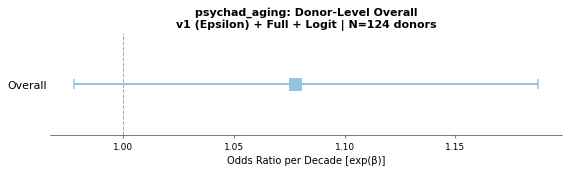

  ✓ Saved: psychad_aging_part2a_forest_overall.pdf/.svg

────────────────────────────────────────────────────────────────────────────────
FIGURE 2: Forest Plot - Per Cell Type
────────────────────────────────────────────────────────────────────────────────


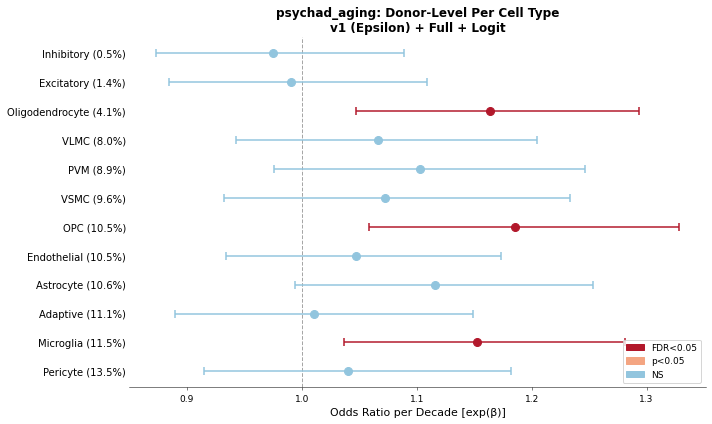

  ✓ Saved: psychad_aging_part2b_forest_celltype.pdf/.svg

────────────────────────────────────────────────────────────────────────────────
FIGURE 3: Scatter + Trendline - Overall
────────────────────────────────────────────────────────────────────────────────


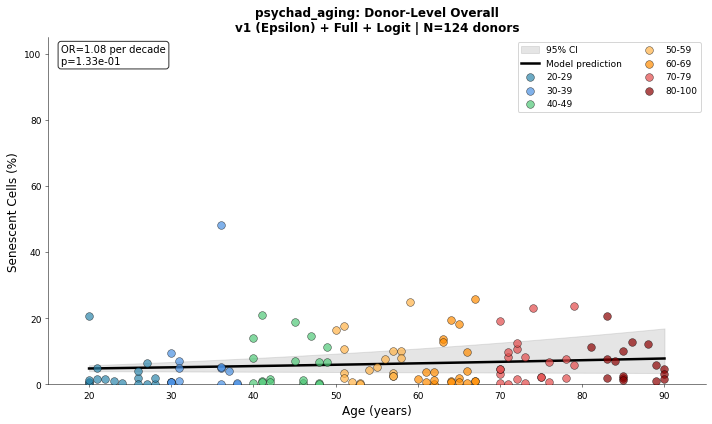

  ✓ Saved: psychad_aging_part2a_scatter_trendline.pdf/.svg

────────────────────────────────────────────────────────────────────────────────
FIGURE 4: Scatter + Trendline - Per Cell Type
────────────────────────────────────────────────────────────────────────────────


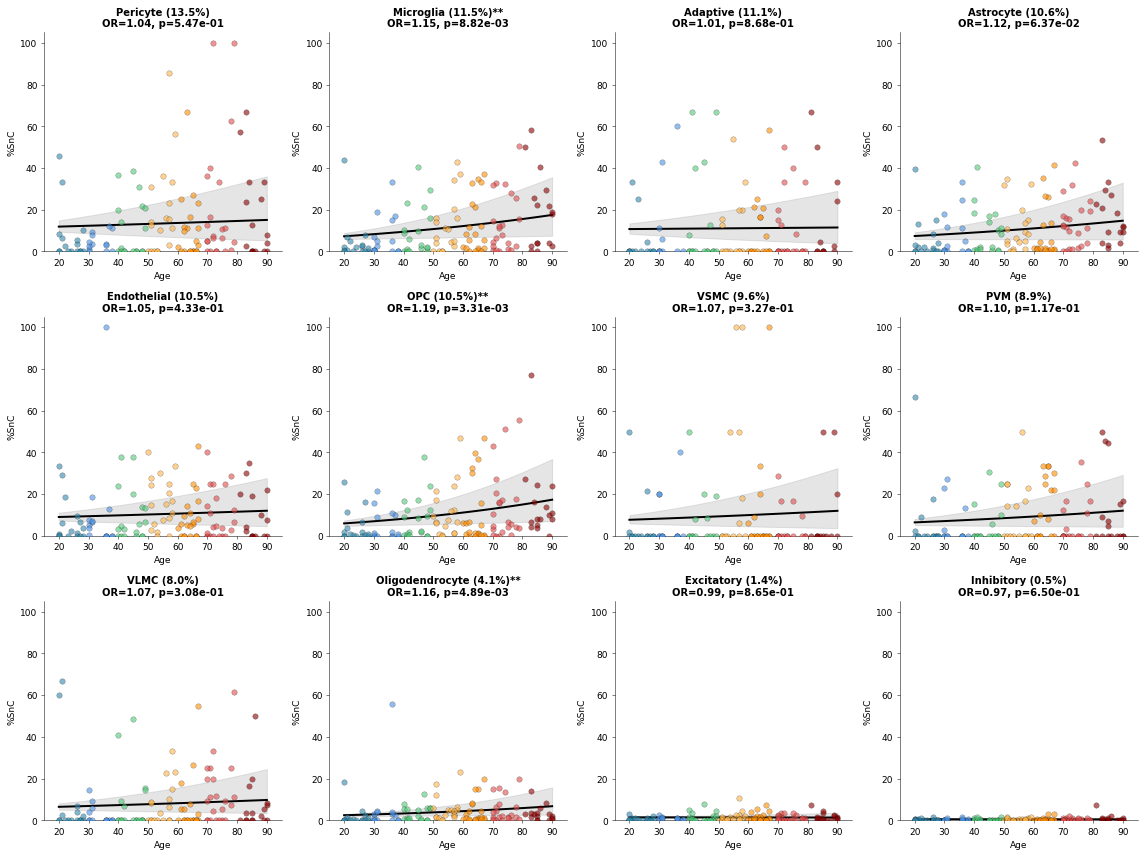

  ✓ Saved: psychad_aging_part2b_scatter_trendline.pdf/.svg

────────────────────────────────────────────────────────────────────────────────
FIGURE 5: Boxplot + Jitter by Study_Group - Overall
────────────────────────────────────────────────────────────────────────────────


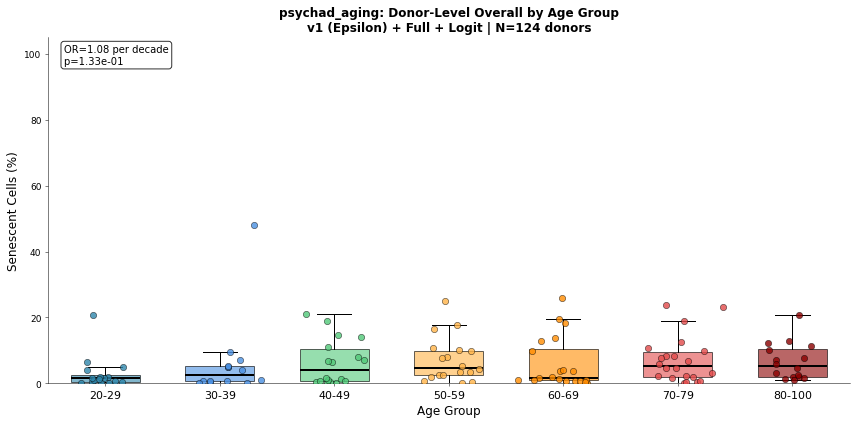

  ✓ Saved: psychad_aging_part2a_boxplot_studygroup.pdf/.svg

────────────────────────────────────────────────────────────────────────────────
FIGURE 6: Boxplot + Jitter by Study_Group - Per Cell Type
────────────────────────────────────────────────────────────────────────────────


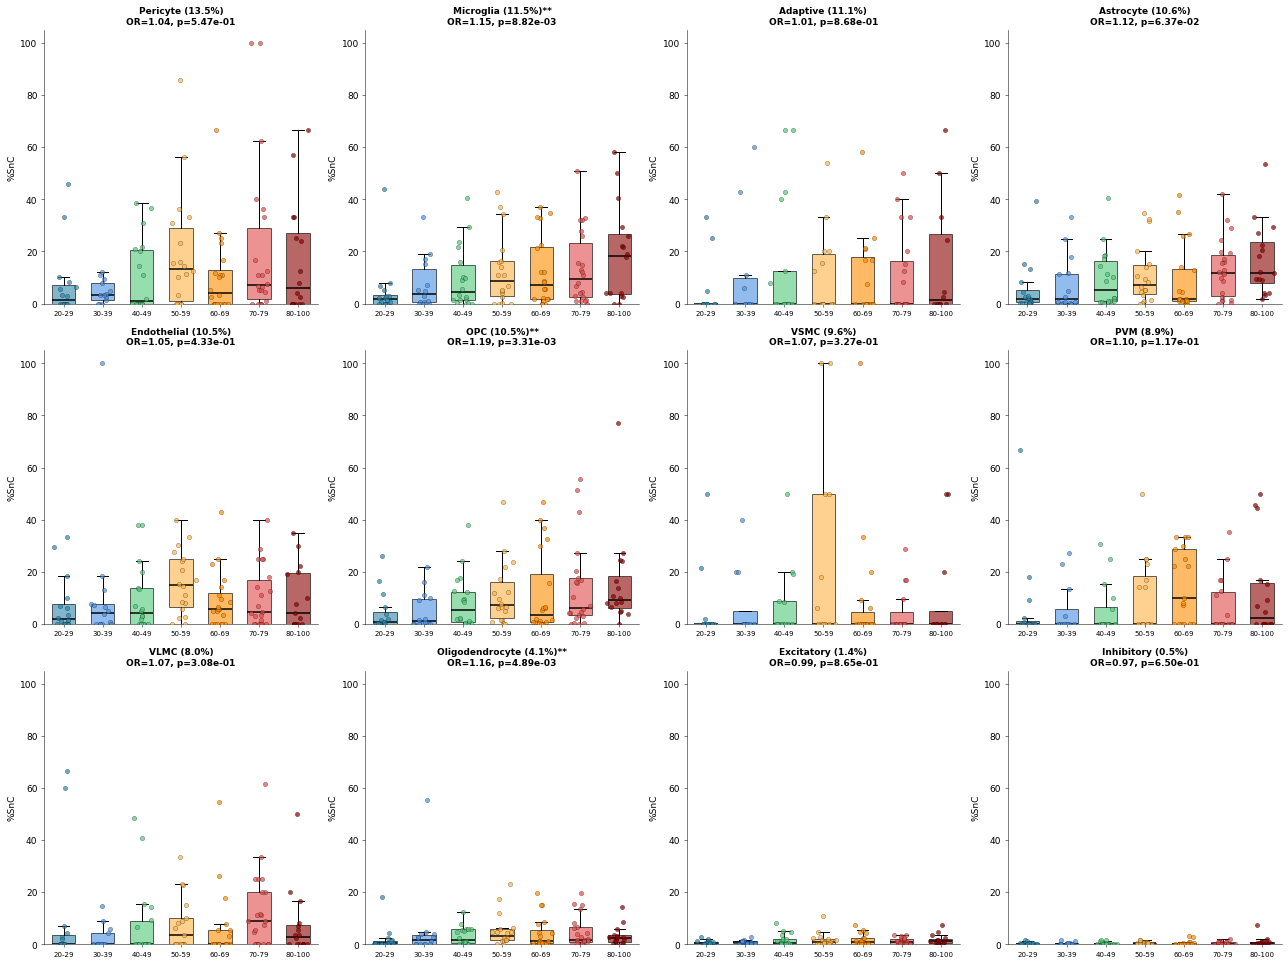

  ✓ Saved: psychad_aging_part2b_boxplot_studygroup.pdf/.svg

────────────────────────────────────────────────────────────────────────────────
FIGURE 7: Predicted Proportion - Per Cell Type (Boxplots by Age)
────────────────────────────────────────────────────────────────────────────────


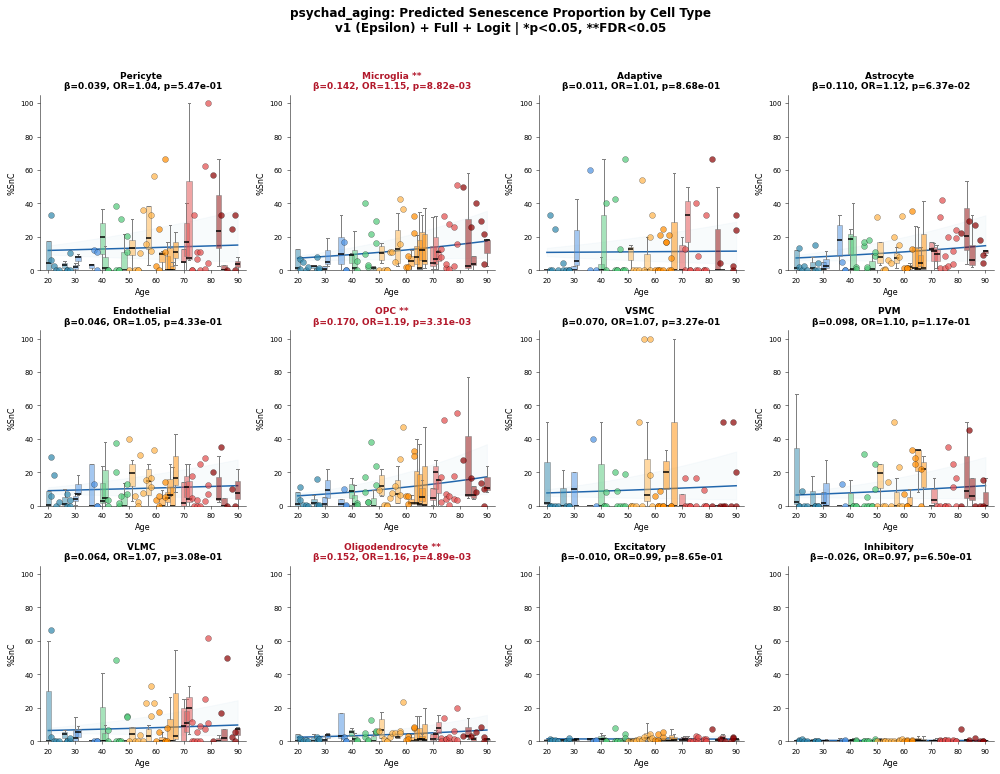

  ✓ Saved: psychad_aging_part2b_proportion_v1_full_logit.pdf/.svg

────────────────────────────────────────────────────────────────────────────────
FIGURE 8: % Donors with 0% SnC by Study Group
────────────────────────────────────────────────────────────────────────────────


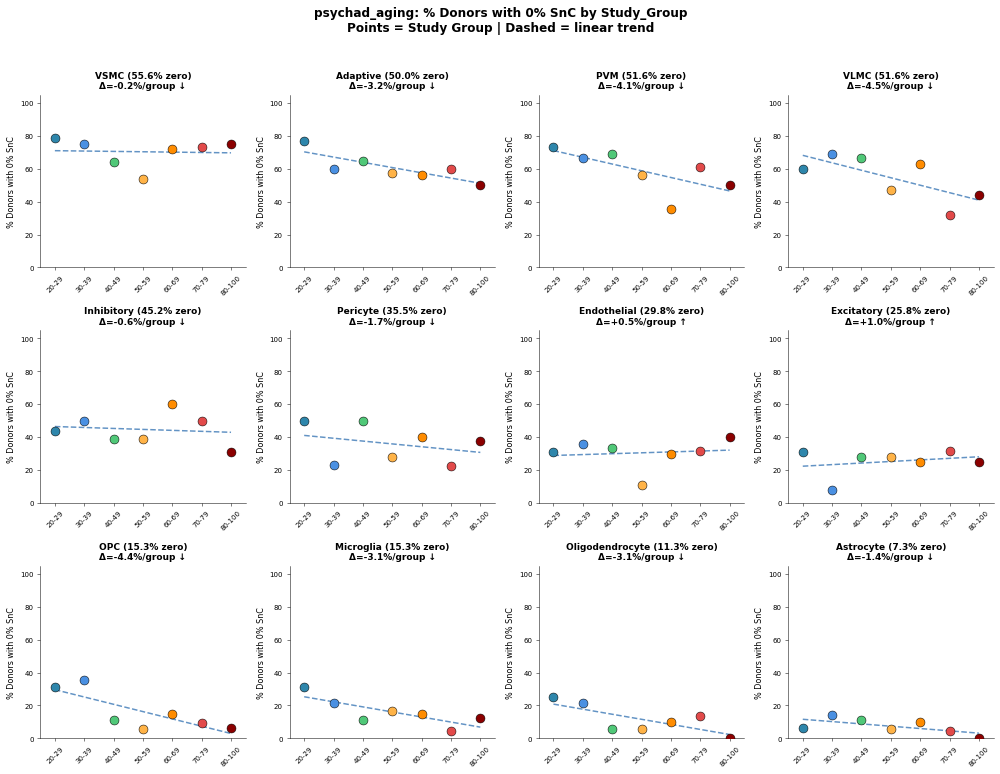

  ✓ Saved: psychad_aging_part2b_pct_zero.pdf/.svg

────────────────────────────────────────────────────────────────────────────────
FIGURE 9: Sample Composition by Cell Type
────────────────────────────────────────────────────────────────────────────────


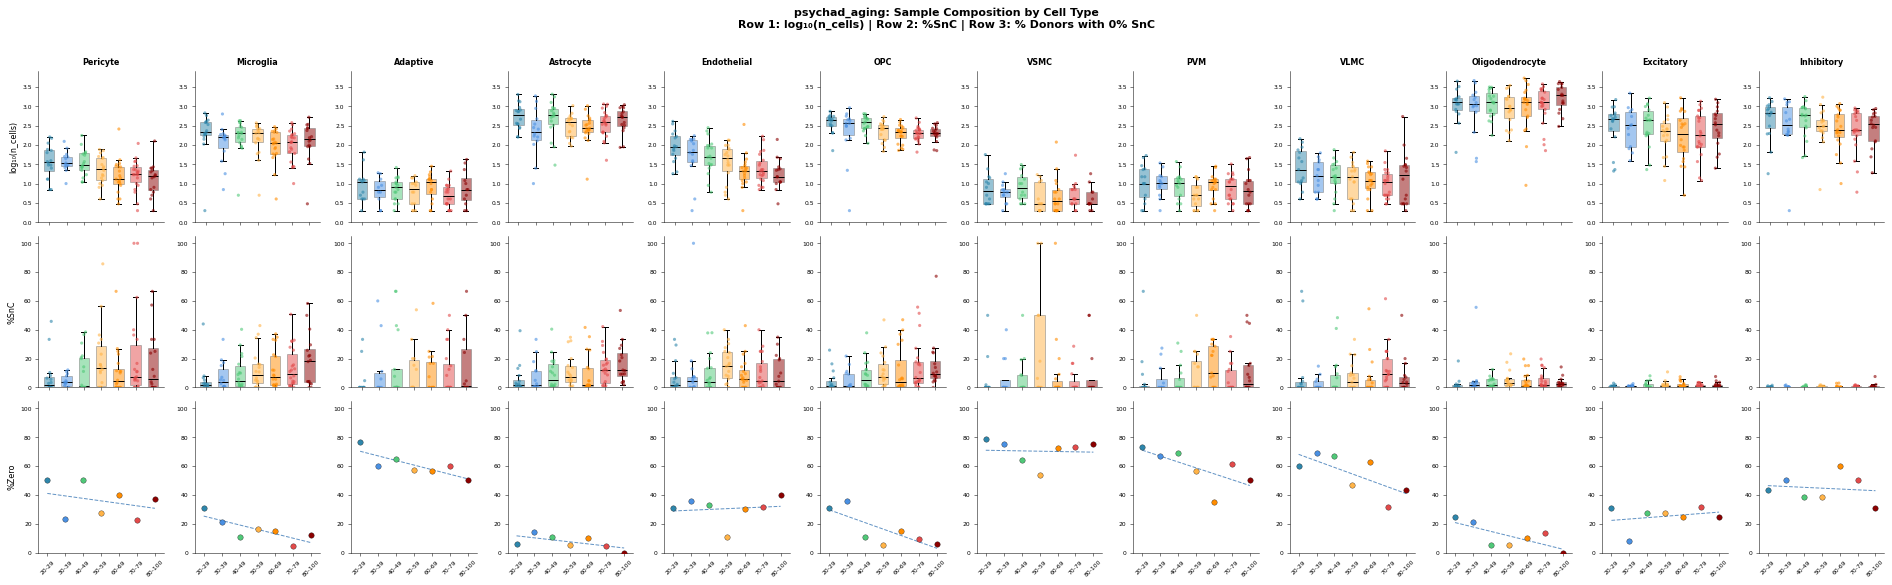

  ✓ Saved: psychad_aging_part2_sample_composition.pdf/.svg

────────────────────────────────────────────────────────────────────────────────
OUTPUT SUMMARY
────────────────────────────────────────────────────────────────────────────────

  Figures saved to: /fs/scratch/PAS2598/senescence_analysis/figures/02.5_probability_modeling/psychad_aging

  Files:
    1. psychad_aging_part2a_forest_overall.pdf/.svg
    2. psychad_aging_part2b_forest_celltype.pdf/.svg
    3. psychad_aging_part2a_scatter_trendline.pdf/.svg
    4. psychad_aging_part2b_scatter_trendline.pdf/.svg
    5. psychad_aging_part2a_boxplot_studygroup.pdf/.svg
    6. psychad_aging_part2b_boxplot_studygroup.pdf/.svg
    7. psychad_aging_part2b_proportion_v1_full_logit.pdf/.svg
    8. psychad_aging_part2b_pct_zero.pdf/.svg
    9. psychad_aging_part2_sample_composition.pdf/.svg

  Consistent formatting:
    β: 3 decimal places (e.g., 0.123)
    OR: 2 decimal places (e.g., 1.12)
    p-value: 2 decimal scientific (e.g., 1.23e-03)
 

In [21]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 9: PART 2 VISUALIZATION
# ════════════════════════════════════════════════════════════════════════════════
#
# Figures:
#   1. Forest Plot - Overall (df_results_2a)
#   2. Forest Plot - Per Cell Type (df_results_2b)
#   3. Scatter + Trendline - Overall (df_donor)
#   4. Scatter + Trendline - Per Cell Type (df_donor_ct)
#   5. Boxplot + Jitter by Study_Group - Overall (df_donor)
#   6. Boxplot + Jitter by Study_Group - Per Cell Type (df_donor_ct)
#   7. Predicted Proportion - Per Cell Type (boxplots by age + trendline)
#   8. % Donors with 0% SnC by Study Group
#   9. Sample Composition by Cell Type (3-row panel)
#
# Model: v1_full_logit
# Output: PDF + SVG
#
# ════════════════════════════════════════════════════════════════════════════════

print("="*80)
print("PART 2 VISUALIZATION")
print("="*80)

import matplotlib.patches as mpatches
from scipy.special import expit

# ─────────────────────────────────────────────────────────────────────────────────
# Configuration
# ─────────────────────────────────────────────────────────────────────────────────

MODEL_KEY = 'v1_full_logit'
MODEL_LABEL = 'v1 (Epsilon) + Full + Logit'

# Significance thresholds
SIG_FDR = 0.05
SIG_NOMINAL = 0.05

# Colors for significance
COLOR_FDR_SIG = '#B2182B'    # Dark red - FDR significant
COLOR_NOM_SIG = '#F4A582'    # Light red - nominally significant
COLOR_NS = '#92C5DE'         # Blue - not significant

# Colors for model/CI
COLOR_MODEL = '#2166AC'      # Blue - model line
COLOR_CI = '#D1E5F0'         # Light blue - CI band

# Study group colors (should match Cell 1)
STUDY_GROUP_COLORS = {
    'Age_20_29': '#2E86AB',
    'Age_30_39': '#4A90E2',
    'Age_40_49': '#50C878',
    'Age_50_59': '#FFB347',
    'Age_60_69': '#FF8C00',
    'Age_70_79': '#E24A4A',
    'Age_80_89': '#8B0000',
    'Age_80_100': '#8B0000',
    'Age_90_99': '#4A0000',
}

# Get ordered study groups from data
STUDY_GROUPS_ORDERED = sorted(
    df_donor[COL_STUDYGROUP].unique(),
    key=lambda x: int(x.split('_')[1]) if x.startswith('Age_') else 999
)
sg_order = STUDY_GROUPS_ORDERED  # Alias for compatibility

# Age range for predictions
age_min = df_donor[COL_AGE].min()
age_max = df_donor[COL_AGE].max()
age_range = np.linspace(age_min, age_max, 100)
age_scaled_range = age_range / AGE_SCALE

print(f"\nConfiguration:")
print(f"  Model: {MODEL_KEY}")
print(f"  Study groups: {STUDY_GROUPS_ORDERED}")

# Verify model columns exist
p_col = f'{MODEL_KEY}_P'
fdr_col = f'{MODEL_KEY}_FDR'
exp_beta_col = f'{MODEL_KEY}_exp_beta'

if p_col not in df_results_2b.columns:
    raise ValueError(f"Column {p_col} not found in df_results_2b")

print(f"  ✓ Model columns verified")

# ─────────────────────────────────────────────────────────────────────────────────
# Sort cell types by %SnC
# ─────────────────────────────────────────────────────────────────────────────────

ct_order = df_results_2b.sort_values('mean_prop', ascending=False)[COL_CELLTYPE].tolist()
print(f"\n  Cell types (sorted by %SnC): {ct_order}")

# ─────────────────────────────────────────────────────────────────────────────────
# Calculate global y-axis limits for consistency
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n  Calculating global axis limits...")

# %SnC limits (for scatter, boxplot, proportion plots)
y_max_snc = df_donor_ct['prop_snc'].max() * 100
y_min_snc = 0
y_lim_snc = (y_min_snc, y_max_snc * 1.05)  # 5% padding

# log10(n_cells) limits
y_max_log_cells = np.log10(df_donor_ct['n_cells'].max() + 1)
y_min_log_cells = np.log10(df_donor_ct['n_cells'].min() + 1)
y_lim_log_cells = (y_min_log_cells * 0.95, y_max_log_cells * 1.05)

# %Zero limits
y_lim_pct_zero = (0, 105)

print(f"    %SnC: {y_lim_snc}")
print(f"    log₁₀(n_cells): {y_lim_log_cells}")
print(f"    %Zero: {y_lim_pct_zero}")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1: FOREST PLOT - OVERALL
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*80}")
print("FIGURE 1: Forest Plot - Overall")
print(f"{'─'*80}")

fig, ax = plt.subplots(figsize=(8, 2.5))

ax.axvline(x=1, color='gray', linestyle='--', linewidth=1, alpha=0.7, zorder=1)

exp_beta = df_results_2a[f'{MODEL_KEY}_exp_beta'].values[0]
ci_lo = df_results_2a[f'{MODEL_KEY}_exp_beta_lower'].values[0]
ci_hi = df_results_2a[f'{MODEL_KEY}_exp_beta_upper'].values[0]
p_val = df_results_2a[f'{MODEL_KEY}_P'].values[0]
beta = df_results_2a[f'{MODEL_KEY}_beta'].values[0]

color = COLOR_NOM_SIG if p_val < SIG_NOMINAL else COLOR_NS

ax.errorbar(exp_beta, 0, xerr=[[exp_beta - ci_lo], [ci_hi - exp_beta]], 
            fmt='s', color=color, capsize=5, markersize=12, 
            capthick=1.5, elinewidth=2, zorder=3)

sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < SIG_NOMINAL else ""
ax.annotate(f'β={beta:.3f}, OR={exp_beta:.2f} [{ci_lo:.2f}, {ci_hi:.2f}], p={p_val:.2e} {sig}', 
            (ci_hi + 0.02, 0.15), fontsize=10, va='bottom')

ax.set_yticks([0])
ax.set_yticklabels(['Overall'], fontsize=11)
ax.set_xlabel('Odds Ratio per Decade [exp(β)]', fontsize=10)
ax.set_title(f'{DATASET}: Donor-Level Overall\n{MODEL_LABEL} | N={len(df_donor)} donors', 
             fontsize=11, fontweight='bold')
ax.set_ylim(-0.5, 0.5)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{DATASET}_part2a_forest_overall.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / f'{DATASET}_part2a_forest_overall.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved: {DATASET}_part2a_forest_overall.pdf/.svg")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2: FOREST PLOT - PER CELL TYPE
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*80}")
print("FIGURE 2: Forest Plot - Per Cell Type")
print(f"{'─'*80}")

df_plot = df_results_2b.set_index(COL_CELLTYPE).loc[ct_order].reset_index()

n_ct = len(df_plot)
fig, ax = plt.subplots(figsize=(10, max(4, n_ct * 0.5)))

ax.axvline(x=1, color='gray', linestyle='--', linewidth=1, alpha=0.7, zorder=1)

y_pos = range(n_ct)

for i, (_, row) in enumerate(df_plot.iterrows()):
    ct = row[COL_CELLTYPE]
    exp_b = row[f'{MODEL_KEY}_exp_beta']
    ci_lo = row[f'{MODEL_KEY}_exp_beta_lower']
    ci_hi = row[f'{MODEL_KEY}_exp_beta_upper']
    p_val = row[f'{MODEL_KEY}_P']
    fdr = row.get(f'{MODEL_KEY}_FDR', 1.0)
    
    if pd.notna(fdr) and fdr < SIG_FDR:
        color = COLOR_FDR_SIG
    elif pd.notna(p_val) and p_val < SIG_NOMINAL:
        color = COLOR_NOM_SIG
    else:
        color = COLOR_NS
    
    if pd.notna(exp_b):
        ax.errorbar(exp_b, i, xerr=[[exp_b - ci_lo], [ci_hi - exp_b]], 
                    fmt='o', color=color, capsize=4, markersize=8, 
                    capthick=1.5, elinewidth=1.5, zorder=3)

ax.set_yticks(y_pos)
ax.set_yticklabels([f"{row[COL_CELLTYPE]} ({row['mean_prop']:.1f}%)" for _, row in df_plot.iterrows()], fontsize=10)
ax.set_xlabel('Odds Ratio per Decade [exp(β)]', fontsize=11)
ax.set_title(f'{DATASET}: Donor-Level Per Cell Type\n{MODEL_LABEL}', fontsize=12, fontweight='bold')

fdr_patch = mpatches.Patch(color=COLOR_FDR_SIG, label='FDR<0.05')
nom_patch = mpatches.Patch(color=COLOR_NOM_SIG, label='p<0.05')
ns_patch = mpatches.Patch(color=COLOR_NS, label='NS')
ax.legend(handles=[fdr_patch, nom_patch, ns_patch], loc='lower right', fontsize=9)

ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{DATASET}_part2b_forest_celltype.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / f'{DATASET}_part2b_forest_celltype.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved: {DATASET}_part2b_forest_celltype.pdf/.svg")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 3: SCATTER + TRENDLINE - OVERALL
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*80}")
print("FIGURE 3: Scatter + Trendline - Overall")
print(f"{'─'*80}")

fig, ax = plt.subplots(figsize=(10, 6))

beta_age = df_results_2a[f'{MODEL_KEY}_beta'].values[0]
se_age = df_results_2a[f'{MODEL_KEY}_SE'].values[0]

baseline_prop = df_donor['prop_snc'].mean()
mean_age_scaled = df_donor['Age_scaled'].mean()
intercept = np.log(baseline_prop / (1 - baseline_prop)) - beta_age * mean_age_scaled

eta = intercept + beta_age * age_scaled_range
prob = 1 / (1 + np.exp(-eta))

eta_lo = intercept + (beta_age - 1.96 * se_age) * age_scaled_range
eta_hi = intercept + (beta_age + 1.96 * se_age) * age_scaled_range
prob_lo = 1 / (1 + np.exp(-eta_lo))
prob_hi = 1 / (1 + np.exp(-eta_hi))

ax.fill_between(age_range, prob_lo * 100, prob_hi * 100, alpha=0.2, color='gray', label='95% CI')
ax.plot(age_range, prob * 100, color='black', linewidth=2.5, label='Model prediction')

for sg in STUDY_GROUPS_ORDERED:
    mask = df_donor[COL_STUDYGROUP] == sg
    if mask.sum() > 0:
        color = STUDY_GROUP_COLORS.get(sg, 'gray')
        ax.scatter(df_donor.loc[mask, COL_AGE], 
                   df_donor.loc[mask, 'prop_snc'] * 100,
                   c=color, s=60, alpha=0.7, edgecolors='black', linewidths=0.5,
                   label=sg.replace('Age_', '').replace('_', '-'), zorder=5)

p_val = df_results_2a[f'{MODEL_KEY}_P'].values[0]
exp_beta = df_results_2a[f'{MODEL_KEY}_exp_beta'].values[0]
sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
ax.text(0.02, 0.98, f'OR={exp_beta:.2f} per decade\np={p_val:.2e} {sig}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Senescent Cells (%)', fontsize=12)
ax.set_title(f'{DATASET}: Donor-Level Overall\n{MODEL_LABEL} | N={len(df_donor)} donors', 
             fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.set_xlim(age_min - 5, age_max + 5)
ax.set_ylim(y_lim_snc)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{DATASET}_part2a_scatter_trendline.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / f'{DATASET}_part2a_scatter_trendline.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved: {DATASET}_part2a_scatter_trendline.pdf/.svg")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 4: SCATTER + TRENDLINE - PER CELL TYPE
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*80}")
print("FIGURE 4: Scatter + Trendline - Per Cell Type")
print(f"{'─'*80}")

n_cols = 4
n_rows = int(np.ceil(len(ct_order) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for idx, ct in enumerate(ct_order):
    ax = axes[idx]
    
    df_ct = df_donor_ct[df_donor_ct[COL_CELLTYPE] == ct].copy()
    ct_row = df_results_2b[df_results_2b[COL_CELLTYPE] == ct].iloc[0]
    
    beta_ct = ct_row.get(f'{MODEL_KEY}_beta', np.nan)
    se_ct = ct_row.get(f'{MODEL_KEY}_SE', np.nan)
    p_ct = ct_row.get(f'{MODEL_KEY}_P', np.nan)
    fdr_ct = ct_row.get(f'{MODEL_KEY}_FDR', np.nan)
    exp_beta_ct = ct_row.get(f'{MODEL_KEY}_exp_beta', np.nan)
    
    for sg in STUDY_GROUPS_ORDERED:
        mask = df_ct[COL_STUDYGROUP] == sg
        if mask.sum() > 0:
            color = STUDY_GROUP_COLORS.get(sg, 'gray')
            ax.scatter(df_ct.loc[mask, COL_AGE], 
                       df_ct.loc[mask, 'prop_snc'] * 100,
                       c=color, s=30, alpha=0.6, edgecolors='black', linewidths=0.3, zorder=5)
    
    if pd.notna(beta_ct):
        baseline_prop_ct = df_ct['prop_snc'].mean()
        mean_age_scaled_ct = df_ct['Age_scaled'].mean()
        
        if baseline_prop_ct > 0 and baseline_prop_ct < 1:
            intercept_ct = np.log(baseline_prop_ct / (1 - baseline_prop_ct)) - beta_ct * mean_age_scaled_ct
            
            eta_ct = intercept_ct + beta_ct * age_scaled_range
            prob_ct = 1 / (1 + np.exp(-eta_ct))
            
            eta_lo_ct = intercept_ct + (beta_ct - 1.96 * se_ct) * age_scaled_range
            eta_hi_ct = intercept_ct + (beta_ct + 1.96 * se_ct) * age_scaled_range
            prob_lo_ct = 1 / (1 + np.exp(-eta_lo_ct))
            prob_hi_ct = 1 / (1 + np.exp(-eta_hi_ct))
            
            ax.fill_between(age_range, prob_lo_ct * 100, prob_hi_ct * 100, alpha=0.2, color='gray')
            ax.plot(age_range, prob_ct * 100, color='black', linewidth=2)
    
    sig = "**" if pd.notna(fdr_ct) and fdr_ct < 0.05 else "*" if pd.notna(p_ct) and p_ct < 0.05 else ""
    title = f"{ct} ({ct_row['mean_prop']:.1f}%){sig}"
    if pd.notna(exp_beta_ct):
        title += f"\nOR={exp_beta_ct:.2f}, p={p_ct:.2e}"
    ax.set_title(title, fontsize=10, fontweight='bold')
    
    ax.set_xlabel('Age', fontsize=9)
    ax.set_ylabel('%SnC', fontsize=9)
    ax.set_xlim(age_min - 5, age_max + 5)
    ax.set_ylim(y_lim_snc)  # Consistent y-axis

for idx in range(len(ct_order), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{DATASET}_part2b_scatter_trendline.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / f'{DATASET}_part2b_scatter_trendline.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved: {DATASET}_part2b_scatter_trendline.pdf/.svg")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 5: BOXPLOT + JITTER BY STUDY_GROUP - OVERALL
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*80}")
print("FIGURE 5: Boxplot + Jitter by Study_Group - Overall")
print(f"{'─'*80}")

fig, ax = plt.subplots(figsize=(12, 6))

box_data = [df_donor[df_donor[COL_STUDYGROUP] == sg]['prop_snc'].values * 100 for sg in STUDY_GROUPS_ORDERED]
box_colors = [STUDY_GROUP_COLORS.get(sg, 'gray') for sg in STUDY_GROUPS_ORDERED]

bp = ax.boxplot(box_data, positions=range(len(STUDY_GROUPS_ORDERED)), widths=0.6, patch_artist=True,
                showfliers=False, zorder=2)

for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)

for i, sg in enumerate(STUDY_GROUPS_ORDERED):
    mask = df_donor[COL_STUDYGROUP] == sg
    y = df_donor.loc[mask, 'prop_snc'].values * 100
    x = np.random.normal(i, 0.15, size=len(y))
    color = STUDY_GROUP_COLORS.get(sg, 'gray')
    ax.scatter(x, y, c=color, s=40, alpha=0.8, edgecolors='black', linewidths=0.5, zorder=3)

ax.set_xticks(range(len(STUDY_GROUPS_ORDERED)))
ax.set_xticklabels([sg.replace('Age_', '').replace('_', '-') for sg in STUDY_GROUPS_ORDERED], fontsize=11, ha='center')
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Senescent Cells (%)', fontsize=12)

p_val = df_results_2a[f'{MODEL_KEY}_P'].values[0]
exp_beta = df_results_2a[f'{MODEL_KEY}_exp_beta'].values[0]
sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
ax.text(0.02, 0.98, f'OR={exp_beta:.2f} per decade\np={p_val:.2e} {sig}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_title(f'{DATASET}: Donor-Level Overall by Age Group\n{MODEL_LABEL} | N={len(df_donor)} donors', 
             fontsize=12, fontweight='bold')
ax.set_ylim(y_lim_snc)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{DATASET}_part2a_boxplot_studygroup.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / f'{DATASET}_part2a_boxplot_studygroup.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved: {DATASET}_part2a_boxplot_studygroup.pdf/.svg")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 6: BOXPLOT + JITTER BY STUDY_GROUP - PER CELL TYPE
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*80}")
print("FIGURE 6: Boxplot + Jitter by Study_Group - Per Cell Type")
print(f"{'─'*80}")

n_cols = 4
n_rows = int(np.ceil(len(ct_order) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows))
axes = axes.flatten()

for idx, ct in enumerate(ct_order):
    ax = axes[idx]
    
    df_ct = df_donor_ct[df_donor_ct[COL_CELLTYPE] == ct].copy()
    ct_row = df_results_2b[df_results_2b[COL_CELLTYPE] == ct].iloc[0]
    
    box_data = [df_ct[df_ct[COL_STUDYGROUP] == sg]['prop_snc'].values * 100 for sg in STUDY_GROUPS_ORDERED]
    box_colors = [STUDY_GROUP_COLORS.get(sg, 'gray') for sg in STUDY_GROUPS_ORDERED]
    
    bp = ax.boxplot(box_data, positions=range(len(STUDY_GROUPS_ORDERED)), widths=0.6, patch_artist=True,
                    showfliers=False, zorder=2)
    
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(1.5)
    
    for i, sg in enumerate(STUDY_GROUPS_ORDERED):
        mask = df_ct[COL_STUDYGROUP] == sg
        y = df_ct.loc[mask, 'prop_snc'].values * 100
        if len(y) > 0:
            x = np.random.normal(i, 0.12, size=len(y))
            color = STUDY_GROUP_COLORS.get(sg, 'gray')
            ax.scatter(x, y, c=color, s=20, alpha=0.7, edgecolors='black', linewidths=0.3, zorder=3)
    
    ax.set_xticks(range(len(STUDY_GROUPS_ORDERED)))
    ax.set_xticklabels([sg.replace('Age_', '').replace('_', '-') for sg in STUDY_GROUPS_ORDERED], 
                       fontsize=7, ha='center')
    
    p_ct = ct_row.get(f'{MODEL_KEY}_P', np.nan)
    fdr_ct = ct_row.get(f'{MODEL_KEY}_FDR', np.nan)
    exp_beta_ct = ct_row.get(f'{MODEL_KEY}_exp_beta', np.nan)
    
    sig = "**" if pd.notna(fdr_ct) and fdr_ct < 0.05 else "*" if pd.notna(p_ct) and p_ct < 0.05 else ""
    title = f"{ct} ({ct_row['mean_prop']:.1f}%){sig}"
    if pd.notna(exp_beta_ct):
        title += f"\nOR={exp_beta_ct:.2f}, p={p_ct:.2e}"
    ax.set_title(title, fontsize=9, fontweight='bold')
    
    ax.set_ylabel('%SnC', fontsize=9)
    ax.set_ylim(y_lim_snc)  # Consistent y-axis

for idx in range(len(ct_order), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{DATASET}_part2b_boxplot_studygroup.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / f'{DATASET}_part2b_boxplot_studygroup.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved: {DATASET}_part2b_boxplot_studygroup.pdf/.svg")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 7: PREDICTED PROPORTION - PER CELL TYPE (Boxplots by Age + Trendline)
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*80}")
print("FIGURE 7: Predicted Proportion - Per Cell Type (Boxplots by Age)")
print(f"{'─'*80}")

n_cts = len(ct_order)
n_cols = 4
n_rows = int(np.ceil(n_cts / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows))
axes = axes.flatten()

for idx, ct in enumerate(ct_order):
    ax = axes[idx]
    
    row = df_results_2b[df_results_2b[COL_CELLTYPE] == ct].iloc[0]
    df_ct = df_donor_ct[df_donor_ct[COL_CELLTYPE] == ct].copy()
    
    if pd.isna(row.get(f'{MODEL_KEY}_beta')):
        ax.text(0.5, 0.5, 'Model failed', ha='center', va='center', 
                transform=ax.transAxes, fontsize=10, color='gray')
        ax.set_title(ct, fontsize=10, fontweight='bold')
        ax.set_xlim(age_min - 5, age_max + 5)
        ax.set_ylim(y_lim_snc)
        continue
    
    beta_age = row[f'{MODEL_KEY}_beta']
    se_age = row[f'{MODEL_KEY}_SE']
    exp_beta = row[f'{MODEL_KEY}_exp_beta']
    p_val = row[f'{MODEL_KEY}_P']
    fdr_val = row.get(f'{MODEL_KEY}_FDR', 1.0)
    
    mean_prop = df_ct['prop_snc'].mean()
    mean_age_scaled = df_ct['Age_scaled'].mean()
    if 0 < mean_prop < 1:
        intercept = np.log(mean_prop / (1 - mean_prop)) - beta_age * mean_age_scaled
    else:
        intercept = -2.5
    
    eta = intercept + beta_age * age_scaled_range
    mu = expit(eta)
    
    eta_lo = intercept + (beta_age - 1.96 * se_age) * age_scaled_range
    eta_hi = intercept + (beta_age + 1.96 * se_age) * age_scaled_range
    mu_lo = expit(eta_lo)
    mu_hi = expit(eta_hi)
    
    ax.fill_between(age_range, mu_lo * 100, mu_hi * 100, 
                    alpha=0.15, color=COLOR_CI, zorder=1)
    ax.plot(age_range, mu * 100, color=COLOR_MODEL, linewidth=1.5, zorder=2)
    
    ages_unique = sorted(df_ct[COL_AGE].unique())
    
    for age in ages_unique:
        age_data = df_ct[df_ct[COL_AGE] == age]
        n_donors_age = len(age_data)
        
        if n_donors_age >= 3:
            dominant_sg = age_data[COL_STUDYGROUP].mode().iloc[0]
            box_color = STUDY_GROUP_COLORS.get(dominant_sg, 'gray')
            
            bp = ax.boxplot([age_data['prop_snc'].values * 100], 
                           positions=[age], widths=2,
                           patch_artist=True, manage_ticks=False)
            bp['boxes'][0].set_facecolor(box_color)
            bp['boxes'][0].set_alpha(0.5)
            bp['boxes'][0].set_edgecolor('gray')
            bp['medians'][0].set_color('black')
            bp['medians'][0].set_linewidth(1.5)
            for whisker in bp['whiskers']:
                whisker.set_color('gray')
            for cap in bp['caps']:
                cap.set_color('gray')
            for flier in bp['fliers']:
                flier.set_visible(False)
        else:
            for _, donor_row in age_data.iterrows():
                color = STUDY_GROUP_COLORS.get(donor_row[COL_STUDYGROUP], 'gray')
                ax.scatter(age, donor_row['prop_snc'] * 100, c=[color], 
                          s=35, alpha=0.7, edgecolors='black', linewidths=0.3, zorder=5)
    
    sig_marker = "**" if fdr_val < SIG_FDR else "*" if p_val < SIG_NOMINAL else ""
    title_color = COLOR_FDR_SIG if fdr_val < SIG_FDR else (COLOR_NOM_SIG if p_val < SIG_NOMINAL else 'black')
    
    ax.set_title(f"{ct} {sig_marker}\nβ={beta_age:.3f}, OR={exp_beta:.2f}, p={p_val:.2e}", 
                 fontsize=9, fontweight='bold', color=title_color)
    
    ax.set_xlabel(COL_AGE, fontsize=8)
    ax.set_ylabel('%SnC', fontsize=8)
    ax.set_xlim(age_min - 3, age_max + 3)
    ax.set_ylim(y_lim_snc)  # Consistent y-axis
    ax.tick_params(labelsize=7)

for idx in range(n_cts, len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'{DATASET}: Predicted Senescence Proportion by Cell Type\n{MODEL_LABEL} | *p<{SIG_NOMINAL}, **FDR<{SIG_FDR}', 
             fontsize=12, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{DATASET}_part2b_proportion_{MODEL_KEY}.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / f'{DATASET}_part2b_proportion_{MODEL_KEY}.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved: {DATASET}_part2b_proportion_{MODEL_KEY}.pdf/.svg")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 8: % DONORS WITH 0% SnC BY STUDY GROUP
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*80}")
print("FIGURE 8: % Donors with 0% SnC by Study Group")
print(f"{'─'*80}")

ct_order_zero = df_results_2b.sort_values('pct_zeros', ascending=False)[COL_CELLTYPE].tolist()
n_cts = len(ct_order_zero)

n_cols = 4
n_rows = int(np.ceil(n_cts / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5 * n_rows))
axes = axes.flatten()

for idx, ct in enumerate(ct_order_zero):
    ax = axes[idx]
    
    df_ct = df_donor_ct[df_donor_ct[COL_CELLTYPE] == ct].copy()
    
    if len(df_ct) < 10:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', 
                transform=ax.transAxes, fontsize=10, color='gray')
        ax.set_title(ct, fontsize=10, fontweight='bold')
        ax.set_ylim(y_lim_pct_zero)
        continue
    
    pct_zero_list = []
    x_positions = []
    sg_valid = []
    
    for i, sg in enumerate(sg_order):
        sg_data = df_ct[df_ct[COL_STUDYGROUP] == sg]
        if len(sg_data) >= 3:
            pct_zero = (sg_data['prop_snc'] == 0).mean() * 100
            pct_zero_list.append(pct_zero)
            x_positions.append(i)
            sg_valid.append(sg)
    
    if len(pct_zero_list) < 2:
        ax.text(0.5, 0.5, 'Insufficient groups', ha='center', va='center', 
                transform=ax.transAxes, fontsize=10, color='gray')
        ax.set_title(ct, fontsize=10, fontweight='bold')
        ax.set_ylim(y_lim_pct_zero)
        continue
    
    for x_pos, sg, pct in zip(x_positions, sg_valid, pct_zero_list):
        color = STUDY_GROUP_COLORS.get(sg, 'gray')
        ax.scatter(x_pos, pct, c=[color], s=80, edgecolors='black', linewidths=0.5, zorder=5)
    
    slope = 0
    direction = ''
    if len(x_positions) >= 3:
        z = np.polyfit(x_positions, pct_zero_list, 1)
        p_trend = np.poly1d(z)
        x_line = np.linspace(min(x_positions), max(x_positions), 100)
        ax.plot(x_line, p_trend(x_line), color=COLOR_MODEL, linewidth=1.5, 
                linestyle='--', alpha=0.7, zorder=2)
        slope = z[0]
        direction = '↓' if slope < 0 else '↑' if slope > 0 else ''
    
    overall_pct_zero = (df_ct['prop_snc'] == 0).mean() * 100
    
    ax.set_title(f"{ct} ({overall_pct_zero:.1f}% zero)\nΔ={slope:+.1f}%/group {direction}", 
                 fontsize=9, fontweight='bold')
    
    ax.set_xticks(range(len(sg_order)))
    sg_labels = [sg.replace('Age_', '').replace('_', '-') for sg in sg_order]
    ax.set_xticklabels(sg_labels, fontsize=7, ha='center', rotation=45)
    
    ax.set_xlim(-0.5, len(sg_order) - 0.5)
    ax.set_ylabel('% Donors with 0% SnC', fontsize=8)
    ax.set_ylim(y_lim_pct_zero)  # Consistent y-axis
    ax.tick_params(labelsize=7)

for idx in range(n_cts, len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'{DATASET}: % Donors with 0% SnC by {COL_STUDYGROUP}\nPoints = Study Group | Dashed = linear trend', 
             fontsize=12, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{DATASET}_part2b_pct_zero.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / f'{DATASET}_part2b_pct_zero.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved: {DATASET}_part2b_pct_zero.pdf/.svg")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 9: SAMPLE COMPOSITION BY CELL TYPE (3-row panel)
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*80}")
print("FIGURE 9: Sample Composition by Cell Type")
print(f"{'─'*80}")

ct_order_comp = df_results_2b.sort_values('mean_prop', ascending=False)[COL_CELLTYPE].tolist()
n_cts = len(ct_order_comp)

fig, axes = plt.subplots(3, n_cts, figsize=(2.2 * n_cts, 8))

for ct_idx, ct in enumerate(ct_order_comp):
    df_ct = df_donor_ct[df_donor_ct[COL_CELLTYPE] == ct].copy()
    
    # ─────────────────────────────────────────────────────────────────────────
    # Row 0: log₁₀(n_cells) per donor per study group
    # ─────────────────────────────────────────────────────────────────────────
    ax = axes[0, ct_idx]
    
    for i, sg in enumerate(sg_order):
        sg_data = df_ct[df_ct[COL_STUDYGROUP] == sg]['n_cells'].dropna()
        if len(sg_data) == 0:
            continue
        
        color = STUDY_GROUP_COLORS.get(sg, 'gray')
        sg_data_log = np.log10(sg_data.values + 1)
        
        if len(sg_data) >= 3:
            bp = ax.boxplot([sg_data_log], positions=[i], widths=0.6, 
                           patch_artist=True, manage_ticks=False)
            bp['boxes'][0].set_facecolor(color)
            bp['boxes'][0].set_alpha(0.5)
            bp['boxes'][0].set_edgecolor('gray')
            bp['medians'][0].set_color('black')
            for flier in bp['fliers']:
                flier.set_visible(False)
        
        jitter_x = np.random.uniform(-0.15, 0.15, len(sg_data))
        ax.scatter(i + jitter_x, sg_data_log, c=[color]*len(sg_data), 
                  s=10, alpha=0.6, edgecolors='none', zorder=5)
    
    ax.set_title(ct, fontsize=8, fontweight='bold')
    ax.set_xticks(range(len(sg_order)))
    ax.set_xticklabels([])
    if ct_idx == 0:
        ax.set_ylabel('log₁₀(n_cells)', fontsize=8)
    ax.set_ylim(y_lim_log_cells)  # Consistent y-axis
    ax.tick_params(labelsize=6)
    
    # ─────────────────────────────────────────────────────────────────────────
    # Row 1: % SnC per donor per study group
    # ─────────────────────────────────────────────────────────────────────────
    ax = axes[1, ct_idx]
    
    for i, sg in enumerate(sg_order):
        sg_data = df_ct[df_ct[COL_STUDYGROUP] == sg]['prop_snc'].dropna() * 100
        if len(sg_data) == 0:
            continue
        
        color = STUDY_GROUP_COLORS.get(sg, 'gray')
        
        if len(sg_data) >= 3:
            bp = ax.boxplot([sg_data.values], positions=[i], widths=0.6, 
                           patch_artist=True, manage_ticks=False)
            bp['boxes'][0].set_facecolor(color)
            bp['boxes'][0].set_alpha(0.5)
            bp['boxes'][0].set_edgecolor('gray')
            bp['medians'][0].set_color('black')
            for flier in bp['fliers']:
                flier.set_visible(False)
        
        jitter_x = np.random.uniform(-0.15, 0.15, len(sg_data))
        ax.scatter(i + jitter_x, sg_data.values, c=[color]*len(sg_data), 
                  s=10, alpha=0.6, edgecolors='none', zorder=5)
    
    ax.set_xticks(range(len(sg_order)))
    ax.set_xticklabels([])
    if ct_idx == 0:
        ax.set_ylabel('%SnC', fontsize=8)
    ax.set_ylim(y_lim_snc)  # Consistent y-axis
    ax.tick_params(labelsize=6)
    
    # ─────────────────────────────────────────────────────────────────────────
    # Row 2: % Zero per study group (point + trend)
    # ─────────────────────────────────────────────────────────────────────────
    ax = axes[2, ct_idx]
    
    pct_zero_list = []
    x_positions = []
    sg_valid = []
    
    for i, sg in enumerate(sg_order):
        sg_data = df_ct[df_ct[COL_STUDYGROUP] == sg]
        if len(sg_data) >= 3:
            pct_zero = (sg_data['prop_snc'] == 0).mean() * 100
            pct_zero_list.append(pct_zero)
            x_positions.append(i)
            sg_valid.append(sg)
    
    if len(pct_zero_list) > 0:
        for x_pos, sg, pct in zip(x_positions, sg_valid, pct_zero_list):
            color = STUDY_GROUP_COLORS.get(sg, 'gray')
            ax.scatter(x_pos, pct, c=[color], s=30, edgecolors='black', linewidths=0.3, zorder=5)
        
        if len(x_positions) >= 3:
            z = np.polyfit(x_positions, pct_zero_list, 1)
            p_line = np.poly1d(z)
            x_line = np.linspace(min(x_positions), max(x_positions), 100)
            ax.plot(x_line, p_line(x_line), color=COLOR_MODEL, linewidth=1, 
                    linestyle='--', alpha=0.7, zorder=2)
    
    ax.set_xticks(range(len(sg_order)))
    sg_labels = [sg.replace('Age_', '').replace('_', '-') for sg in sg_order]
    ax.set_xticklabels(sg_labels, fontsize=6, ha='center', rotation=45)
    
    ax.set_xlim(-0.5, len(sg_order) - 0.5)
    ax.set_ylim(y_lim_pct_zero)  # Consistent y-axis
    if ct_idx == 0:
        ax.set_ylabel('%Zero', fontsize=8)
    ax.tick_params(labelsize=6)

plt.suptitle(f'{DATASET}: Sample Composition by Cell Type\nRow 1: log₁₀(n_cells) | Row 2: %SnC | Row 3: % Donors with 0% SnC', 
             fontsize=11, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f'{DATASET}_part2_sample_composition.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / f'{DATASET}_part2_sample_composition.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved: {DATASET}_part2_sample_composition.pdf/.svg")

# ─────────────────────────────────────────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*80}")
print("OUTPUT SUMMARY")
print(f"{'─'*80}")

print(f"\n  Figures saved to: {FIGURES_DIR}")
print(f"\n  Files:")
print(f"    1. {DATASET}_part2a_forest_overall.pdf/.svg")
print(f"    2. {DATASET}_part2b_forest_celltype.pdf/.svg")
print(f"    3. {DATASET}_part2a_scatter_trendline.pdf/.svg")
print(f"    4. {DATASET}_part2b_scatter_trendline.pdf/.svg")
print(f"    5. {DATASET}_part2a_boxplot_studygroup.pdf/.svg")
print(f"    6. {DATASET}_part2b_boxplot_studygroup.pdf/.svg")
print(f"    7. {DATASET}_part2b_proportion_{MODEL_KEY}.pdf/.svg")
print(f"    8. {DATASET}_part2b_pct_zero.pdf/.svg")
print(f"    9. {DATASET}_part2_sample_composition.pdf/.svg")

print(f"\n  Consistent formatting:")
print(f"    β: 3 decimal places (e.g., 0.123)")
print(f"    OR: 2 decimal places (e.g., 1.12)")
print(f"    p-value: 2 decimal scientific (e.g., 1.23e-03)")
print(f"    %: 1 decimal place (e.g., 12.3%)")
print(f"    CI: 2 decimal places (e.g., [0.95, 1.15])")

print(f"\n  Consistent y-axis limits:")
print(f"    %SnC: {y_lim_snc}")
print(f"    log₁₀(n_cells): {y_lim_log_cells}")
print(f"    %Zero: {y_lim_pct_zero}")

print(f"\n✓ Part 2 Visualization complete")

PART 3: GROUP COMPARISONS - psychad_aging

▸ Defining comparison groups...
  Cohort type: aging
  Young: ['Age_20_29', 'Age_30_39']
  Old: ['Age_70_79', 'Age_80_100']

  Donors in comparison:
    Young: 30
    Old: 38
    Total: 68 (excluded: 56)

────────────────────────────────────────────────────────────
PART 3A: OVERALL GROUP COMPARISON
────────────────────────────────────────────────────────────

  Young (n=30): Mean=4.49%, Median=1.47%
  Old (n=38): Mean=6.94%, Median=5.25%

  Mann-Whitney U=316.0, p=1.74e-03
  Cliff's δ=-0.446 (medium)
  Result: Old > Young **

────────────────────────────────────────────────────────────
PART 3B: PER CELL TYPE GROUP COMPARISON
────────────────────────────────────────────────────────────

  Cell_Type           n1  n2  Mean1  Mean2      δ         p       FDR     Effect
  -------------------------------------------------------------------------------------
  OPC                 30  38   4.74  14.69 -0.506  3.57e-04  3.26e-03    large**
  Astrocyte 

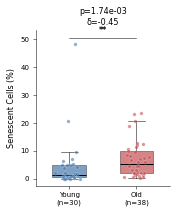

  ✓ Saved

▸ Figure 2: Effect Size Forest Plot


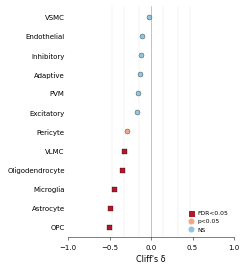

  ✓ Saved

▸ Figure 3: Per Cell Type Boxplots


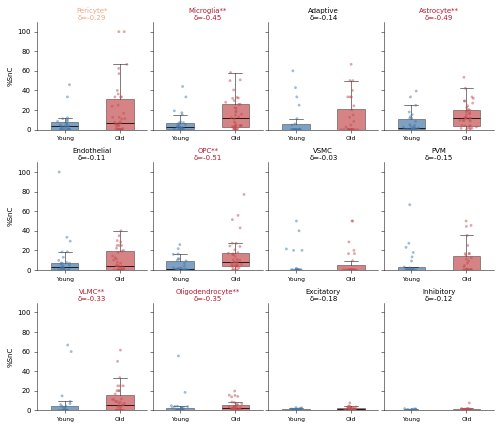

  ✓ Saved

▸ Figure 4: % Change Bar Chart


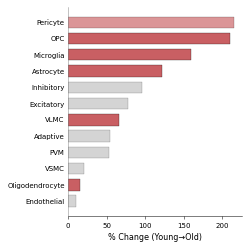

  ✓ Saved

▸ Figure 5: % Zero Comparison


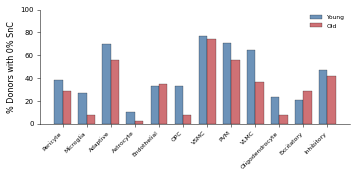

  ✓ Saved

PART 3 COMPLETE: psychad_aging

Comparison: Young vs Old
  Young: ['Age_20_29', 'Age_30_39']
  Old: ['Age_70_79', 'Age_80_100']

Results:
  Part 3A Overall: p=1.74e-03, δ=-0.446 (medium)
  Part 3B Per Cell_Type: 6 nominal, 5 FDR-significant

Files saved to: /fs/scratch/PAS2598/senescence_analysis/results/02.5_probability_modeling/psychad_aging
  - part3a_overall_comparison.csv
  - part3b_celltype_comparison.csv

Figures saved to: /fs/scratch/PAS2598/senescence_analysis/figures/02.5_probability_modeling/psychad_aging
  1. part3a_overall_comparison.pdf/.svg
  2. part3b_effect_size_forest.pdf/.svg
  3. part3b_celltype_boxplots.pdf/.svg
  4. part3b_pct_change_bar.pdf/.svg
  5. part3b_pct_zero_comparison.pdf/.svg

✓ Part 3 complete → Cell 11: Export All Results


In [22]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 10: PART 3 - GROUP COMPARISONS (Young vs Old)
# ════════════════════════════════════════════════════════════════════════════════
#
# Part 3A: Overall group comparison (Mann-Whitney U + Cliff's δ)
# Part 3B: Per cell type group comparison with FDR correction
#
# Visualizations (publication-quality):
#   1. Overall boxplot comparison
#   2. Effect size forest plot
#   3. Per cell type boxplots
#   4. % Change bar chart
#   5. % Zero comparison
#
# Output: PDF + SVG
#
# ════════════════════════════════════════════════════════════════════════════════

print("="*60)
print(f"PART 3: GROUP COMPARISONS - {DATASET}")
print("="*60)

from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────────────────────
# Publication-quality plot settings
# ─────────────────────────────────────────────────────────────────────────────────

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 3,
    'ytick.major.size': 3,
    'lines.linewidth': 1,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ─────────────────────────────────────────────────────────────────────────────────
# Configuration
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n▸ Defining comparison groups...")

is_aging = any(sg.startswith('Age_') for sg in STUDY_GROUPS_ORDERED)

if is_aging:
    print(f"  Cohort type: aging")
    YOUNG_GROUPS = STUDY_GROUPS_ORDERED[:2]
    OLD_GROUPS = STUDY_GROUPS_ORDERED[-2:]
    GROUP1_NAME = 'Young'
    GROUP2_NAME = 'Old'
    GROUP1_COLOR = '#4878A8'  # Muted blue
    GROUP2_COLOR = '#C44E52'  # Muted red
else:
    print(f"  Cohort type: disease")
    YOUNG_GROUPS = ['Control', 'NCI', 'Ctrl']
    OLD_GROUPS = ['AD', 'Alzheimer']
    GROUP1_NAME = 'Control'
    GROUP2_NAME = 'AD'
    GROUP1_COLOR = '#4878A8'
    GROUP2_COLOR = '#C44E52'

print(f"  {GROUP1_NAME}: {YOUNG_GROUPS}")
print(f"  {GROUP2_NAME}: {OLD_GROUPS}")

mask_group1_donor = df_donor[COL_STUDYGROUP].isin(YOUNG_GROUPS)
mask_group2_donor = df_donor[COL_STUDYGROUP].isin(OLD_GROUPS)
mask_group1_ct = df_donor_ct[COL_STUDYGROUP].isin(YOUNG_GROUPS)
mask_group2_ct = df_donor_ct[COL_STUDYGROUP].isin(OLD_GROUPS)

n_group1 = mask_group1_donor.sum()
n_group2 = mask_group2_donor.sum()
n_excluded = len(df_donor) - n_group1 - n_group2

print(f"\n  Donors in comparison:")
print(f"    {GROUP1_NAME}: {n_group1}")
print(f"    {GROUP2_NAME}: {n_group2}")
print(f"    Total: {n_group1 + n_group2} (excluded: {n_excluded})")

# ════════════════════════════════════════════════════════════════════════════════
# PART 3A: OVERALL GROUP COMPARISON
# ════════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*60}")
print("PART 3A: OVERALL GROUP COMPARISON")
print(f"{'─'*60}")

group1_data = df_donor.loc[mask_group1_donor, 'prop_snc'].values * 100
group2_data = df_donor.loc[mask_group2_donor, 'prop_snc'].values * 100

mean1, mean2 = np.mean(group1_data), np.mean(group2_data)
median1, median2 = np.median(group1_data), np.median(group2_data)

print(f"\n  {GROUP1_NAME} (n={len(group1_data)}): Mean={mean1:.2f}%, Median={median1:.2f}%")
print(f"  {GROUP2_NAME} (n={len(group2_data)}): Mean={mean2:.2f}%, Median={median2:.2f}%")

stat_u, p_overall = mannwhitneyu(group1_data, group2_data, alternative='two-sided')

n1, n2 = len(group1_data), len(group2_data)
greater = sum(1 for x in group1_data for y in group2_data if x > y)
less = sum(1 for x in group1_data for y in group2_data if x < y)
cliff_delta_overall = (greater - less) / (n1 * n2)

if abs(cliff_delta_overall) < 0.147:
    effect_label_overall = 'negligible'
elif abs(cliff_delta_overall) < 0.33:
    effect_label_overall = 'small'
elif abs(cliff_delta_overall) < 0.474:
    effect_label_overall = 'medium'
else:
    effect_label_overall = 'large'

print(f"\n  Mann-Whitney U={stat_u:.1f}, p={p_overall:.2e}")
print(f"  Cliff's δ={cliff_delta_overall:.3f} ({effect_label_overall})")

sig_marker = "**" if p_overall < 0.01 else "*" if p_overall < 0.05 else ""
direction = f"{GROUP2_NAME} > {GROUP1_NAME}" if mean2 > mean1 else f"{GROUP1_NAME} > {GROUP2_NAME}"
print(f"  Result: {direction} {sig_marker}")

results_3a = {
    'comparison': f'{GROUP1_NAME}_vs_{GROUP2_NAME}',
    'n_group1': n_group1, 'n_group2': n_group2,
    'mean_group1': mean1, 'mean_group2': mean2,
    'median_group1': median1, 'median_group2': median2,
    'U_statistic': stat_u, 'p_value': p_overall,
    'cliff_delta': cliff_delta_overall, 'effect_size': effect_label_overall
}
df_results_3a = pd.DataFrame([results_3a])

# ════════════════════════════════════════════════════════════════════════════════
# PART 3B: PER CELL TYPE GROUP COMPARISON
# ════════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*60}")
print("PART 3B: PER CELL TYPE GROUP COMPARISON")
print(f"{'─'*60}")

results_3b = []

for ct in ct_order:
    df_ct = df_donor_ct[df_donor_ct[COL_CELLTYPE] == ct]
    
    ct_group1 = df_ct.loc[df_ct[COL_STUDYGROUP].isin(YOUNG_GROUPS), 'prop_snc'].values * 100
    ct_group2 = df_ct.loc[df_ct[COL_STUDYGROUP].isin(OLD_GROUPS), 'prop_snc'].values * 100
    
    if len(ct_group1) < 3 or len(ct_group2) < 3:
        continue
    
    ct_mean1, ct_mean2 = np.mean(ct_group1), np.mean(ct_group2)
    ct_stat, ct_p = mannwhitneyu(ct_group1, ct_group2, alternative='two-sided')
    
    ct_n1, ct_n2 = len(ct_group1), len(ct_group2)
    ct_greater = sum(1 for x in ct_group1 for y in ct_group2 if x > y)
    ct_less = sum(1 for x in ct_group1 for y in ct_group2 if x < y)
    ct_delta = (ct_greater - ct_less) / (ct_n1 * ct_n2)
    
    if abs(ct_delta) < 0.147:
        ct_effect = 'negligible'
    elif abs(ct_delta) < 0.33:
        ct_effect = 'small'
    elif abs(ct_delta) < 0.474:
        ct_effect = 'medium'
    else:
        ct_effect = 'large'
    
    pct_change = ((ct_mean2 - ct_mean1) / ct_mean1) * 100 if ct_mean1 > 0 else np.nan
    pct_zero_g1 = (ct_group1 == 0).mean() * 100
    pct_zero_g2 = (ct_group2 == 0).mean() * 100
    
    results_3b.append({
        COL_CELLTYPE: ct, 'n_group1': ct_n1, 'n_group2': ct_n2,
        'mean_group1': ct_mean1, 'mean_group2': ct_mean2,
        'pct_change': pct_change, 'pct_zero_group1': pct_zero_g1, 'pct_zero_group2': pct_zero_g2,
        'U_statistic': ct_stat, 'p_value': ct_p, 'cliff_delta': ct_delta, 'effect_size': ct_effect
    })

df_results_3b = pd.DataFrame(results_3b)
df_results_3b['FDR'] = stats.false_discovery_control(df_results_3b['p_value'], method='bh')
df_results_3b = df_results_3b.sort_values('p_value').reset_index(drop=True)

print(f"\n  {COL_CELLTYPE:<18} {'n1':>3} {'n2':>3} {'Mean1':>6} {'Mean2':>6} {'δ':>6} {'p':>9} {'FDR':>9} {'Effect':>10}")
print(f"  {'-'*85}")

for _, row in df_results_3b.iterrows():
    sig = "**" if row['FDR'] < 0.05 else "*" if row['p_value'] < 0.05 else ""
    print(f"  {row[COL_CELLTYPE]:<18} {row['n_group1']:>3} {row['n_group2']:>3} "
          f"{row['mean_group1']:>6.2f} {row['mean_group2']:>6.2f} "
          f"{row['cliff_delta']:>6.3f} {row['p_value']:>9.2e} {row['FDR']:>9.2e} "
          f"{row['effect_size']:>8}{sig}")

n_nominal = (df_results_3b['p_value'] < 0.05).sum()
n_fdr = (df_results_3b['FDR'] < 0.05).sum()
print(f"\n  Significant: {n_nominal} nominal (p<0.05), {n_fdr} FDR-corrected")

df_results_3a.to_csv(RESULTS_DIR / 'part3a_overall_comparison.csv', index=False)
df_results_3b.to_csv(RESULTS_DIR / 'part3b_celltype_comparison.csv', index=False)
print(f"\n✓ Results saved to CSV")

# ════════════════════════════════════════════════════════════════════════════════
# PART 3 VISUALIZATION (Publication-quality)
# ════════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*60}")
print("PART 3 VISUALIZATION")
print(f"{'─'*60}")

# Consistent y-axis
y_max_3b = max(
    df_donor_ct.loc[mask_group1_ct | mask_group2_ct, 'prop_snc'].max() * 100,
    df_results_3b['mean_group2'].max()
) * 1.1
y_lim_3b = (0, y_max_3b)

# Cell type order for plots
ct_order_3b = df_results_2b.sort_values('mean_prop', ascending=False)[COL_CELLTYPE].tolist()
ct_order_3b = [ct for ct in ct_order_3b if ct in df_results_3b[COL_CELLTYPE].values]

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 1: OVERALL COMPARISON (Compact)
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n▸ Figure 1: Overall Comparison")

fig, ax = plt.subplots(figsize=(2.5, 3))

box_data = [group1_data, group2_data]

bp = ax.boxplot(box_data, positions=[0, 1], widths=0.5, patch_artist=True, 
                showfliers=False, zorder=2)

for patch, color in zip(bp['boxes'], [GROUP1_COLOR, GROUP2_COLOR]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_linewidth(0.5)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(1)
for whisker in bp['whiskers']:
    whisker.set_linewidth(0.5)
for cap in bp['caps']:
    cap.set_linewidth(0.5)

for i, (data, color) in enumerate(zip(box_data, [GROUP1_COLOR, GROUP2_COLOR])):
    x = np.random.normal(i, 0.08, size=len(data))
    ax.scatter(x, data, c=color, s=12, alpha=0.6, edgecolors='white', linewidths=0.3, zorder=3)

# Significance bar
y_bar = max(group1_data.max(), group2_data.max()) * 1.05
sig_text = "**" if p_overall < 0.01 else "*" if p_overall < 0.05 else "ns"
ax.plot([0, 1], [y_bar, y_bar], color='black', linewidth=0.5)
ax.text(0.5, y_bar * 1.02, sig_text, ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks([0, 1])
ax.set_xticklabels([f'{GROUP1_NAME}\n(n={n_group1})', f'{GROUP2_NAME}\n(n={n_group2})'])
ax.set_ylabel('Senescent Cells (%)')
ax.set_title(f'p={p_overall:.2e}\nδ={cliff_delta_overall:.2f}', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'part3a_overall_comparison.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / 'part3a_overall_comparison.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2: EFFECT SIZE FOREST PLOT (Compact)
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n▸ Figure 2: Effect Size Forest Plot")

df_plot_forest = df_results_3b.sort_values('cliff_delta', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(3.5, 0.25 * len(df_plot_forest) + 0.8))

ax.axvline(x=0, color='#888888', linestyle='-', linewidth=0.5, zorder=1)

# Effect size thresholds (subtle)
for thresh in [-0.474, -0.33, -0.147, 0.147, 0.33, 0.474]:
    ax.axvline(x=thresh, color='#DDDDDD', linestyle='-', linewidth=0.3, zorder=0)

y_pos = range(len(df_plot_forest))

for i, (_, row) in enumerate(df_plot_forest.iterrows()):
    delta = row['cliff_delta']
    fdr = row['FDR']
    p_val = row['p_value']
    
    if fdr < 0.05:
        color = '#B2182B'
        marker = 's'
    elif p_val < 0.05:
        color = '#F4A582'
        marker = 'o'
    else:
        color = '#92C5DE'
        marker = 'o'
    
    ax.scatter(delta, i, c=color, s=25, marker=marker, edgecolors='black', linewidths=0.3, zorder=3)

ax.set_yticks(y_pos)
ax.set_yticklabels([row[COL_CELLTYPE] for _, row in df_plot_forest.iterrows()])
ax.set_xlabel("Cliff's δ")
ax.set_xlim(-1, 1)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)

# Minimal legend
ax.scatter([], [], c='#B2182B', s=25, marker='s', label='FDR<0.05')
ax.scatter([], [], c='#F4A582', s=25, marker='o', label='p<0.05')
ax.scatter([], [], c='#92C5DE', s=25, marker='o', label='NS')
ax.legend(loc='lower right', frameon=False, handletextpad=0.1, fontsize=6)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'part3b_effect_size_forest.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / 'part3b_effect_size_forest.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 3: PER CELL TYPE BOXPLOTS (Compact grid)
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n▸ Figure 3: Per Cell Type Boxplots")

n_cts = len(ct_order_3b)
n_cols = 4
n_rows = int(np.ceil(n_cts / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7, 2 * n_rows))
axes = axes.flatten()

for idx, ct in enumerate(ct_order_3b):
    ax = axes[idx]
    
    df_ct = df_donor_ct[df_donor_ct[COL_CELLTYPE] == ct]
    ct_row = df_results_3b[df_results_3b[COL_CELLTYPE] == ct].iloc[0]
    
    ct_group1 = df_ct.loc[df_ct[COL_STUDYGROUP].isin(YOUNG_GROUPS), 'prop_snc'].values * 100
    ct_group2 = df_ct.loc[df_ct[COL_STUDYGROUP].isin(OLD_GROUPS), 'prop_snc'].values * 100
    
    bp = ax.boxplot([ct_group1, ct_group2], positions=[0, 1], widths=0.5, 
                    patch_artist=True, showfliers=False)
    
    for patch, color in zip(bp['boxes'], [GROUP1_COLOR, GROUP2_COLOR]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
        patch.set_linewidth(0.5)
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(0.8)
    for whisker in bp['whiskers']:
        whisker.set_linewidth(0.5)
    for cap in bp['caps']:
        cap.set_linewidth(0.5)
    
    for i, (data, color) in enumerate(zip([ct_group1, ct_group2], [GROUP1_COLOR, GROUP2_COLOR])):
        if len(data) > 0:
            x = np.random.normal(i, 0.06, size=len(data))
            ax.scatter(x, data, c=color, s=8, alpha=0.5, edgecolors='none', zorder=3)
    
    p_ct = ct_row['p_value']
    fdr_ct = ct_row['FDR']
    delta_ct = ct_row['cliff_delta']
    
    sig = "**" if fdr_ct < 0.05 else "*" if p_ct < 0.05 else ""
    title_color = '#B2182B' if fdr_ct < 0.05 else ('#F4A582' if p_ct < 0.05 else 'black')
    
    ax.set_title(f"{ct}{sig}\nδ={delta_ct:.2f}", fontsize=7, color=title_color, pad=2)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([GROUP1_NAME, GROUP2_NAME], fontsize=6, ha='center')
    ax.set_ylim(y_lim_3b)
    
    if idx % n_cols == 0:
        ax.set_ylabel('%SnC', fontsize=7)
    else:
        ax.set_yticklabels([])

for idx in range(n_cts, len(axes)):
    axes[idx].axis('off')

plt.tight_layout(h_pad=0.8, w_pad=0.3)
plt.savefig(FIGURES_DIR / 'part3b_celltype_boxplots.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / 'part3b_celltype_boxplots.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 4: % CHANGE BAR CHART (Horizontal, compact)
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n▸ Figure 4: % Change Bar Chart")

df_plot_change = df_results_3b.sort_values('pct_change', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(3.5, 0.25 * len(df_plot_change) + 0.5))

ax.axvline(x=0, color='#888888', linestyle='-', linewidth=0.5)

y_pos = range(len(df_plot_change))

for i, (_, row) in enumerate(df_plot_change.iterrows()):
    pct = row['pct_change']
    fdr = row['FDR']
    p_val = row['p_value']
    
    if fdr < 0.05:
        color = GROUP2_COLOR if pct > 0 else GROUP1_COLOR
        alpha = 0.9
    elif p_val < 0.05:
        color = GROUP2_COLOR if pct > 0 else GROUP1_COLOR
        alpha = 0.6
    else:
        color = '#AAAAAA'
        alpha = 0.5
    
    ax.barh(i, pct, color=color, alpha=alpha, edgecolor='black', linewidth=0.3, height=0.7)

ax.set_yticks(y_pos)
ax.set_yticklabels([row[COL_CELLTYPE] for _, row in df_plot_change.iterrows()])
ax.set_xlabel(f'% Change ({GROUP1_NAME}→{GROUP2_NAME})')
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'part3b_pct_change_bar.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / 'part3b_pct_change_bar.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved")

# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 5: % ZERO COMPARISON (Compact grouped bar)
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n▸ Figure 5: % Zero Comparison")

df_plot_zero = df_results_3b.set_index(COL_CELLTYPE).loc[
    [ct for ct in ct_order_3b if ct in df_results_3b[COL_CELLTYPE].values]
].reset_index()

fig, ax = plt.subplots(figsize=(5, 2.5))

x = np.arange(len(df_plot_zero))
width = 0.35

bars1 = ax.bar(x - width/2, df_plot_zero['pct_zero_group1'], width, 
               color=GROUP1_COLOR, alpha=0.8, edgecolor='black', linewidth=0.3, label=GROUP1_NAME)
bars2 = ax.bar(x + width/2, df_plot_zero['pct_zero_group2'], width, 
               color=GROUP2_COLOR, alpha=0.8, edgecolor='black', linewidth=0.3, label=GROUP2_NAME)

ax.set_xticks(x)
ax.set_xticklabels(df_plot_zero[COL_CELLTYPE], rotation=45, ha='right', fontsize=6)
ax.set_ylabel('% Donors with 0% SnC')
ax.set_ylim(0, 100)
ax.legend(frameon=False, fontsize=6, loc='upper right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'part3b_pct_zero_comparison.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(FIGURES_DIR / 'part3b_pct_zero_comparison.svg', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"  ✓ Saved")

# ════════════════════════════════════════════════════════════════════════════════
# SUMMARY
# ════════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*60}")
print(f"PART 3 COMPLETE: {DATASET}")
print(f"{'='*60}")

print(f"\nComparison: {GROUP1_NAME} vs {GROUP2_NAME}")
print(f"  {GROUP1_NAME}: {YOUNG_GROUPS}")
print(f"  {GROUP2_NAME}: {OLD_GROUPS}")

print(f"\nResults:")
print(f"  Part 3A Overall: p={p_overall:.2e}, δ={cliff_delta_overall:.3f} ({effect_label_overall})")
print(f"  Part 3B Per {COL_CELLTYPE}: {n_nominal} nominal, {n_fdr} FDR-significant")

print(f"\nFiles saved to: {RESULTS_DIR}")
print(f"  - part3a_overall_comparison.csv")
print(f"  - part3b_celltype_comparison.csv")

print(f"\nFigures saved to: {FIGURES_DIR}")
print(f"  1. part3a_overall_comparison.pdf/.svg")
print(f"  2. part3b_effect_size_forest.pdf/.svg")
print(f"  3. part3b_celltype_boxplots.pdf/.svg")
print(f"  4. part3b_pct_change_bar.pdf/.svg")
print(f"  5. part3b_pct_zero_comparison.pdf/.svg")

print(f"\n✓ Part 3 complete → Cell 11: Export All Results")

In [23]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 3B: SAVE RAW DONOR-LEVEL DATA FOR VALIDATION
# ════════════════════════════════════════════════════════════════════════════════
#
# Add this after Cell 3 (Harmonization) in Module 02.5
# Saves df_donor and df_donor_ct for downstream validation and meta-analysis
#
# ════════════════════════════════════════════════════════════════════════════════

print("="*60)
print("SAVING RAW DONOR-LEVEL DATA")
print("="*60)

# ─────────────────────────────────────────────────────────────────────────────────
# Save df_donor (one row per donor, overall senescence)
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n▸ df_donor (overall per donor)")

# Select columns to save
donor_cols = [COL_DONOR, COL_AGE, COL_SEX, COL_COHORT, COL_STUDYGROUP, 
              'Age_scaled', 'n_cells', 'n_snc', 'prop_snc']
donor_cols = [c for c in donor_cols if c in df_donor.columns]

df_donor_export = df_donor[donor_cols].copy()

# Save
donor_filepath = RESULTS_DIR / f'{DATASET}_df_donor.csv'
df_donor_export.to_csv(donor_filepath, index=False)

print(f"  Shape: {df_donor_export.shape}")
print(f"  Columns: {list(df_donor_export.columns)}")
print(f"  ✓ Saved: {donor_filepath.name}")

# ─────────────────────────────────────────────────────────────────────────────────
# Save df_donor_ct (one row per donor per cell type)
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n▸ df_donor_ct (per donor per cell type)")

# Select columns to save
donor_ct_cols = [COL_DONOR, COL_CELLTYPE, COL_AGE, COL_SEX, COL_COHORT, COL_STUDYGROUP,
                 'Age_scaled', 'n_cells', 'n_snc', 'prop_snc']
donor_ct_cols = [c for c in donor_ct_cols if c in df_donor_ct.columns]

df_donor_ct_export = df_donor_ct[donor_ct_cols].copy()

# Save
donor_ct_filepath = RESULTS_DIR / f'{DATASET}_df_donor_ct.csv'
df_donor_ct_export.to_csv(donor_ct_filepath, index=False)

print(f"  Shape: {df_donor_ct_export.shape}")
print(f"  Columns: {list(df_donor_ct_export.columns)}")
print(f"  ✓ Saved: {donor_ct_filepath.name}")

# ─────────────────────────────────────────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("SUMMARY")
print(f"{'─'*60}")

print(f"\n  Dataset: {DATASET}")
print(f"  Donors: {len(df_donor_export)}")
print(f"  Cell types: {df_donor_ct_export[COL_CELLTYPE].nunique()}")
print(f"  Donor-celltype combinations: {len(df_donor_ct_export)}")

print(f"\n  Age range: {df_donor_export[COL_AGE].min():.0f} - {df_donor_export[COL_AGE].max():.0f}")
print(f"  Study groups: {sorted(df_donor_export[COL_STUDYGROUP].unique())}")

if COL_SEX in df_donor_export.columns:
    sex_counts = df_donor_export[COL_SEX].value_counts()
    print(f"  Sex: {dict(sex_counts)}")

if COL_COHORT in df_donor_export.columns:
    cohort_counts = df_donor_export[COL_COHORT].value_counts()
    print(f"  Cohorts: {dict(cohort_counts)}")

print(f"\n✓ Raw data saved for validation")

SAVING RAW DONOR-LEVEL DATA

▸ df_donor (overall per donor)
  Shape: (124, 9)
  Columns: ['Donor', 'Age', 'Sex', 'Cohort', 'Study_Group', 'Age_scaled', 'n_cells', 'n_snc', 'prop_snc']
  ✓ Saved: psychad_aging_df_donor.csv

▸ df_donor_ct (per donor per cell type)
  Shape: (1488, 10)
  Columns: ['Donor', 'Cell_Type', 'Age', 'Sex', 'Cohort', 'Study_Group', 'Age_scaled', 'n_cells', 'n_snc', 'prop_snc']
  ✓ Saved: psychad_aging_df_donor_ct.csv

────────────────────────────────────────────────────────────
SUMMARY
────────────────────────────────────────────────────────────

  Dataset: psychad_aging
  Donors: 124
  Cell types: 12
  Donor-celltype combinations: 1488

  Age range: 20 - 90
  Study groups: ['Age_20_29', 'Age_30_39', 'Age_40_49', 'Age_50_59', 'Age_60_69', 'Age_70_79', 'Age_80_100']
  Sex: {'Female': np.int64(62), 'Male': np.int64(62)}
  Cohorts: {'Mt Sinai Brain Bank': np.int64(65), 'HBCC': np.int64(59)}

✓ Raw data saved for validation


In [24]:
# ════════════════════════════════════════════════════════════════════════════════
# CELL 11: EXPORT ALL RESULTS
# ════════════════════════════════════════════════════════════════════════════════
#
# Compiles all results from Parts 1-3 into final summary tables:
#   - Combined results table (all analyses)
#   - Supplementary tables for manuscript
#   - Summary statistics
#
# Output: CSV files + Excel workbook with multiple sheets
#
# ════════════════════════════════════════════════════════════════════════════════

print("="*60)
print(f"EXPORT ALL RESULTS - {DATASET}")
print("="*60)

# ─────────────────────────────────────────────────────────────────────────────────
# Part 1 Results (from earlier cells - check if exist)
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("COLLECTING RESULTS")
print(f"{'─'*60}")

# Check what results are available
results_available = {
    'Part 1A': 'results_1a' in dir(),
    'Part 1B': 'df_results_1b' in dir() or 'results_1b' in dir(),
    'Part 2A': 'df_results_2a' in dir(),
    'Part 2B': 'df_results_2b' in dir(),
    'Part 3A': 'df_results_3a' in dir(),
    'Part 3B': 'df_results_3b' in dir(),
}

print(f"\n  Available results:")
for part, available in results_available.items():
    status = "✓" if available else "✗"
    print(f"    {status} {part}")

# ─────────────────────────────────────────────────────────────────────────────────
# Create Summary Table: Cell Type Statistics
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("TABLE 1: CELL TYPE STATISTICS")
print(f"{'─'*60}")

# Aggregate cell type statistics from df_donor_ct
ct_summary = df_donor_ct.groupby(COL_CELLTYPE).agg({
    'n_cells': ['sum', 'mean', 'std'],
    'prop_snc': ['mean', 'std', lambda x: (x == 0).mean() * 100],
    COL_DONOR: 'nunique'
}).reset_index()

ct_summary.columns = [
    COL_CELLTYPE, 
    'total_cells', 'mean_cells_per_donor', 'std_cells_per_donor',
    'mean_pct_snc', 'std_pct_snc', 'pct_donors_zero',
    'n_donors'
]

# Convert proportions to percentages
ct_summary['mean_pct_snc'] = ct_summary['mean_pct_snc'] * 100
ct_summary['std_pct_snc'] = ct_summary['std_pct_snc'] * 100

# Sort by mean %SnC
ct_summary = ct_summary.sort_values('mean_pct_snc', ascending=False).reset_index(drop=True)

print(f"\n  {COL_CELLTYPE:<18} {'N Donors':>8} {'Total Cells':>12} {'Mean±SD Cells':>16} {'Mean±SD %SnC':>16} {'%Zero':>8}")
print(f"  {'-'*80}")

for _, row in ct_summary.iterrows():
    cells_str = f"{row['mean_cells_per_donor']:.0f}±{row['std_cells_per_donor']:.0f}"
    snc_str = f"{row['mean_pct_snc']:.2f}±{row['std_pct_snc']:.2f}"
    print(f"  {row[COL_CELLTYPE]:<18} {row['n_donors']:>8} {row['total_cells']:>12,.0f} {cells_str:>16} {snc_str:>16} {row['pct_donors_zero']:>8.1f}")

ct_summary.to_csv(RESULTS_DIR / f'{DATASET}_table1_celltype_statistics.csv', index=False)
print(f"\n  ✓ Saved: {DATASET}_table1_celltype_statistics.csv")

# ─────────────────────────────────────────────────────────────────────────────────
# Create Summary Table: Part 2 Beta Regression Results
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("TABLE 2: BETA REGRESSION RESULTS (Age Effect)")
print(f"{'─'*60}")

if results_available['Part 2A'] and results_available['Part 2B']:
    
    # Combine 2A and 2B
    df_part2_combined = pd.concat([df_results_2a, df_results_2b], ignore_index=True)
    
    # Extract key columns for the selected model
    MODEL_KEY = 'v1_full_logit'
    
    table2_cols = [
        COL_CELLTYPE, 'n_obs', 'n_donors', 'mean_prop', 'pct_zeros',
        f'{MODEL_KEY}_beta', f'{MODEL_KEY}_SE', 
        f'{MODEL_KEY}_exp_beta', f'{MODEL_KEY}_exp_beta_lower', f'{MODEL_KEY}_exp_beta_upper',
        f'{MODEL_KEY}_P'
    ]
    
    # Add FDR if available (only in 2B)
    if f'{MODEL_KEY}_FDR' in df_results_2b.columns:
        table2_cols.append(f'{MODEL_KEY}_FDR')
    
    # Filter columns that exist
    table2_cols = [c for c in table2_cols if c in df_part2_combined.columns]
    
    df_table2 = df_part2_combined[table2_cols].copy()
    
    # Rename columns for clarity
    rename_map = {
        f'{MODEL_KEY}_beta': 'beta',
        f'{MODEL_KEY}_SE': 'SE',
        f'{MODEL_KEY}_exp_beta': 'OR',
        f'{MODEL_KEY}_exp_beta_lower': 'OR_lower',
        f'{MODEL_KEY}_exp_beta_upper': 'OR_upper',
        f'{MODEL_KEY}_P': 'p_value',
    }
    if f'{MODEL_KEY}_FDR' in table2_cols:
        rename_map[f'{MODEL_KEY}_FDR'] = 'FDR'
    
    df_table2 = df_table2.rename(columns=rename_map)
    
    # Sort: Overall first, then by p-value
    df_table2['sort_key'] = df_table2[COL_CELLTYPE].apply(lambda x: 0 if x == 'Overall' else 1)
    df_table2 = df_table2.sort_values(['sort_key', 'p_value']).drop(columns='sort_key').reset_index(drop=True)
    
    print(f"\n  Model: {MODEL_KEY}")
    print(f"\n  {COL_CELLTYPE:<18} {'N':>5} {'%SnC':>6} {'β':>7} {'SE':>6} {'OR':>6} {'95% CI':>16} {'p':>10} {'FDR':>10}")
    print(f"  {'-'*95}")
    
    for _, row in df_table2.iterrows():
        ci_str = f"({row['OR_lower']:.2f}-{row['OR_upper']:.2f})"
        fdr_str = f"{row.get('FDR', np.nan):.2e}" if pd.notna(row.get('FDR')) else "--"
        sig = "**" if row.get('FDR', 1) < 0.05 else "*" if row['p_value'] < 0.05 else ""
        
        print(f"  {row[COL_CELLTYPE]:<18} {row['n_obs']:>5.0f} {row['mean_prop']:>6.1f} "
              f"{row['beta']:>7.3f} {row['SE']:>6.3f} {row['OR']:>6.2f} {ci_str:>16} "
              f"{row['p_value']:>10.2e} {fdr_str:>10}{sig}")
    
    df_table2.to_csv(RESULTS_DIR / f'{DATASET}_table2_beta_regression.csv', index=False)
    print(f"\n  ✓ Saved: {DATASET}_table2_beta_regression.csv")

# ─────────────────────────────────────────────────────────────────────────────────
# Create Summary Table: Part 3 Group Comparison Results
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("TABLE 3: GROUP COMPARISON RESULTS")
print(f"{'─'*60}")

if results_available['Part 3A'] and results_available['Part 3B']:
    
    # Add Overall row to 3B format
    overall_row = {
        COL_CELLTYPE: 'Overall',
        'n_group1': df_results_3a['n_group1'].values[0],
        'n_group2': df_results_3a['n_group2'].values[0],
        'mean_group1': df_results_3a['mean_group1'].values[0],
        'mean_group2': df_results_3a['mean_group2'].values[0],
        'cliff_delta': df_results_3a['cliff_delta'].values[0],
        'effect_size': df_results_3a['effect_size'].values[0],
        'p_value': df_results_3a['p_value'].values[0],
        'FDR': np.nan
    }
    
    df_table3 = pd.concat([pd.DataFrame([overall_row]), df_results_3b], ignore_index=True)
    
    # Select and rename columns
    table3_cols = [COL_CELLTYPE, 'n_group1', 'n_group2', 'mean_group1', 'mean_group2', 
                   'cliff_delta', 'effect_size', 'p_value', 'FDR']
    df_table3 = df_table3[[c for c in table3_cols if c in df_table3.columns]]
    
    # Sort: Overall first, then by p-value
    df_table3['sort_key'] = df_table3[COL_CELLTYPE].apply(lambda x: 0 if x == 'Overall' else 1)
    df_table3 = df_table3.sort_values(['sort_key', 'p_value']).drop(columns='sort_key').reset_index(drop=True)
    
    print(f"\n  Comparison: {GROUP1_NAME} vs {GROUP2_NAME}")
    print(f"\n  {COL_CELLTYPE:<18} {'n1':>4} {'n2':>4} {'Mean1':>7} {'Mean2':>7} {'δ':>7} {'Effect':>10} {'p':>10} {'FDR':>10}")
    print(f"  {'-'*90}")
    
    for _, row in df_table3.iterrows():
        fdr_str = f"{row['FDR']:.2e}" if pd.notna(row['FDR']) else "--"
        sig = "**" if row.get('FDR', 1) < 0.05 else "*" if row['p_value'] < 0.05 else ""
        
        print(f"  {row[COL_CELLTYPE]:<18} {row['n_group1']:>4.0f} {row['n_group2']:>4.0f} "
              f"{row['mean_group1']:>7.2f} {row['mean_group2']:>7.2f} "
              f"{row['cliff_delta']:>7.3f} {row['effect_size']:>10} "
              f"{row['p_value']:>10.2e} {fdr_str:>10}{sig}")
    
    df_table3.to_csv(RESULTS_DIR / f'{DATASET}_table3_group_comparison.csv', index=False)
    print(f"\n  ✓ Saved: {DATASET}_table3_group_comparison.csv")

# ─────────────────────────────────────────────────────────────────────────────────
# Create Master Summary Table
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("MASTER SUMMARY TABLE")
print(f"{'─'*60}")

# Merge all cell-type level results
df_master = ct_summary.copy()

# Add Part 2 results (beta regression)
if results_available['Part 2B']:
    part2_cols = [COL_CELLTYPE, 'beta', 'SE', 'OR', 'OR_lower', 'OR_upper', 'p_value']
    if 'FDR' in df_table2.columns:
        part2_cols.append('FDR')
    
    # Filter to cell types only (exclude Overall)
    df_part2_ct = df_table2[df_table2[COL_CELLTYPE] != 'Overall'][part2_cols].copy()
    df_part2_ct.columns = [COL_CELLTYPE] + [f'part2_{c}' for c in part2_cols[1:]]
    
    df_master = df_master.merge(df_part2_ct, on=COL_CELLTYPE, how='left')

# Add Part 3 results (group comparison)
if results_available['Part 3B']:
    part3_cols = [COL_CELLTYPE, 'mean_group1', 'mean_group2', 'cliff_delta', 'effect_size', 'p_value', 'FDR']
    
    df_part3_ct = df_table3[df_table3[COL_CELLTYPE] != 'Overall'][part3_cols].copy()
    df_part3_ct.columns = [COL_CELLTYPE] + [f'part3_{c}' for c in part3_cols[1:]]
    
    df_master = df_master.merge(df_part3_ct, on=COL_CELLTYPE, how='left')

# Sort by mean %SnC
df_master = df_master.sort_values('mean_pct_snc', ascending=False).reset_index(drop=True)

df_master.to_csv(RESULTS_DIR / f'{DATASET}_master_summary.csv', index=False)
print(f"\n  ✓ Saved: {DATASET}_master_summary.csv")
print(f"    Columns: {list(df_master.columns)}")

# ─────────────────────────────────────────────────────────────────────────────────
# Create Excel Workbook with All Tables
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("EXCEL WORKBOOK")
print(f"{'─'*60}")

try:
    excel_path = RESULTS_DIR / f'{DATASET}_all_results.xlsx'
    
    with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
        
        # Sheet 1: Cell Type Statistics
        ct_summary.to_excel(writer, sheet_name='CellType_Stats', index=False)
        
        # Sheet 2: Beta Regression (Part 2)
        if results_available['Part 2A'] and results_available['Part 2B']:
            df_table2.to_excel(writer, sheet_name='BetaRegression', index=False)
        
        # Sheet 3: Group Comparison (Part 3)
        if results_available['Part 3A'] and results_available['Part 3B']:
            df_table3.to_excel(writer, sheet_name='GroupComparison', index=False)
        
        # Sheet 4: Master Summary
        df_master.to_excel(writer, sheet_name='Master_Summary', index=False)
        
        # Sheet 5: Part 2A Raw (Overall)
        if results_available['Part 2A']:
            df_results_2a.to_excel(writer, sheet_name='Part2A_Raw', index=False)
        
        # Sheet 6: Part 2B Raw (Per Cell Type)
        if results_available['Part 2B']:
            df_results_2b.to_excel(writer, sheet_name='Part2B_Raw', index=False)
        
        # Sheet 7: Part 3B Raw
        if results_available['Part 3B']:
            df_results_3b.to_excel(writer, sheet_name='Part3B_Raw', index=False)
    
    print(f"\n  ✓ Saved: {DATASET}_all_results.xlsx")
    print(f"    Sheets: CellType_Stats, BetaRegression, GroupComparison, Master_Summary, Part2A_Raw, Part2B_Raw, Part3B_Raw")

except Exception as e:
    print(f"\n  ⚠ Could not create Excel file: {e}")
    print(f"    CSV files are available in {RESULTS_DIR}")

# ─────────────────────────────────────────────────────────────────────────────────
# Summary Statistics for Manuscript
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("SUMMARY STATISTICS FOR MANUSCRIPT")
print(f"{'─'*60}")

print(f"\n  Dataset: {DATASET}")
print(f"\n  Sample size:")
print(f"    Total cells: {df_donor_ct['n_cells'].sum():,}")
print(f"    Total donors: {len(df_donor)}")
print(f"    Cell types: {df_donor_ct[COL_CELLTYPE].nunique()}")

print(f"\n  Overall senescence:")
print(f"    Mean: {df_donor['prop_snc'].mean()*100:.2f}%")
print(f"    Median: {df_donor['prop_snc'].median()*100:.2f}%")
print(f"    Range: {df_donor['prop_snc'].min()*100:.2f}% - {df_donor['prop_snc'].max()*100:.2f}%")

if results_available['Part 2A']:
    print(f"\n  Part 2A (Overall beta regression, {MODEL_KEY}):")
    overall_row = df_results_2a.iloc[0]
    print(f"    β = {overall_row[f'{MODEL_KEY}_beta']:.3f} (SE = {overall_row[f'{MODEL_KEY}_SE']:.3f})")
    print(f"    OR = {overall_row[f'{MODEL_KEY}_exp_beta']:.2f} (95% CI: {overall_row[f'{MODEL_KEY}_exp_beta_lower']:.2f}-{overall_row[f'{MODEL_KEY}_exp_beta_upper']:.2f})")
    print(f"    p = {overall_row[f'{MODEL_KEY}_P']:.2e}")

if results_available['Part 2B']:
    n_sig_part2 = (df_results_2b[f'{MODEL_KEY}_FDR'] < 0.05).sum() if f'{MODEL_KEY}_FDR' in df_results_2b.columns else 0
    n_nom_part2 = (df_results_2b[f'{MODEL_KEY}_P'] < 0.05).sum()
    print(f"\n  Part 2B (Per cell type beta regression):")
    print(f"    Significant (FDR<0.05): {n_sig_part2}/{len(df_results_2b)} cell types")
    print(f"    Nominal (p<0.05): {n_nom_part2}/{len(df_results_2b)} cell types")

if results_available['Part 3A']:
    print(f"\n  Part 3A (Overall group comparison):")
    print(f"    {GROUP1_NAME} (n={n_group1}): {mean1:.2f}%")
    print(f"    {GROUP2_NAME} (n={n_group2}): {mean2:.2f}%")
    print(f"    p = {p_overall:.2e}, δ = {cliff_delta_overall:.3f} ({effect_label_overall})")

if results_available['Part 3B']:
    n_sig_part3 = (df_results_3b['FDR'] < 0.05).sum()
    n_nom_part3 = (df_results_3b['p_value'] < 0.05).sum()
    print(f"\n  Part 3B (Per cell type group comparison):")
    print(f"    Significant (FDR<0.05): {n_sig_part3}/{len(df_results_3b)} cell types")
    print(f"    Nominal (p<0.05): {n_nom_part3}/{len(df_results_3b)} cell types")

# ─────────────────────────────────────────────────────────────────────────────────
# List All Output Files
# ─────────────────────────────────────────────────────────────────────────────────

print(f"\n{'─'*60}")
print("ALL OUTPUT FILES")
print(f"{'─'*60}")

print(f"\n  Results directory: {RESULTS_DIR}")

# List all CSV files
csv_files = sorted(RESULTS_DIR.glob('*.csv'))
print(f"\n  CSV files ({len(csv_files)}):")
for f in csv_files:
    print(f"    - {f.name}")

# List Excel files
xlsx_files = sorted(RESULTS_DIR.glob('*.xlsx'))
print(f"\n  Excel files ({len(xlsx_files)}):")
for f in xlsx_files:
    print(f"    - {f.name}")

print(f"\n  Figures directory: {FIGURES_DIR}")

# List figure files
pdf_files = sorted(FIGURES_DIR.glob('*.pdf'))
svg_files = sorted(FIGURES_DIR.glob('*.svg'))
print(f"\n  Figure files ({len(pdf_files)} PDF, {len(svg_files)} SVG):")
for f in sorted(set([f.stem for f in pdf_files])):
    print(f"    - {f}.pdf/.svg")

# ════════════════════════════════════════════════════════════════════════════════
# COMPLETE
# ════════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*60}")
print(f"EXPORT COMPLETE: {DATASET}")
print(f"{'='*60}")

print(f"""
Analysis Summary:
  Dataset: {DATASET}
  Donors: {len(df_donor)}
  Cell types: {df_donor_ct[COL_CELLTYPE].nunique()}
  
Key Findings:
  Part 2 (Beta Regression): Age effect on senescence proportion
  Part 3 (Group Comparison): {GROUP1_NAME} vs {GROUP2_NAME}

Output:
  Results: {RESULTS_DIR}
  Figures: {FIGURES_DIR}
  
✓ All results exported successfully
""")

EXPORT ALL RESULTS - psychad_aging

────────────────────────────────────────────────────────────
COLLECTING RESULTS
────────────────────────────────────────────────────────────

  Available results:
    ✓ Part 1A
    ✓ Part 1B
    ✓ Part 2A
    ✓ Part 2B
    ✓ Part 3A
    ✓ Part 3B

────────────────────────────────────────────────────────────
TABLE 1: CELL TYPE STATISTICS
────────────────────────────────────────────────────────────

  Cell_Type          N Donors  Total Cells    Mean±SD Cells     Mean±SD %SnC    %Zero
  --------------------------------------------------------------------------------
  Pericyte                124        4,136            33±38      13.48±20.22     35.5
  Microglia               124       22,475          181±132      11.54±13.65     15.3
  Adaptive                124          883              7±9      11.12±18.31     50.0
  Astrocyte               124       62,275          502±408      10.60±11.89      7.3
  Endothelial             124        7,501        